# EverFlavor AI - Data Pipeline Notebook

**Team:** EverGlow  
**Course:** ITAI 2277  
**Project:** EverFlavor AI - Multi-Agent Recipe and Nutrition System  

---

## Project Overview

EverFlavor AI is a multi-agent system designed to create authentic global recipes, track nutritional information, respect dietary restrictions, and help users find specialty ingredient stores. The system targets five cuisine families: **Asian, European, Latin American, African, and Middle Eastern**.

This notebook covers three weeks of work:

| Week | Topic |
|------|-------|
| Week 4 | Data Acquisition - identifying and downloading source datasets |
| Week 5 | Data Preprocessing and Feature Engineering |
| Week 6 | Exploratory Data Analysis and Baseline Model |

## Contents

**Week 4 - Data Acquisition**
- 2.1 Identified Data Sources
- 2.2 Environment Setup
- 2.3 Environment Detection and Folder Structure
- 2.4 Data Collection
  - 2.4.1 USDA FoodData Central
  - 2.4.2 Food.com Recipes (Kaggle)
  - 2.4.3 Hugging Face - Recipes with Nutrition
  - 2.4.4 Open Food Facts
  - 2.4.5 CulinaryDB
  - 2.4.6 TheMealDB
  - 2.4.7 RecipeDB (optional)
  - 2.4.8 Google Places API (later)
- 2.5 Privacy and Ethics Note

**Week 5 - Data Preprocessing and Feature Engineering**
- 5.1 Load the Raw Datasets
- 5.2 Data Quality Assessment (5.2.1 - 5.2.3)
- 5.3 Data Cleaning (5.3.1 - 5.3.2)
- 5.4 Feature Engineering (5.4.1 - 5.4.7, including origin and diet profiles)
- 5.5 Transformation Pipeline
- 5.6 Combine All Sources
- 5.7 Train / Validation / Test Split
- 5.8 Fill In Missing Nutrition (5.8.1 - 5.8.6)
- 5.9 Predict Missing Countries of Origin
- 5.10 Data Validation
- 5.11 Save the Processed Data
- 5.12 Hand-Check Sample for Restriction Flags
- 5.13 Human Verification of the Flags

**Week 6 - Exploratory Data Analysis**
- 6.0 Setup
- 6.1 Statistical Analysis (6.1.1 - 6.1.5)
- 6.2 Pattern Identification
- 6.3 Simple Baseline Model
- 6.4 Key Insights for the Three EverFlavor Agents
- 6.5 Final Dataset Summary
- 6.6 Preparing for Week 7: Leak-Free Features and Evaluation
- Weeks 4-6 Completion Checklist

---

---

# WEEK 4 - DATA ACQUISITION

## 2.1 Identified Data Sources

This section describes every data source we plan to use for EverFlavor AI. Each source was chosen because it contributes a distinct type of information that supports one or more of our three agents: the Nutritionist Agent, the Chef Agent, and the Sourcing Agent.

---

### 2.1.1 Nutritional Data (Calories and Nutrients)

**1a. USDA FoodData Central (official U.S. government)**  
Official U.S. government food database and API. We will use it to retrieve and verify calorie and nutrient information for ingredients used in recipes.  
Website + Free API: https://fdc.nal.usda.gov/

**1b. Open Food Facts (global, crowd-sourced)**  
Global, crowd-sourced food database and API. We will use it as an additional source for nutrition, ingredient, and packaged-food information.  
API Documentation: https://openfoodfacts.github.io/documentation/

---

### 2.1.2 Recipe and International Cuisine Data

**2a. Food.com Recipes and User Interactions (Kaggle)**  
This will be our primary recipe dataset. It provides recipe and ingredient data that can be used for preprocessing, exploratory analysis, and model development.  
Kaggle Dataset: https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

**2b. CulinaryDB - Structured recipes across 22 world regions**  
Collected in section 2.4.5. It adds African and Middle Eastern recipes (titles and ingredient lists), and may later support ingredient substitution and flavor compatibility.  
Website: https://cosylab.iiitd.edu.in/culinarydb/

**2c. Hugging Face - Recipes with Nutrition**  
This dataset will provide additional recipe information, including nutrition and diet/health-related information.  
Dataset: https://huggingface.co/datasets/datahiveai/recipes-with-nutrition

---

**2d. TheMealDB - Recipes with full instructions**  
A free public recipe API with about 800 recipes from many countries, each with instructions and ingredients. Collected in section 2.4.6.  
Website: https://www.themealdb.com

---

### 2.1.3 Additional Dataset Considered

**RecipeDB - 118,000+ recipes from 74 countries**  
This dataset contains international recipes from many countries. We will keep this as an additional option if more international recipe data is needed after evaluating the selected datasets.  
Website: https://cosylab.iiitd.edu.in/recipedb

---

### 2.1.4 Location and Sourcing Data

**Google Places API**  
The Google Places API will be used by the Sourcing Agent to find real specialty grocery stores based on the user's location and cuisine needs.

---

---

## 2.2 Environment Setup

This notebook runs in **Google Colab** and in a **local Jupyter kernel** (VS Code, Antigravity, or JupyterLab). The same cells work in all of them:

- `%pip install` installs into the Python that runs this notebook. (`!pip` can install into a different Python on a local machine, which leads to `ModuleNotFoundError`.)
- The setup cell in 2.3 detects where the notebook is running, moves to the project folder, and loads secrets from the right place.

Run the two cells below first, and again after every kernel restart.

In [1]:
# Install all required libraries for Weeks 4-6.
# %pip (not !pip) installs into the Python that runs this notebook,
# in Colab and in local kernels (VS Code / Antigravity / JupyterLab).
# Locally you can instead run once in a terminal: pip install -r config/requirements.txt
# tqdm and ipywidgets draw the progress bars (Colab already has both)
%pip install -q kaggle kagglehub datasets requests pandas pyarrow matplotlib seaborn scikit-learn tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.


---

## 2.3 Environment Detection and Folder Structure

This cell adapts the notebook to wherever it is running:

| | Google Colab | VS Code / Antigravity / JupyterLab |
|---|---|---|
| Project folder | `/content` (or a cloned copy of the repo) | The repo folder that contains `notebooks/` and `data/` |
| Secrets | Colab Secrets (key icon in the sidebar) | `config/.env` file in the repo (copy `config/.env.example`) |

It also defines `get_secret(name)`, which every later cell uses to read API keys. It checks Colab Secrets first, then `.env`, then normal environment variables, and it never prints the values.

We organize all data into three standard folders:
- `data/raw` - original, unmodified downloads
- `data/interim` - partially cleaned or transformed data
- `data/processed` - final cleaned and feature-engineered data ready for modeling

Generated data files are listed in `.gitignore`, so large CSVs are never pushed to GitHub.

**Downloads are reused.** Every download cell in 2.4 skips data that is already on disk, so after an interruption you can simply run all cells again and only the missing parts are downloaded. Section 2.3.2 shows what is already there, and 2.3.3 sets the chart style. To download everything again, set `REFRESH_DOWNLOADS = True` in the setup cell.

#### 2.3.1 Set up the environment

In [2]:
# Standard-library modules used throughout the notebook. Every section
# needs this cell after a kernel restart, so they are imported once here.
import importlib.util
import json
import os
import sys
from pathlib import Path

# -------------------------------------------------------
# 1. Where is this notebook running?
# -------------------------------------------------------
try:
    import google.colab  # noqa: F401  # pyright: ignore[reportMissingImports]  (only exists in Colab)
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

RUNTIME = "Google Colab" if IN_COLAB else "Local Jupyter (VS Code / Antigravity / JupyterLab)"

# -------------------------------------------------------
# 2. Move to the project folder so every relative path
#    (data/raw, data/processed, config/.env) means the same thing
#    everywhere. Local kernels usually start inside
#    notebooks/, so we walk up to the folder that holds
#    both notebooks/ and data/.
# -------------------------------------------------------
def find_project_root(start):
    """Return the nearest folder at or above `start` with notebooks/ and data/, or None."""
    start = Path(start).resolve()
    for folder in [start, *start.parents]:
        if (folder / "notebooks").is_dir() and (folder / "data").is_dir():
            return folder
    return None

PROJECT_ROOT = find_project_root(Path.cwd())
if PROJECT_ROOT is None and IN_COLAB and Path("/content/The-EverFlavor-AI").is_dir():
    # The repo was cloned into Colab with: !git clone <repo url>
    PROJECT_ROOT = Path("/content/The-EverFlavor-AI")
if PROJECT_ROOT is None:
    # Notebook opened on its own (e.g. Colab straight from GitHub): work in the current folder
    PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)


# -------------------------------------------------------
# 3. The project's own code lives in src/everflavor (shared by this
#    notebook and, later, the agents). If the notebook was opened on
#    its own (for example in Colab straight from GitHub), the code is
#    downloaded from the repository first.
# -------------------------------------------------------
SRC_DIR = PROJECT_ROOT / "src"
EVERFLAVOR_MODULES = ["__init__", "charts", "checks", "cooking", "cuisine", "diets", "environment",
                      "features", "flags", "freshness", "ingredients", "knowledge", "nutrition",
                      "nutrition_quality", "parsing", "pipeline", "progress", "recommend", "reporting",
                      "review", "sources", "stores", "variants"]
EVERFLAVOR_URL = "https://raw.githubusercontent.com/Chloe-Tu2/The-EverFlavor-AI/main/src/everflavor/"
EVERFLAVOR_DIR = SRC_DIR / "everflavor"
missing_modules = [m for m in EVERFLAVOR_MODULES if not (EVERFLAVOR_DIR / f"{m}.py").exists()]
if missing_modules:
    import urllib.request
    EVERFLAVOR_DIR.mkdir(parents=True, exist_ok=True)
    # Only the missing files are fetched, so an interrupted download is finished on the
    # next run. Each file is saved under a temporary name first, and __init__.py comes
    # last, so a half-downloaded package never looks complete.
    for module in sorted(missing_modules, key=lambda m: m == "__init__"):
        partial = EVERFLAVOR_DIR / f"{module}.py.part"
        urllib.request.urlretrieve(f"{EVERFLAVOR_URL}{module}.py", partial)
        partial.replace(EVERFLAVOR_DIR / f"{module}.py")
    print(f"Downloaded {len(missing_modules)} project code file(s) (src/everflavor) from GitHub.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from everflavor.environment import get_secret, load_env_file, short_path

# -------------------------------------------------------
# 4. Secrets.
# Local runs: read KEY=value lines from config/.env in the
# project folder (.env is in .gitignore, so it is never pushed).
# Values already set in the environment are not replaced.
# In Colab, get_secret() reads Colab Secrets first.
# -------------------------------------------------------
ENV_FILE_FOUND = load_env_file(PROJECT_ROOT / "config" / ".env")

# Libraries such as kagglehub and Hugging Face read these from
# environment variables, so copy them there if they are set.
for _name in ["HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]:
    if _name not in os.environ:
        _value = get_secret(_name)
        if _value:
            os.environ[_name] = _value

# -------------------------------------------------------
# 5. Create the standard project folder structure
# -------------------------------------------------------
# Download cells in 2.4 reuse files that are already on disk.
# Set this to True to download everything again.
REFRESH_DOWNLOADS = False

folders = ["data/raw", "data/interim", "data/processed"]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

# -------------------------------------------------------
# 6. Report (secret names only, never their values)
# -------------------------------------------------------
REQUIRED_PACKAGES = {"kagglehub": "kagglehub", "datasets": "datasets", "requests": "requests",
                     "pandas": "pandas", "pyarrow": "pyarrow", "matplotlib": "matplotlib",
                     "seaborn": "seaborn", "scikit-learn": "sklearn"}
missing_packages = [pkg for pkg, module in REQUIRED_PACKAGES.items()
                    if importlib.util.find_spec(module) is None]

print(f"Runtime        : {RUNTIME}")
print(f"Python         : {sys.version.split()[0]}")
print(f"Project folder : {short_path(PROJECT_ROOT)}")
if not IN_COLAB:
    print(f".env file      : {'found' if ENV_FILE_FOUND else 'not found (copy config/.env.example to config/.env)'}")
for _name in ["USDA_API_KEY", "HF_TOKEN", "KAGGLE_USERNAME", "KAGGLE_KEY"]:
    print(f"  {_name:15s}: {'set' if get_secret(_name) else 'not set'}")
for folder in folders:
    print(f"Folder ready   : {folder}")

if sys.version_info < (3, 10):  # noqa: UP036 - warns anyone running an older Python
    print("\nWARNING: Python 3.10 or newer is required.")
if missing_packages:
    print(f"\nWARNING: missing packages: {', '.join(missing_packages)}")
    print("Run the %pip install cell above, then restart the kernel.")

print("\nEnvironment is set up.")

Runtime        : Local Jupyter (VS Code / Antigravity / JupyterLab)
Python         : 3.12.10
Project folder : ~\Downloads\jupiter-exploration\The-EverFlavor-AI
.env file      : found
  USDA_API_KEY   : set
  HF_TOKEN       : not set
  KAGGLE_USERNAME: not set
  KAGGLE_KEY     : not set
Folder ready   : data/raw
Folder ready   : data/interim
Folder ready   : data/processed

Environment is set up.


#### 2.3.2 Check what is already downloaded

Lists each download and output file, with its size, or MISSING. It never downloads anything, so you can run it any time to see where a run stopped.

In [3]:
# -------------------------------------------------------
# What is already downloaded or built? Safe to run any time:
# it only looks at files and never downloads anything.
# -------------------------------------------------------
from everflavor.environment import folder_has, print_download_checks

# Where kagglehub and Hugging Face keep their downloads (outside the project)
KAGGLE_CACHE = Path(os.environ.get("KAGGLEHUB_CACHE", "~/.cache/kagglehub")).expanduser()
HF_CACHE = Path(os.environ.get("HF_HUB_CACHE")
                or Path(os.environ.get("HF_HOME", "~/.cache/huggingface")) / "hub").expanduser()

# (step, what, file or folder that proves it is there)
DOWNLOAD_CHECKS = [
    ("2.4.1", "USDA ingredient sample",           Path("data/raw/usda_sample.csv")),
    ("2.4.2", "Food.com dataset (kagglehub)",     folder_has(KAGGLE_CACHE, "RAW_recipes.csv")),
    ("2.4.2", "Food.com 1,000-row sample",        Path("data/raw/food_com_sample.csv")),
    ("2.4.3", "Hugging Face dataset (cache)",     HF_CACHE / "datasets--datahiveai--recipes-with-nutrition"),
    ("2.4.3", "Hugging Face 1,000-row sample",    Path("data/raw/hf_recipes_sample.csv")),
    ("2.4.4", "Open Food Facts saved searches",   Path("data/raw/off_cache")),
    ("2.4.4", "Open Food Facts sample",           Path("data/raw/open_food_facts_sample.csv")),
    ("2.4.5", "CulinaryDB download",              Path("data/raw/culinarydb")),
    ("2.4.5", "CulinaryDB recipes",               Path("data/raw/culinarydb_recipes.parquet")),
    ("2.4.6", "TheMealDB recipes",                Path("data/raw/themealdb_recipes.parquet")),
    ("5.8",   "USDA FNDDS dishes (bulk download)", Path("data/raw/usda_fdc/FoodData_Central_survey_food_json_2024-10-31.zip")),
    ("5.8",   "USDA SR Legacy (bulk download)",   Path("data/raw/usda_fdc/FoodData_Central_sr_legacy_food_json_2018-04.zip")),
    ("5.8",   "USDA ingredient nutrition table",  Path("data/processed/usda_ingredient_nutrition.csv")),
    ("5.11",  "Combined recipe table",            Path("data/interim/recipes_all.parquet")),
    ("5.11",  "Train / val / test splits",        Path("data/processed/recipes_test.parquet")),
    ("6.6",   "Baseline cuisine model",           Path("models/cuisine_baseline.joblib")),
]

missing_steps = print_download_checks(DOWNLOAD_CHECKS, refresh=REFRESH_DOWNLOADS)

┌───────┬───────────────────────────────────┬──────────────────────────────┐
│ Step  │ Item                              │ Status                       │
╞═══════╪═══════════════════════════════════╪══════════════════════════════╡
│ 2.4.1 │ USDA ingredient sample            │ yes  (1 KB)                  │
├───────┼───────────────────────────────────┼──────────────────────────────┤
│ 2.4.2 │ Food.com dataset (kagglehub)      │ yes  (294.5 MB)              │
│ 2.4.2 │ Food.com 1,000-row sample         │ yes  (1.3 MB)                │
├───────┼───────────────────────────────────┼──────────────────────────────┤
│ 2.4.3 │ Hugging Face dataset (cache)      │ yes  (449.8 MB, 6 files)     │
│ 2.4.3 │ Hugging Face 1,000-row sample     │ yes  (11.4 MB)               │
├───────┼───────────────────────────────────┼──────────────────────────────┤
│ 2.4.4 │ Open Food Facts saved searches    │ yes  (966 KB, 8 files)       │
│ 2.4.4 │ Open Food Facts sample            │ yes  (9 KB)                  │

#### 2.3.3 Chart style and helpers

Sets one look for every chart (bold titles, no box, the same color for each cuisine family) and defines the helpers that save each chart to `data/processed/figures/`. Part of the setup: run it again after a kernel restart.

In [4]:
# -------------------------------------------------------
# One chart style for the whole notebook (src/everflavor/charts.py).
# Every chart is shown here and also saved to data/processed/figures/.
# -------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

from everflavor.charts import (
    FAMILY_COLORS,
    FAMILY_ORDER,
    FIGURE_DIR,
    SOURCE_LABELS,
    label_bars,
    set_chart_style,
    show_figure,
    thousands,
)

set_chart_style()
print(f"Chart style set. Charts are saved to {FIGURE_DIR.as_posix()}/")

Chart style set. Charts are saved to data/processed/figures/


---

## 2.4 Data Collection

We collect data from the sources below. Each subsection downloads or queries one source and saves the result to `data/raw/`.

| Section | Source | What it gives us | Access |
|---|---|---|---|
| 2.4.1 | USDA FoodData Central | Official nutrient values for single ingredients | Free API key |
| 2.4.2 | Food.com Recipes (Kaggle) | Main recipe dataset (~231,000 recipes) | `kagglehub` download |
| 2.4.3 | Hugging Face - Recipes with Nutrition | Recipes with exact nutrition and health labels | `datasets` library |
| 2.4.4 | Open Food Facts | Packaged and specialty products | Free API, no key |
| 2.4.5 | CulinaryDB | Extra African and Middle Eastern recipes | Free download |
| 2.4.6 | TheMealDB | Recipes with full instructions | Free API, no key |
| 2.4.7 | RecipeDB (optional) | Recipes with nutrition | API key from CoSyLab |
| 2.4.8 | Google Places API (later) | Specialty store search | Not used yet |

### 2.4.1 USDA FoodData Central

**Source:** https://fdc.nal.usda.gov/

The USDA FoodData Central is the official U.S. government nutrition database. We use the free REST API to look up accurate calorie and nutrient values for individual ingredients. This directly supports the Nutritionist Agent, which needs reliable macronutrient data to verify that a recipe meets a user's calorie target.

**API key setup:** The key is stored in Google Colab Secrets (the key icon in the left sidebar) under the name `USDA_API_KEY`. When the notebook runs outside Colab (VS Code, Antigravity), the same name is read from the local `config/.env` file instead (copy `config/.env.example` to `config/.env`; git ignores it). Either way the key is loaded by `get_secret()` from section 2.3 and is never visible in the notebook code.

#### 2.4.1.1 Connect to the USDA API and test one search

In [5]:
import pandas as pd
import requests

from everflavor.sources import usda_search

# -------------------------------------------------------
# Load the USDA API key with get_secret() from section 2.3.
# In Colab: go to the key icon in the left sidebar, add a
# secret named USDA_API_KEY and switch on notebook access.
# In VS Code / Antigravity: put USDA_API_KEY in config/.env.
# Get a free key from: https://fdc.nal.usda.gov/api-guide.html
# -------------------------------------------------------
USDA_API_KEY = get_secret("USDA_API_KEY")

if not USDA_API_KEY:
    raise RuntimeError(
        "USDA_API_KEY not found. In Colab, add it to Secrets; "
        "locally, add it to config/.env, then re-run the setup cell in 2.3."
    )

# usda_search() is in src/everflavor/sources.py; the key is passed in, never printed
# --- Test the API with a representative ingredient ---
data = usda_search("chicken breast", USDA_API_KEY, page_size=3)

print("API request succeeded.")
print("Total hits  :", data.get("totalHits"))
if data.get("foods"):
    print("First result:", data["foods"][0]["description"])
else:
    print("First result: none returned")

API request succeeded.
Total hits  : 438
First result: Lunchmeat, chicken breast, sliced


#### 2.4.1.2 Collect an ingredient sample and save it

In [6]:
from everflavor.sources import get_energy_kcal

# ---------------------------------------------------------
# Collect a small multi-ingredient sample and save it to
# data/raw so we have a reference for later notebooks.
# ---------------------------------------------------------
# USDA's search ranks plain names poorly ("basmati rice" returns rice
# crackers), so each ingredient has a USDA-style search phrase and a
# word the matched description must contain.
test_ingredients = {
    # ingredient     : (USDA search phrase, word the match must contain)
    "chicken breast" : ("chicken breast skinless boneless meat only raw", "breast"),
    "basmati rice"   : ("rice white long-grain regular raw", "rice"),
    "olive oil"      : ("oil olive salad or cooking", "olive"),
    "chickpeas"      : ("chickpeas garbanzo beans mature seeds cooked boiled without salt", "chickpea"),
    "coconut milk"   : ("nuts coconut milk canned", "coconut milk"),
    "plantain"       : ("plantains yellow raw", "plantain"),
    "miso paste"     : ("miso", "miso"),
    "tahini"         : ("tahini", "tahini"),
}

USDA_SAMPLE_FILE = Path("data/raw/usda_sample.csv")

records = []
# Reuse the saved sample unless REFRESH_DOWNLOADS is True (set in 2.3)
already_saved = USDA_SAMPLE_FILE.exists() and not REFRESH_DOWNLOADS
for ingredient, (usda_query, must_contain) in ({} if already_saved else test_ingredients).items():
    result = usda_search(usda_query, USDA_API_KEY, page_size=10)
    # First result that lists kcal and whose description has the required word
    food = next((f for f in result.get("foods", [])
                 if get_energy_kcal(f.get("foodNutrients", [])) is not None
                 and must_contain in f.get("description", "").lower()), None)
    if food is None:
        print(f"  No USDA match for '{ingredient}'")
        continue
    food_nutrients = food.get("foodNutrients", [])
    # Pull out the key nutrient fields we care about
    nutrients = {n.get("nutrientName"): n.get("value") for n in food_nutrients}
    records.append({
        "query"      : ingredient,
        "fdc_id"     : food.get("fdcId"),
        "description": food.get("description"),
        "data_type"  : food.get("dataType"),
        "calories"   : get_energy_kcal(food_nutrients),
        "protein_g"  : nutrients.get("Protein"),
        "fat_g"      : nutrients.get("Total lipid (fat)"),
        "carbs_g"    : nutrients.get("Carbohydrate, by difference")
    })

if already_saved:
    usda_sample = pd.read_csv(USDA_SAMPLE_FILE)
    print(f"USDA sample already downloaded: {len(usda_sample)} records in {USDA_SAMPLE_FILE.as_posix()}")
else:
    usda_sample = pd.DataFrame(records)
    usda_sample.to_csv(USDA_SAMPLE_FILE, index=False)
    print(f"Saved {len(usda_sample)} ingredient records to {USDA_SAMPLE_FILE.as_posix()}")
print()
# Show the matched description so we can confirm USDA picked the right food
print(usda_sample[["query", "description", "calories", "protein_g", "fat_g", "carbs_g"]].to_string(index=False))

USDA sample already downloaded: 8 records in data/raw/usda_sample.csv

         query                                                                         description  calories  protein_g  fat_g  carbs_g
chicken breast              Chicken, broiler or fryers, breast, skinless, boneless, meat only, raw       120      22.50   2.62     0.00
  basmati rice                                     Rice, white, long-grain, regular, raw, enriched       365       7.13   0.66    80.00
     olive oil                                                        Oil, olive, salad or cooking       884       0.00 100.00     0.00
     chickpeas Chickpeas (garbanzo beans, bengal gram), mature seeds, cooked, boiled, without salt       164       8.86   2.59    27.40
  coconut milk            Nuts, coconut milk, canned (liquid expressed from grated meat and water)       197       2.02  21.30     2.81
      plantain                                                              Plantains, yellow, raw       122     

---

### 2.4.2 Food.com Recipes and User Interactions (Kaggle)

**Source:** https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions

This is our **primary recipe dataset**. It contains over 230,000 recipes with ingredient lists, step-by-step instructions, nutritional summaries, and user interaction data. We will use it for preprocessing, exploratory analysis, and as the primary training corpus for the Chef Agent. The dataset also includes a pre-processed version (`PP_recipes.csv`) with tokenized ingredients, which will be useful for feature engineering.

#### 2.4.2.1 Download the dataset with kagglehub

In [7]:
import kagglehub

# Download the Food.com dataset via kagglehub.
# On the first run this may take a few minutes depending on network speed.
# On subsequent runs it reads from the local cache.
try:
    path = kagglehub.dataset_download("shuyangli94/food-com-recipes-and-user-interactions")
except Exception as e:
    raise RuntimeError(
        "Kaggle download failed. If the error mentions credentials, add KAGGLE_USERNAME "
        "and KAGGLE_KEY (Colab Secrets or .env), re-run the setup cell in 2.3, then retry. "
        f"Original error: {e}"
    ) from e

print("Path to dataset files:", short_path(path))
print("\nFiles inside the folder:")
print(os.listdir(path))

Path to dataset files: ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2

Files inside the folder:
['ingr_map.pkl', 'interactions_test.csv', 'interactions_train.csv', 'interactions_validation.csv', 'PP_recipes.csv', 'PP_users.csv', 'RAW_interactions.csv', 'RAW_recipes.csv']


#### 2.4.2.2 Load the raw recipe file

In [8]:
import pandas as pd

# Load the raw recipe file
recipes_raw = pd.read_csv(f"{path}/RAW_recipes.csv")

print("Shape (rows, columns):", recipes_raw.shape)
print("\nColumn names:")
print(list(recipes_raw.columns))
print()
recipes_raw.head(3)

Shape (rows, columns): (231637, 12)

Column names:
['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']



,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13


#### 2.4.2.3 Check that all files are present

In [9]:
# Walk the dataset folder to confirm all files are present
print("All files in the Food.com dataset folder:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(" ", short_path(os.path.join(root, file)))

All files in the Food.com dataset folder:
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\ingr_map.pkl
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\interactions_test.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\interactions_train.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\interactions_validation.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\PP_recipes.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\PP_users.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\RAW_interactions.csv
  ~\.cache\kagglehub\datasets\shuyangli94\food-com-recipes-and-user-interactions\versions\2\RAW_recipes.csv


#### 2.4.2.4 Save a 1,000-row sample

In [10]:
# Save a 1,000-row sample to data/raw for quick reference in later notebooks
recipes_raw.head(1000).to_csv("data/raw/food_com_sample.csv", index=False)
print("Saved 1,000-row Food.com sample to data/raw/food_com_sample.csv")

Saved 1,000-row Food.com sample to data/raw/food_com_sample.csv


---

### 2.4.3 Hugging Face - Recipes with Nutrition

**Source:** https://huggingface.co/datasets/datahiveai/recipes-with-nutrition

This dataset provides approximately 39,000 recipes that already include structured nutrition information, diet labels (such as Balanced or Low-Fat), health labels (such as Vegetarian, Gluten-Free), and cuisine type. It is useful for enriching our recipe data and for testing how well our Nutritionist Agent can classify and verify recipes.

#### 2.4.3.1 Load the dataset

In [11]:
from datasets import load_dataset

# Load the full training split from Hugging Face.
# This will download ~450 MB on the first run.
hf_dataset = load_dataset("datahiveai/recipes-with-nutrition", split="train")

print("Dataset info:")
print(hf_dataset)
print("\nAvailable columns:")
print(list(hf_dataset.features.keys()))

Dataset info:
Dataset({
    features: ['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest'],
    num_rows: 39447
})

Available columns:
['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest']


#### 2.4.3.2 Convert to a DataFrame and preview it

In [12]:
# Convert to a pandas DataFrame for easier exploration
hf_df = hf_dataset.to_pandas()

print("Shape:", hf_df.shape)
print()

# Show a few key columns so we know what we are working with
preview_cols = ["recipe_name", "calories", "cuisine_type", "diet_labels", "health_labels"]
print(hf_df[preview_cols].head(5).to_string())

Shape: (39447, 18)

                                                   recipe_name     calories          cuisine_type                diet_labels                                                                                                  health_labels
0       Classic Cabbage Slaw with Grandmother Shinn's Dressing   511.283250          ["american"]               ["Balanced"]             ["Vegetarian","Gluten-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]
1                                              Black Bean Soup  1850.998990          ["american"]             ["High-Fiber"]  ["Dairy-Free","Gluten-Free","Egg-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]
2  Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe  1643.758565             ["asian"]  ["High-Fiber","Low-Carb"]                    ["Vegan","Vegetarian","Dairy-Free","Egg-Free","Tree-Nut-Free","Fish-Free","Shellfish-Free"]
3                                   

#### 2.4.3.3 Save a 1,000-row sample

In [13]:
# Save a 1,000-row sample to data/raw
hf_df.head(1000).to_csv("data/raw/hf_recipes_sample.csv", index=False)
print("Saved 1,000-row Hugging Face sample to data/raw/hf_recipes_sample.csv")

Saved 1,000-row Hugging Face sample to data/raw/hf_recipes_sample.csv


---

### 2.4.4 Open Food Facts (Global, Crowd-Sourced)

**Source:** https://openfoodfacts.github.io/documentation/  
**License:** Open Database License (ODbL) - free to use, share, and adapt with attribution  
**No API key required.**

Open Food Facts is a global, community-driven food database containing over 3 million products from more than 170 countries. It is especially useful for EverFlavor AI because:

- It covers **packaged and specialty ingredients** commonly found in international recipes (miso paste, tahini, harissa, coconut milk brands, etc.).
- Each product record includes **ingredient lists, allergen flags, nutrition facts per 100 g, Nutri-Score, and NOVA group** (level of food processing).
- The data is updated continuously by volunteers worldwide, making it a living supplement to the USDA database.

**How we use it in EverFlavor AI:**

| Agent | Use Case |
|-------|----------|
| Nutritionist Agent | Cross-check calorie and macro data for packaged ingredients not in the USDA database |
| Chef Agent | Retrieve ingredient lists and allergen tags for authenticity and safety checks |
| Sourcing Agent | Look up brand names and country of origin to help users find specific products |

**API endpoints used in this notebook:**

| Endpoint | Purpose |
|----------|---------|
| `/cgi/search.pl` | Full-text product search by ingredient or product name |
| `/api/v2/product/{barcode}.json` | Fetch a single product by its barcode |

The five cells below are fully runnable. They will connect to the live Open Food Facts API, retrieve real product data, run a quality check, and save a sample CSV to `data/raw/`.

#### 2.4.4.1 Helper functions (paced, retried requests)

In [14]:
# -------------------------------------------------------
# Open Food Facts helper functions (src/everflavor/sources.py).
# No API key is required. The API is free and public. Requests are
# paced to its rate limits and retried when the server is busy.
# -------------------------------------------------------
from everflavor.sources import (  # noqa: F401
    cached_off_search,
    extract_off_record,
    off_get_by_barcode,
    off_search,
)

print("Open Food Facts helper functions are ready.")
print("  off_search()          - search by ingredient or product name")
print("  off_get_by_barcode()  - fetch one product by barcode")
print("  extract_off_record()  - flatten a raw product dict into clean fields")

Open Food Facts helper functions are ready.
  off_search()          - search by ingredient or product name
  off_get_by_barcode()  - fetch one product by barcode
  extract_off_record()  - flatten a raw product dict into clean fields


#### 2.4.4.2 Search specialty ingredients

In [15]:
# -------------------------------------------------------
# Search for specialty ingredients from our target
# cuisine families and collect the results.
# -------------------------------------------------------

off_queries = [
    ("miso paste",      "Asian"),
    ("tahini",          "Middle Eastern"),
    ("harissa",         "African"),
    ("coconut milk",    "Asian"),
    ("plantain chips",  "Latin American"),
    ("ghee",            "Asian"),
    ("gochujang",       "Asian"),
    ("preserved lemon", "Middle Eastern"),
]

# Successful searches are saved here and reused on later runs, so a
# re-run only asks Open Food Facts for the searches that failed before.
OFF_CACHE_DIR = Path("data/raw/off_cache")
off_records = []
from_cache, skipped = 0, []
print(f"Searching {len(off_queries)} ingredients (about 7 seconds each, to respect the API's limits)...")

from everflavor.progress import progress_bar

for query, cuisine_family in progress_bar(off_queries, "Open Food Facts searches"):
    try:
        # Paced, retried, and cached (see the helper cell above)
        products, cached = cached_off_search(query, OFF_CACHE_DIR, refresh=REFRESH_DOWNLOADS, page_size=3)
        from_cache += cached
    except Exception as e:  # noqa: BLE001 - a failed search is skipped and reported, never fatal
        skipped.append(query)
        reason = str(e) if isinstance(e, requests.HTTPError) else type(e).__name__
        print(f"  Skipped '{query}': {reason}")
        continue

    for p in products:
        record = extract_off_record(p)
        # Skip records missing a product name or calorie data
        if not record["product_name"] or record["energy_kcal_100g"] is None:
            continue
        record["search_query"]   = query
        record["cuisine_family"] = cuisine_family
        off_records.append(record)

off_df = pd.DataFrame(off_records)

print(f"Retrieved {len(off_df)} product records from Open Food Facts "
      f"({from_cache} searches reused from earlier runs).")
if skipped:
    print(f"Skipped searches: {skipped}. Open Food Facts was busy; run this cell again later.\n"
          "Saved results are reused, so only the skipped searches are tried again.")

if not off_df.empty:
    print(f"Queries with at least one result: {off_df['search_query'].nunique()} of {len(off_queries)}")
    print()

    # Show a concise preview of the most important columns
    preview_cols = [
        "search_query", "product_name", "energy_kcal_100g",
        "proteins_100g", "fat_100g", "carbs_100g", "nutriscore_grade"
    ]
    print(off_df[preview_cols].to_string(index=False))
else:
    print("No records found. The DataFrame is empty due to API errors.")

Searching 8 ingredients (about 7 seconds each, to respect the API's limits)...


Open Food Facts searches:   0%|          | 0/8 [00:00<?, ?it/s]

Retrieved 22 product records from Open Food Facts (8 searches reused from earlier runs).
Queries with at least one result: 8 of 8

   search_query                                  product_name  energy_kcal_100g  proteins_100g   fat_100g  carbs_100g nutriscore_grade
     miso paste                            Organic Miso Paste        176.000000      11.000000   6.700000   16.000000                E
     miso paste              Wakame Miso Soup Paste 5 Sachets        100.000000       7.100000   3.600000   16.000000                 
     miso paste                 Mellow yellow miso soup paste         12.000000       0.900000   0.500000    0.900000                C
         tahini                     Tahin purée de sésame bio        666.000000      24.200000  60.000000    4.100000                D
         tahini                      Houmous Tahini au sésame        335.000000       6.800000  28.000000   13.000000                C
         tahini                                        Tahi

#### 2.4.4.3 Barcode lookup example

In [16]:
# -------------------------------------------------------
# Barcode lookup example.
# Barcode 3036810201211 is Maille Dijon mustard (Moutarde Fine),
# a European condiment widely available internationally
# and a good test case for the Sourcing Agent.
# -------------------------------------------------------

sample_barcode = "3036810201211"
try:
    product = off_get_by_barcode(sample_barcode)
except Exception as e:  # noqa: BLE001 - the example is optional; report and continue
    print(f"API request failed: {e}")
    product = None

if product:
    rec = extract_off_record(product)
    print(f"Barcode lookup result for {sample_barcode}:")
    print(f"  Product name  : {rec['product_name']}")
    print(f"  Brand         : {rec['brands']}")
    print(f"  Countries     : {rec['countries']}")
    print(f"  Energy        : {rec['energy_kcal_100g']} kcal / 100 g")
    print(f"  Protein       : {rec['proteins_100g']} g / 100 g")
    print(f"  Fat           : {rec['fat_100g']} g / 100 g")
    print(f"  Carbs         : {rec['carbs_100g']} g / 100 g")
    print(f"  Nutri-Score   : {rec['nutriscore_grade'] or 'not available'} (A = best, E = worst)")
    print(f"  NOVA group    : {rec['nova_group']} (1 = unprocessed, 4 = ultra-processed)")
    print(f"  Allergens     : {rec['allergens']}")
else:
    print(f"Product with barcode {sample_barcode} was not found or could not be loaded from Open Food Facts.")

Barcode lookup result for 3036810201211:
  Product name  : Moutarde Fine de Dijon au vinaigre Maille
  Brand         : Maille, Unilever
  Countries     : France
  Energy        : 150 kcal / 100 g
  Protein       : 7 g / 100 g
  Fat           : 11 g / 100 g
  Carbs         : 3.5 g / 100 g
  Nutri-Score   : E (A = best, E = worst)
  NOVA group    : 3 (1 = unprocessed, 4 = ultra-processed)
  Allergens     : moutarde, anhydride sulfureux et sulfites


#### 2.4.4.4 Quality check

In [17]:
# -------------------------------------------------------
# Quality check on the Open Food Facts sample
# -------------------------------------------------------

if not off_df.empty:
    print("=== Open Food Facts Sample - Quality Report ===")
    print(f"Total records          : {len(off_df)}")
    print(f"Missing energy_kcal    : {off_df['energy_kcal_100g'].isna().sum()}")
    # extract_off_record stores "unknown" / "not-applicable" scores as ""
    print(f"Missing Nutri-Score    : {(off_df['nutriscore_grade'] == '').sum()}")
    print(f"Missing ingredient txt : {(off_df['ingredients_text'] == '').sum()}")
    print()
    print("Nutri-Score distribution:")
    print(off_df["nutriscore_grade"].replace("", "(missing)").value_counts().to_string())
    print()
    print("Calorie range (kcal per 100 g):")
    print(off_df["energy_kcal_100g"].describe().round(1).to_string())
    print()
    print("Results by cuisine family:")
    print(off_df["cuisine_family"].value_counts().to_string())
else:
    print("OFF dataframe is empty. Check your network connection and try again.")

=== Open Food Facts Sample - Quality Report ===
Total records          : 22
Missing energy_kcal    : 0
Missing Nutri-Score    : 4
Missing ingredient txt : 1

Nutri-Score distribution:
nutriscore_grade
E            12
(missing)     4
C             3
D             2
A             1

Calorie range (kcal per 100 g):
count     22.0
mean     318.9
std      276.3
min       12.0
25%       83.8
50%      224.5
75%      525.8
max      900.0

Results by cuisine family:
cuisine_family
Asian             10
Middle Eastern     6
African            3
Latin American     3


#### 2.4.4.5 Save the sample

In [18]:
# -------------------------------------------------------
# Save the Open Food Facts sample to data/raw
# -------------------------------------------------------

if not off_df.empty:
    off_df.to_csv("data/raw/open_food_facts_sample.csv", index=False)
    print(f"Saved {len(off_df)} records to data/raw/open_food_facts_sample.csv")
    print()
    print("Column completeness summary:")
    for col in off_df.columns:
        # Empty strings count as missing, not only NaN / None
        filled = off_df[col].notna() & (off_df[col].astype(str).str.strip() != "")
        non_null = filled.sum()
        pct      = non_null / len(off_df) * 100
        print(f"  {col:22s} {non_null:>4}/{len(off_df)} ({pct:.0f}% complete)")
else:
    print("Nothing to save. The dataframe is empty.")

Saved 22 records to data/raw/open_food_facts_sample.csv

Column completeness summary:
  product_name             22/22 (100% complete)
  brands                   21/22 (95% complete)
  countries                22/22 (100% complete)
  ingredients_text         21/22 (95% complete)
  energy_kcal_100g         22/22 (100% complete)
  proteins_100g            22/22 (100% complete)
  fat_100g                 22/22 (100% complete)
  carbs_100g               22/22 (100% complete)
  fiber_100g               16/22 (73% complete)
  sodium_100g              22/22 (100% complete)
  nutriscore_grade         18/22 (82% complete)
  nova_group               17/22 (77% complete)
  allergens                13/22 (59% complete)
  image_url                22/22 (100% complete)
  search_query             22/22 (100% complete)
  cuisine_family           22/22 (100% complete)


---

### 2.4.5 CulinaryDB

**Source:** https://cosylab.iiitd.edu.in/culinarydb/
**License:** Creative Commons Attribution-NonCommercial-ShareAlike 3.0 (credit the Complex Systems Lab, IIIT-Delhi; non-commercial use only)

CulinaryDB is a free download (about 5 MB zipped). It has recipe titles, a regional cuisine and an ingredient list for each recipe, but no instructions or nutrition values. We use it mainly for its African and Middle Eastern recipes. Week 5 loads the saved file and combines it with the other recipe sources.

In [19]:
import pandas as pd

from everflavor.sources import download_and_unzip, find_file

CULINARYDB_URL = "https://cosylab.iiitd.edu.in/culinarydb/static/data/CulinaryDB.zip"
CULINARYDB_DIR = Path("data/raw/culinarydb")
CULINARYDB_OUT = "data/raw/culinarydb_recipes.parquet"

# Download and unzip once; later runs reuse the files
# (unless REFRESH_DOWNLOADS is True, set in 2.3)
if REFRESH_DOWNLOADS or find_file(CULINARYDB_DIR, "01_Recipe_Details.csv") is None:
    print("Downloading CulinaryDB ...")
    download_and_unzip(CULINARYDB_URL, CULINARYDB_DIR)
else:
    print("CulinaryDB already downloaded.")

details = pd.read_csv(find_file(CULINARYDB_DIR, "01_Recipe_Details.csv"))
aliases = pd.read_csv(find_file(CULINARYDB_DIR, "04_Recipe-Ingredients_Aliases.csv"))

# One row per recipe, with its ingredients as a list
ingredient_lists = (aliases.dropna(subset=["Original Ingredient Name"])
                    .groupby("Recipe ID")["Original Ingredient Name"].apply(list))
culinarydb = pd.DataFrame({
    "recipe_id"  : details["Recipe ID"],
    "recipe_name": details["Title"],
    "cuisine"    : details["Cuisine"],
    "origin_site": details["Source"],   # where CulinaryDB got the recipe
    "ingredients": details["Recipe ID"].map(ingredient_lists),
})
culinarydb = culinarydb.dropna(subset=["recipe_name", "ingredients"])

culinarydb.to_parquet(CULINARYDB_OUT, index=False)
print(f"Saved {len(culinarydb):,} recipes to {CULINARYDB_OUT}")
print("\nRecipes by region:")
print(culinarydb["cuisine"].value_counts().to_string())

CulinaryDB already downloaded.


Saved 45,749 recipes to data/raw/culinarydb_recipes.parquet

Recipes by region:
cuisine
USA                       16106
Italy                      7502
Indian Subcontinent        4057
Mexico                     3138
France                     2701
Canada                     1112
Caribbean                  1103
British Isles              1074
Middle East                 993
China                       941
Greece                      934
Spain                       815
Thailand                    666
Africa                      650
South East Asia             611
Japan                       578
Eastern Europe              565
Australia & NZ              494
DACH Countries              487
Scandinavia                 404
South America               310
Korea                       301
Misc.: Portugal             138
Misc.: Dutch                 40
Misc.: Belgian               15
Misc.: Central America       14


---

### 2.4.6 TheMealDB

**Source:** https://www.themealdb.com/api.php
**Access:** free public API. The test key `1` is meant for development and education, which fits this project. If the team gets a supporter key, add it as `THEMEALDB_API_KEY` (Colab Secrets or `config/.env`).

TheMealDB is small but complete: every recipe has instructions, ingredients with measures, a category and a country. We fetch every recipe by searching each first letter and digit (36 requests), with a short pause between requests.

In [20]:
from everflavor.sources import download_themealdb

MEALDB_KEY = get_secret("THEMEALDB_API_KEY") or "1"   # "1" is the free test key
MEALDB_URL = f"https://www.themealdb.com/api/json/v1/{MEALDB_KEY}/search.php"
MEALDB_OUT = "data/raw/themealdb_recipes.parquet"

# Reuse the saved recipes unless REFRESH_DOWNLOADS is True (set in 2.3)
if Path(MEALDB_OUT).exists() and not REFRESH_DOWNLOADS:
    themealdb = pd.read_parquet(MEALDB_OUT)
    print(f"TheMealDB already downloaded: {len(themealdb):,} recipes in {MEALDB_OUT}")
else:
    themealdb = download_themealdb(MEALDB_URL)
    if themealdb.empty:
        print("No recipes retrieved. Check your network connection and run this cell again.")
    else:
        themealdb.to_parquet(MEALDB_OUT, index=False)
        print(f"Saved {len(themealdb):,} recipes to {MEALDB_OUT}")

if not themealdb.empty:
    print("\nRecipes by country (top 25):")
    print(themealdb["area"].fillna("(none)").value_counts().head(25).to_string())

TheMealDB already downloaded: 791 recipes in data/raw/themealdb_recipes.parquet

Recipes by country (top 25):
area
British          59
Spanish          48
United States    34
Turkish          30
France           28
Chinese          27
Vietnamese       27
Polish           27
Jamaican         27
Thai             27
Canadian         22
Italian          21
Netherlands      18
Norway           17
Dominica         16
Cambodia         15
India            15
Colombia         13
Australian       13
Algerian         12
Saudi Arabian    12
Brazil           11
Albania          11
Argentina        10
Venezuela        10


---

### 2.4.7 RecipeDB (Optional)

**Source:** https://cosylab.iiitd.edu.in/recipedb/
**License:** CC BY-NC-SA 3.0

RecipeDB has about 118,000 recipes from 26 geo-cultural regions, with nutrition values. It would help most with African and Middle Eastern coverage. Its API needs a key from the CoSyLab team at IIIT-Delhi; request one through their website and mention that this is a student project.

Once the team has a key, store it as `RECIPEDB_API_KEY` in Colab Secrets or `config/.env`, and add a collection cell here, after the TheMealDB cell, following the same pattern as TheMealDB (`get_secret()`, `get_json()` with retries, save to `data/raw/recipedb_recipes.parquet`).

### 2.4.8 Google Places API (Later)

Will be integrated in the Sourcing Agent module. It will use the user's location to recommend nearby specialty grocery stores that carry ingredients for the chosen cuisine.

---

## 2.5 Privacy and Ethics Note

All datasets used in this project are publicly available and were obtained through official channels (USDA government API, Kaggle, and Hugging Face). No personally identifiable information (PII) is collected or stored as part of the EverFlavor AI data pipeline.

- **USDA FoodData Central** is a public government database. No PII is involved.
- **Food.com** data from Kaggle contains anonymized user IDs only. We do not use user identifiers in our models.
- **Hugging Face - Recipes with Nutrition** contains recipe and nutrition data. No user data is present.
- **Open Food Facts** is crowd-sourced and publicly licensed under the Open Database License (ODbL). Contributor identities are not used.
- **CulinaryDB** (Complex Systems Lab, IIIT-Delhi; CC BY-NC-SA 3.0, non-commercial use with credit) and **TheMealDB** contain recipe data only. No user data is present.

API keys (USDA now; Google Places and Groq later) are never written in the notebook code. They are read from Colab Secrets or from a local `.env` file that git ignores, so they are never pushed to GitHub.

When we integrate the **Google Places API** in the Sourcing Agent, user location data will be used only in real time to generate store recommendations and will not be stored or shared.

The team commits to following responsible AI practices: being transparent about data sources, avoiding bias in cuisine representation where possible, and clearly communicating limitations of the model to end users.

---

# WEEK 5 - DATA PREPROCESSING AND FEATURE ENGINEERING

In this section we take the raw data collected in Week 4 and turn it into one clean, analysis-ready recipe table. The goals are:

1. Assess data quality (missing values, duplicates, inconsistent units, outliers)
2. Engineer features that the three EverFlavor agents will actually use
3. Build a reusable transformation pipeline that works for every source
4. Combine all sources into one table with the same columns
5. Split the data into train, validation, and test sets

---

## 5.1 Load the Raw Datasets

We reload the full Food.com and Hugging Face datasets. If you start this section after a kernel restart, run the setup cells in 2.2 and 2.3 first. Run the Week 4 download cells too, so that `path` and `hf_df` are defined; otherwise the 1,000-row samples in `data/raw` are used and the cell prints a warning.

CulinaryDB and TheMealDB are loaded from the files saved in sections 2.4.5 and 2.4.6 (`data/raw/`). If those cells were skipped, the sources are left out and the cell says so.

#### 5.1.1 Load the datasets

In [21]:
import os
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# The setup cell in 2.3 moves to the project folder; without it,
# the data/ paths below point to the wrong place after a restart.
if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Run the setup cell in section 2.3 first (it is needed after every kernel restart).")

# Cleaning limits, shared with the pipeline in src/everflavor/pipeline.py:
# more than 3,000 kcal per serving is a data error, and Hugging Face recipes
# with more than 50 servings are bulk or catering entries
from everflavor.pipeline import MAX_KCAL_PER_SERVING, MAX_SERVINGS

# ------------------------------------------------------------------
# Reload Food.com raw recipes
# (If `path` is not defined run the Week 4 kagglehub cell first)
# ------------------------------------------------------------------
try:
    recipes_raw = pd.read_csv(f"{path}/RAW_recipes.csv")
    print("Food.com loaded from kagglehub path.")
except NameError:
    recipes_raw = pd.read_csv("data/raw/food_com_sample.csv")
    print("WARNING: Food.com loaded from the saved 1,000-row sample, not the full dataset.")
    print("         Run the Week 4 kagglehub cell first for full results.")

# ------------------------------------------------------------------
# Reload Hugging Face recipes
# ------------------------------------------------------------------
try:
    _ = hf_df
    print("Hugging Face dataset already in memory.")
except NameError:
    hf_df = pd.read_csv("data/raw/hf_recipes_sample.csv")
    print("WARNING: Hugging Face loaded from the saved 1,000-row sample, not the full dataset.")
    print("         Run the Week 4 Hugging Face cell first for full results.")

# ------------------------------------------------------------------
# CulinaryDB and TheMealDB, saved in sections 2.4.5 and 2.4.6
# (skipped if those cells have not been run)
# ------------------------------------------------------------------
EXTRA_SOURCE_FILES = {
    "culinarydb": "data/raw/culinarydb_recipes.parquet",
    "themealdb" : "data/raw/themealdb_recipes.parquet",
}
extra_raw = {}
for name, file_path in EXTRA_SOURCE_FILES.items():
    if os.path.exists(file_path):
        extra_raw[name] = pd.read_parquet(file_path)
        print(f"{name} loaded: {len(extra_raw[name]):,} recipes")
    else:
        print(f"{name} not found. Run its cell in section 2.4.5 / 2.4.6 to add it.")

print(f"\nFood.com shape : {recipes_raw.shape}")
print(f"HF shape       : {hf_df.shape}")

Food.com loaded from kagglehub path.
Hugging Face dataset already in memory.
culinarydb loaded: 45,749 recipes


themealdb loaded: 791 recipes

Food.com shape : (231637, 12)
HF shape       : (39447, 18)


#### 5.1.2 Chart: raw recipes per source

> **What it shows:** How many recipes each source gives us before any cleaning.

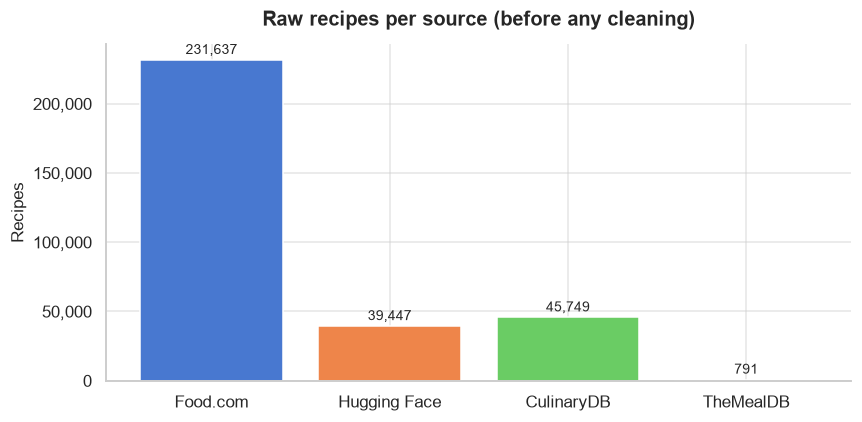

In [22]:
# Chart: how many raw recipes each source provides
raw_counts = pd.Series({"Food.com": len(recipes_raw), "Hugging Face": len(hf_df),
                        **{SOURCE_LABELS[name]: len(df) for name, df in extra_raw.items()}})
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(raw_counts.index, raw_counts.values, color=sns.color_palette("muted", len(raw_counts)))
label_bars(ax)
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title("Raw recipes per source (before any cleaning)")
show_figure(fig, "01_raw_recipes_per_source")

---

## 5.2 Data Quality Assessment

Before we can engineer features, we need to understand what is in our data. We look at:

- **Missing values** - which columns have gaps and how severe are they?
- **Duplicates** - are there repeated recipes that could bias our analysis?
- **Inconsistent units** - calorie values need to be in kcal; quantities need to be numeric.
- **Outliers** - extreme calorie values or cook times that look like data entry errors.

### 5.2.1 Missing Values and Duplicates (Food.com)

In [23]:
# -------------------------------------------------------
# Missing value analysis for the Food.com dataset
# -------------------------------------------------------
missing = recipes_raw.isnull().sum()
missing_pct = (missing / len(recipes_raw) * 100).round(2)

quality_report = pd.DataFrame({
    "missing_count": missing,
    "missing_pct"  : missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== Food.com Missing Value Report ===")
print(quality_report.to_string())
print(f"\nTotal rows       : {len(recipes_raw):,}")
print(f"Duplicate rows   : {recipes_raw.duplicated().sum():,}")

=== Food.com Missing Value Report ===
                missing_count  missing_pct
description              4979         2.15
name                        1         0.00
minutes                     0         0.00
id                          0         0.00
contributor_id              0         0.00
submitted                   0         0.00
nutrition                   0         0.00
tags                        0         0.00
n_steps                     0         0.00
steps                       0         0.00
ingredients                 0         0.00
n_ingredients               0         0.00

Total rows       : 231,637


Duplicate rows   : 0


---

### 5.2.2 Missing Values and Duplicates (Hugging Face)

In [24]:
# -------------------------------------------------------
# Missing value analysis for the Hugging Face dataset
# -------------------------------------------------------
hf_missing = hf_df.isnull().sum()
hf_missing_pct = (hf_missing / len(hf_df) * 100).round(2)

hf_quality = pd.DataFrame({
    "missing_count": hf_missing,
    "missing_pct"  : hf_missing_pct
}).sort_values("missing_pct", ascending=False)

print("=== Hugging Face Missing Value Report ===")
print(hf_quality.to_string())
print(f"\nTotal rows       : {len(hf_df):,}")
print(f"Duplicate rows   : {hf_df.duplicated().sum():,}")

=== Hugging Face Missing Value Report ===
                  missing_count  missing_pct
image_url                   277          0.7
recipe_name                   0          0.0
source                        0          0.0
url                           0          0.0
calories                      0          0.0
servings                      0          0.0
total_weight_g                0          0.0
diet_labels                   0          0.0
health_labels                 0          0.0
cautions                      0          0.0
cuisine_type                  0          0.0
meal_type                     0          0.0
dish_type                     0          0.0
ingredient_lines              0          0.0
ingredients                   0          0.0
total_nutrients               0          0.0
daily_values                  0          0.0
digest                        0          0.0

Total rows       : 39,447


Duplicate rows   : 0


---

### 5.2.3 Outliers (Calories, Servings, Cook Time)

#### 5.2.3.1 Outlier checks

In [25]:
# -------------------------------------------------------
# Outlier check - calories per serving in both datasets
# -------------------------------------------------------

# Hugging Face 'calories' is the total for the whole recipe,
# so we divide by 'servings' to get a per-serving value.
hf_servings = pd.to_numeric(hf_df["servings"], errors="coerce")
hf_servings = hf_servings.where(hf_servings > 0)
hf_kcal_per_serving = hf_df["calories"] / hf_servings

print("Whole-recipe calories (Hugging Face):")
print(hf_df["calories"].describe())
print("\nCalories per serving (Hugging Face):")
print(hf_kcal_per_serving.describe())
print(f"\nRows with missing or zero servings          : {hf_servings.isna().sum()}")
print(f"Rows with more than {MAX_SERVINGS} servings              : {(hf_servings > MAX_SERVINGS).sum()}")
print(f"Rows with > {MAX_KCAL_PER_SERVING:,} kcal per serving          : {(hf_kcal_per_serving > MAX_KCAL_PER_SERVING).sum()}")

# Food.com calories are the first value of the 'nutrition' list
# and are already per serving.
fc_kcal_per_serving = pd.to_numeric(
    recipes_raw["nutrition"].str.strip("[]").str.split(",").str[0],
    errors="coerce"
)
print("\nCalories per serving (Food.com):")
print(fc_kcal_per_serving.describe())
print(f"Rows with > {MAX_KCAL_PER_SERVING:,} kcal per serving          : {(fc_kcal_per_serving > MAX_KCAL_PER_SERVING).sum()}")

# Check cook-time outliers in Food.com
print("\nCook time (minutes) distribution (Food.com):")
print(recipes_raw["minutes"].describe())
unrealistic = (recipes_raw["minutes"] > 1440).sum()  # more than 24 hours
print(f"Recipes with cook time > 24 hours : {unrealistic}")

Whole-recipe calories (Hugging Face):
count    39447.000000
mean      2139.060923
std       1924.697195
min          0.060000
25%        866.158614
50%       1656.948000
75%       2817.372416
max      33319.350000
Name: calories, dtype: float64

Calories per serving (Hugging Face):
count    39447.000000
mean       360.003419
std        304.347243
min          0.009000
25%        174.639855
50%        268.987564
75%        444.559492
max       2498.389500
dtype: float64

Rows with missing or zero servings          : 0
Rows with more than 50 servings              : 206
Rows with > 3,000 kcal per serving          : 0



Calories per serving (Food.com):
count    231637.000000
mean        473.942425
std        1189.711374
min           0.000000
25%         174.400000
50%         313.400000
75%         519.700000
max      434360.200000
Name: nutrition, dtype: float64
Rows with > 3,000 kcal per serving          : 3151

Cook time (minutes) distribution (Food.com):
count    2.316370e+05
mean     9.398546e+03
std      4.461963e+06
min      0.000000e+00
25%      2.000000e+01
50%      4.000000e+01
75%      6.500000e+01
max      2.147484e+09
Name: minutes, dtype: float64
Recipes with cook time > 24 hours : 2000


#### 5.2.3.2 Chart: what changes when Hugging Face calories are divided by servings

> **What it shows:** Hugging Face lists calories for the whole recipe. Dividing by the number of servings (right) brings them into the same range as Food.com's per-serving values.

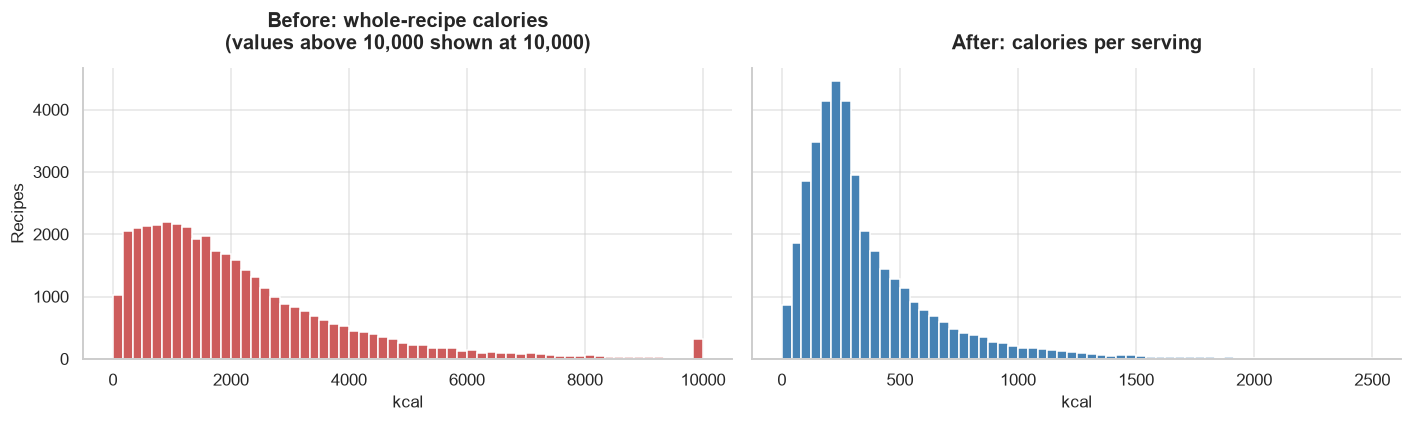

Median before: 1,657 kcal per recipe -> after: 269 kcal per serving


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(hf_df["calories"].clip(upper=10000), bins=60, color="indianred", edgecolor="white")
axes[0].set_title("Before: whole-recipe calories\n(values above 10,000 shown at 10,000)")
axes[1].hist(hf_kcal_per_serving.clip(upper=3000), bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("After: calories per serving")
for ax in axes:
    ax.set_xlabel("kcal")
axes[0].set_ylabel("Recipes")
show_figure(fig, "02_hf_calories_before_after")
print(f"Median before: {hf_df['calories'].median():,.0f} kcal per recipe -> "
      f"after: {hf_kcal_per_serving.median():,.0f} kcal per serving")

---

## 5.3 Data Cleaning

Based on the quality report above, we apply targeted cleaning steps:

1. Drop rows with missing recipe names, ingredient lists, calories, or servings.
2. Remove duplicate recipes.
3. Remove Hugging Face recipes with more than 50 servings (bulk or catering entries; one lists 1,520 servings).
4. Convert Hugging Face calories from whole-recipe totals to calories per serving.
5. Remove recipes above 3,000 kcal per serving (both datasets; Food.com is filtered in 5.4.3 once its nutrition column is parsed).
6. Remove recipes with unrealistically long cook times.

### 5.3.1 Clean the Food.com Dataset

In [27]:
# -------------------------------------------------------
# Clean the Food.com dataset: missing fields, duplicate
# names, cook times over 24 hours (clean_foodcom() in
# src/everflavor/pipeline.py, also used by run_pipeline in 5.5)
# -------------------------------------------------------
from everflavor.pipeline import clean_foodcom, clean_huggingface

df_fc = clean_foodcom(recipes_raw.copy(), verbose=True)
print(f"\nFood.com clean shape: {df_fc.shape}")

Dropped 1 rows with missing name/ingredients/nutrition


Dropped 1,451 duplicate recipe names
Dropped 1,991 recipes with cook time > 24 hours

Food.com clean shape: (228194, 12)


---

### 5.3.2 Clean the Hugging Face Dataset

#### 5.3.2.1 Clean the dataset

In [28]:
# -------------------------------------------------------
# Clean the Hugging Face dataset: missing fields, duplicates,
# zero or too many servings, then whole-recipe calories ->
# calories per serving and the calorie cap (clean_huggingface())
# -------------------------------------------------------
df_hf = clean_huggingface(hf_df, verbose=True)
print(f"\nHugging Face clean shape: {df_hf.shape}")

Dropped 0 rows with missing name/calories/cuisine/servings


Dropped 1,205 duplicate recipe names
Dropped 199 recipes with zero or more than 50 servings
Dropped 0 recipes with more than 3,000 kcal per serving

Hugging Face clean shape: (38043, 19)


#### 5.3.2.2 Chart: rows before and after cleaning

> **What it shows:** How many rows each dataset keeps after the cleaning steps above.

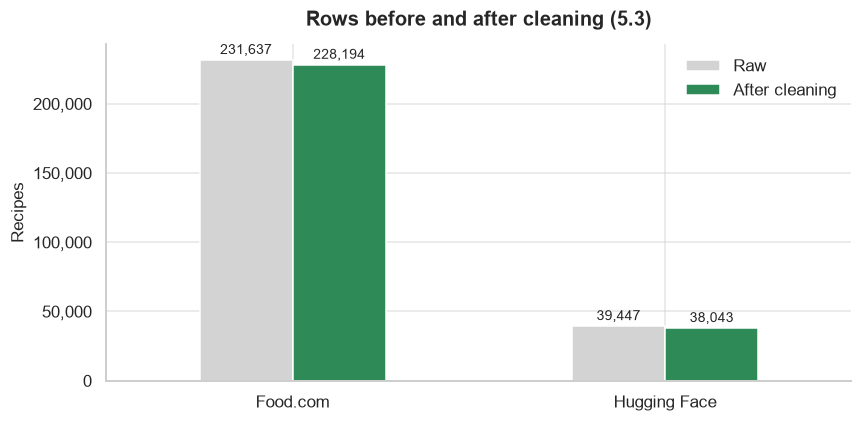

Food.com: 3,443 rows removed (1.5%)
Hugging Face: 1,404 rows removed (3.6%)


In [29]:
cleaning = pd.DataFrame({"Raw": [len(recipes_raw), len(hf_df)],
                         "After cleaning": [len(df_fc), len(df_hf)]},
                        index=["Food.com", "Hugging Face"])
fig, ax = plt.subplots(figsize=(8, 4))
cleaning.plot.bar(ax=ax, rot=0, color=["lightgray", "seagreen"])
label_bars(ax)
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title("Rows before and after cleaning (5.3)")
show_figure(fig, "03_rows_before_after_cleaning")
removed = cleaning["Raw"] - cleaning["After cleaning"]
for name, n in removed.items():
    print(f"{name}: {n:,} rows removed ({n / cleaning.loc[name, 'Raw'] * 100:.1f}%)")

---

## 5.4 Feature Engineering

We engineer the following features that the EverFlavor agents will use directly:

| Feature | Used By | Description |
|---------|---------|-------------|
| `cuisine_family` | All agents | One of: Asian, European, Latin American, African, Middle Eastern, Other |
| `contains_pork`, `contains_alcohol` | Nutritionist | Religious restrictions (for example halal or kosher) |
| `contains_gluten`, `contains_dairy` | Nutritionist | Medical restrictions (celiac disease, lactose intolerance) |
| `contains_egg`, `contains_peanut`, `contains_tree_nut`, `contains_fish`, `contains_shellfish`, `contains_soy`, `contains_sesame` | Nutritionist | Common food allergens |
| `vegetarian`, `vegan` | Nutritionist | Ethical restrictions |
| `calories_per_serving` | Nutritionist | Calorie target matching |
| `protein_g`, `fat_g`, `carbs_g`, `sodium_mg` | Nutritionist | Per serving. Exact for Hugging Face; converted from percent daily value for Food.com (approximate) |
| `ingredient_list` | Chef | Cleaned ingredient names, normalized so that 'eggs', 'large eggs' and 'egg' are one ingredient |
| `complexity` | Chef | Number of unique ingredients (proxy for recipe difficulty) |
| `source` | All agents | Which dataset the recipe came from |

All restriction flags are approximate. They come from ingredient keywords, plus Hugging Face health labels where they exist. When the two disagree, the flag leans toward "contains" (and toward "not vegetarian"), so a restriction filter removes too much rather than too little.

### 5.4.1 Cuisine Family Label

One map turns the cuisine names used by every source (Hugging Face labels, Food.com tags, CulinaryDB regions, TheMealDB countries) into our five families. The first cell defines the map and the matching functions; the second applies them.

#### 5.4.1.1 Cuisine map and matching functions

In [30]:
# -------------------------------------------------------
# 5.4.1 Cuisine Family Label (src/everflavor/cuisine.py)
# One map turns cuisine names from every source into our
# five target families: Hugging Face cuisine labels,
# Food.com tags, CulinaryDB regions and TheMealDB areas.
# A recipe with labels from two families gets the smaller
# family (FAMILY_PRIORITY), so 'european' never hides a
# more specific label.
# -------------------------------------------------------
from everflavor.cuisine import CUISINE_FAMILIES, FAMILY_PRIORITY, map_cuisine
from everflavor.parsing import parse_label_list, parse_list_string  # noqa: F401

print("Cuisine names known per family:")
for family, names in CUISINE_FAMILIES.items():
    print(f"  {family:15s}: {len(names):3d} names, e.g. {', '.join(names[:5])}")
print(f"\nTie-break order: {' > '.join(FAMILY_PRIORITY)}")

Cuisine names known per family:
  Asian          :  40 names, e.g. asian, south east asian, southeast asian, south east asia, chinese
  European       :  55 names, e.g. european, central europe, eastern europe, british, british isles
  Latin American :  37 names, e.g. latin american, mexican, mexico, oaxacan, baja
  African        :  23 names, e.g. african, africa, north african, west african, south african
  Middle Eastern :  19 names, e.g. middle eastern, middle east, turkish, lebanese, syrian

Tie-break order: African > Middle Eastern > Latin American > Asian > European


#### 5.4.1.2 Apply the map to both datasets

In [31]:
# Hugging Face has a cuisine_type column
df_hf["cuisine_family"] = df_hf["cuisine_type"].apply(map_cuisine)

# Food.com has no cuisine column, but many recipes carry cuisine tags
# such as 'moroccan', 'lebanese' or 'mexican'
df_fc["cuisine_family"] = df_fc["tags"].apply(lambda t: map_cuisine(t, substring_match=False))

print("Cuisine family distribution (Hugging Face):")
print(df_hf["cuisine_family"].value_counts().to_string())
print("\nCuisine family distribution (Food.com, from tags):")
print(df_fc["cuisine_family"].value_counts().to_string())

# Show what ends up in "Other" so the mapping can be checked
print("\nHugging Face cuisine labels mapped to 'Other':")
print(df_hf.loc[df_hf["cuisine_family"] == "Other", "cuisine_type"].value_counts().head(10).to_string())

Cuisine family distribution (Hugging Face):
cuisine_family
Other             17312
European          13877
Asian              3189
Latin American     2953
Middle Eastern      712

Cuisine family distribution (Food.com, from tags):
cuisine_family
Other             178137
European           23857
Asian              11948
Latin American      9530
African             2812
Middle Eastern      1910

Hugging Face cuisine labels mapped to 'Other':
cuisine_type
["american"]             16004
["world"]                 1273
["kosher"]                  34
["kosher","american"]        1


#### 5.4.1.3 Chart: cuisine coverage before and after using Food.com's cuisine tags

> **What it shows:** Using Food.com's own cuisine tags gives many more recipes a cuisine family, so fewer recipes are left as "Other".

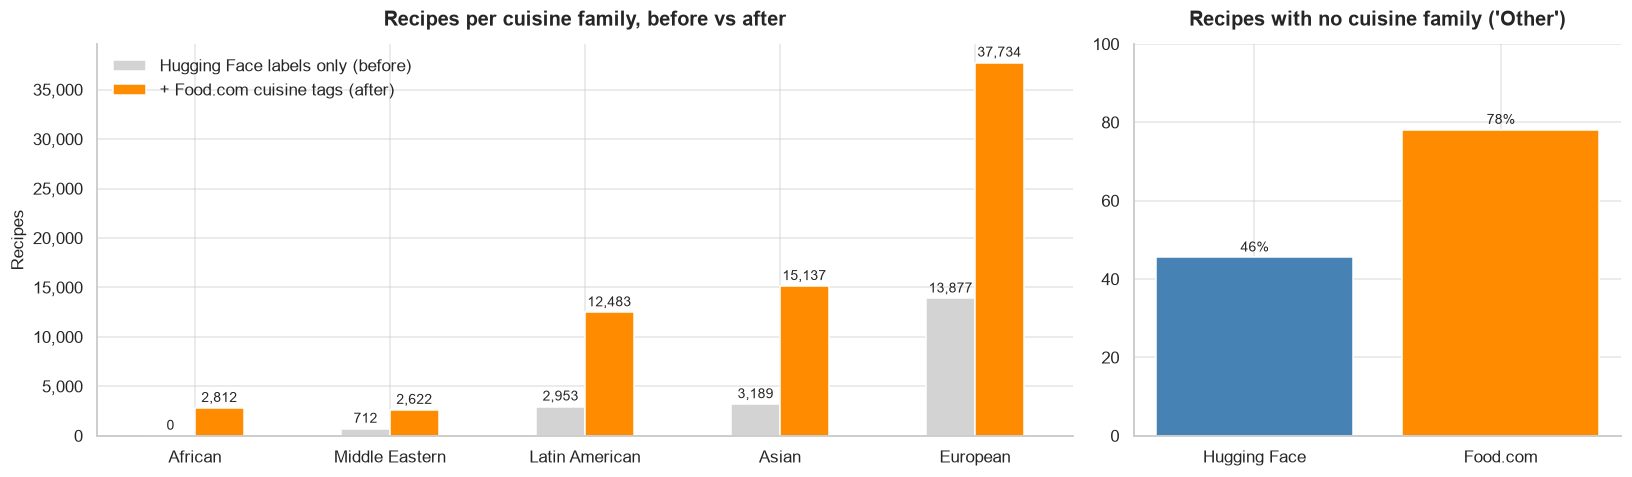

In [32]:
hf_counts = df_hf["cuisine_family"].value_counts().reindex(FAMILY_ORDER, fill_value=0)
fc_counts = df_fc["cuisine_family"].value_counts().reindex(FAMILY_ORDER, fill_value=0)
coverage = pd.DataFrame({"Hugging Face labels only (before)": hf_counts,
                         "+ Food.com cuisine tags (after)": hf_counts + fc_counts})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
coverage.drop(index="Other").plot.bar(ax=axes[0], rot=0, color=["lightgray", "darkorange"])
label_bars(axes[0])
axes[0].set_ylabel("Recipes")
axes[0].set_xlabel("")
thousands(axes[0])
axes[0].set_title("Recipes per cuisine family, before vs after")
other_share = pd.Series({"Hugging Face": (df_hf["cuisine_family"] == "Other").mean() * 100,
                         "Food.com": (df_fc["cuisine_family"] == "Other").mean() * 100})
axes[1].bar(other_share.index, other_share.values, color=["steelblue", "darkorange"])
label_bars(axes[1], fmt="{:.0f}%")
axes[1].set_ylim(0, 100)
axes[1].set_title("Recipes with no cuisine family ('Other')")
show_figure(fig, "04_cuisine_coverage_before_after")

---

### 5.4.2 Dietary Restriction Flags

Flags for religious, medical and ethical restrictions and the most common allergens. The cells below: (1) keyword lists, (2) the matching functions, (3) Food.com flags and an accuracy check against Food.com's own dietary tags, (4) Hugging Face flags, which also use the dataset's health labels.

Keywords are matched as whole words in the ingredients **and the recipe name** ("... with Mussels" counts even when the list leaves the mussels out). The lists were extended after the first blind hand-check in 5.11, which showed that wheat is often hidden in product names (crackers, pastry, spaghetti, buns), and that names such as "butter lettuce" and "sherry vinegar" caused false alarms. The third round's disagreements were traced and fixed in 5.13, which also checks ready-made ingredients ("ranch dressing", "chocolate chips") for hidden allergens on Open Food Facts.

**Meat types:** besides `contains_meat` (any meat or poultry), three flags say which kind: `contains_red_meat` (meat from mammals, pork included), `contains_poultry` (white meat) and `contains_processed_meat` (cured, salted, smoked or fermented meat). They follow USDA and WHO / IARC: fish and shellfish are their own groups, not white meat. **Flags beyond the US allergens** (added after a review of dietary restrictions worldwide):

- **Allergens other countries label:** shellfish split into `contains_crustacean` and `contains_mollusc` (the EU, Canada, Australia / NZ, Japan and Korea list them separately), plus `contains_mustard`, `contains_celery`, `contains_lupin`, `contains_buckwheat` and `contains_sulfites`. `ALLERGEN_SETS` (5.4.7) lists which flags each country requires.
- **Religious and cultural diets:** `contains_scaleless_fish` and `contains_unclean_meat` (kosher, Adventist), `contains_carmine` (insect coloring), `contains_asafoetida` (Buddhist; kept apart from onion and garlic because Jain cooks use it instead of them), `contains_mushroom`, `contains_coffee_or_tea`, `contains_added_salt`, and `contains_alcohol_extract` (vanilla extract and other extracts, about 35% alcohol, kept apart from `contains_alcohol` until the team decides policy P18).
- **Medical screens:** `contains_fava` (G6PD deficiency), `contains_nightshade`, `contains_high_mercury_fish`, `contains_raw_animal`, `contains_soft_cheese` (pregnancy), `contains_high_purine` (gout) and `contains_high_tyramine` (MAOI medicines). They list ingredients to talk about with a doctor; they are never medical advice.

Definitions that are a matter of policy (oats, gelatin, a plain "nut", falafel, decaf coffee ...) are recorded with the team's decision in `docs/flag_review/flag_policies.csv`.

#### 5.4.2.1 Keyword lists

In [33]:
# -------------------------------------------------------
# 5.4.2 Dietary Restriction Flags (src/everflavor/flags.py)
# These flags are extracted from ingredient lists and recipe
# names (and, for Hugging Face, health labels). They let the
# Nutritionist Agent filter out recipes that do not meet
# a user's religious, medical or ethical restrictions.
# Each flag has a keyword list (matched as whole words) and a
# list of exception phrases that contain a keyword but are not
# that food ("coconut milk", "butter lettuce").
# -------------------------------------------------------
from everflavor.flags import FLAG_COLUMNS, FLAG_RULES

print(f"{'Flag':26s} {'keywords':>8s} {'exceptions':>10s}  examples")
for flag, (keywords, exceptions) in FLAG_RULES.items():
    print(f"{flag:26s} {len(keywords):8d} {len(exceptions):10d}  {', '.join(keywords[:4])}")
print("\nvegetarian = no meat, fish or shellfish keyword; vegan = also no dairy, egg or honey")

Flag                       keywords exceptions  examples
contains_pork                    26         16  pork, bacon, ham, prosciutto
contains_alcohol                108         53  wine, beer, ale, lager
contains_gluten                 121        124  flour, bread, wheat, pasta
contains_dairy                   62         34  milk, buttermilk, cheese, butter
contains_egg                     20          8  egg, egg white, egg yolk, mayonnaise
contains_peanut                   6         16  peanut, peanut butter, peanut oil, groundnut
contains_tree_nut                29          8  almond, walnut, pecan, cashew
contains_fish                    69         10  fish, salmon, tuna, cod
contains_shellfish               32         12  shrimp, prawn, crab, crabmeat
contains_crustacean              16         12  shrimp, prawn, crab, crabmeat
contains_mollusc                 18         12  clam, cockle, mussel, scallop
contains_soy                     46          0  soy, soya, soy sauce, soybean

#### 5.4.2.2 Matching functions

In [34]:
# --- Functions that turn keyword lists into true/false flags (src/everflavor/flags.py) ---
# make_flag() matches whole words only, so 'ham' does not match 'graham'
# and 'egg' does not match 'eggplant'; exception phrases are removed first.
from everflavor.flags import (  # noqa: F401
    add_foodcom_diet_flags,
    add_keyword_flags,
    make_flag,
)
from everflavor.ingredients import ingredient_text  # noqa: F401

pork_keywords, pork_exceptions = FLAG_RULES["contains_pork"]
for text in ["graham cracker", "smoked ham", "turkey bacon", "eggplant"]:
    print(f"  {text:15s} -> contains pork: {make_flag(text, pork_keywords, pork_exceptions)}")

  graham cracker  -> contains pork: False
  smoked ham      -> contains pork: True
  turkey bacon    -> contains pork: False
  eggplant        -> contains pork: False


#### 5.4.2.3 Food.com flags and accuracy check

In [35]:
from everflavor.flags import foodcom_tag_agreement, print_flag_counts

# Apply flags to Food.com
df_fc = add_foodcom_diet_flags(df_fc)

print_flag_counts(df_fc, "Food.com")

# -------------------------------------------------------
# Accuracy check: Food.com recipes also carry dietary tags
# added by their authors. Where a tag exists, how often does
# our keyword flag agree with it?
# -------------------------------------------------------
tag_agreement = foodcom_tag_agreement(df_fc)
print("\nAgreement with Food.com's own dietary tags:")
for tag, row in tag_agreement.iterrows():
    print(f"  '{tag}' tag: {int(row['recipes']):>7,} recipes, our flag agrees on {row['agree (%)']:.1f}%")

# Disagreements are either keyword mistakes or wrong tags; a few examples to review
veg_tagged = df_fc["tags"].apply(lambda t: "vegetarian" in parse_label_list(t))
examples = df_fc.loc[veg_tagged & ~df_fc["vegetarian"], "name"].head(5).tolist()
print("\nExamples tagged vegetarian that our flag marks as containing meat or fish:")
for name in examples:
    print(f"  - {name}")

Restriction flags:   0%|          | 0/43 [00:00<?, ?it/s]

Restriction flag counts (Food.com):
  contains_pork             :   28,052 (12.3%)
  contains_alcohol          :   24,907 (10.9%)
  contains_gluten           :  126,584 (55.5%)
  contains_dairy            :  141,187 (61.9%)
  contains_egg              :   70,470 (30.9%)
  contains_peanut           :   10,867 (4.8%)
  contains_tree_nut         :   28,179 (12.3%)
  contains_fish             :   17,952 (7.9%)
  contains_shellfish        :    9,169 (4.0%)
  contains_crustacean       :    7,128 (3.1%)
  contains_mollusc          :    2,996 (1.3%)
  contains_soy              :   29,346 (12.9%)
  contains_sesame           :    7,068 (3.1%)
  contains_mustard          :   15,583 (6.8%)
  contains_celery           :   14,972 (6.6%)
  contains_lupin            :        0 (0.0%)
  contains_buckwheat        :      294 (0.1%)
  contains_sulfites         :   22,004 (9.6%)
  contains_meat             :   85,949 (37.7%)
  contains_beef             :   22,402 (9.8%)
  contains_red_meat         :   48,5


Agreement with Food.com's own dietary tags:
  'vegetarian' tag:  35,186 recipes, our flag agrees on 96.8%
  'vegan' tag:   9,850 recipes, our flag agrees on 86.7%
  'gluten-free' tag:   5,639 recipes, our flag agrees on 85.6%
  'dairy-free' tag:     193 recipes, our flag agrees on 79.3%
  'egg-free' tag:   5,002 recipes, our flag agrees on 94.8%
  'nut-free' tag:     214 recipes, our flag agrees on 96.7%
  'non-alcoholic' tag:     298 recipes, our flag agrees on 97.3%



Examples tagged vegetarian that our flag marks as containing meat or fish:
  - fool the meat eaters  chili
  - almost  outback steakhouse shrimp sauce
  - beefy  seitan log
  - boo tiful  jell o cups
  - whatever floats your boat  brownies


#### 5.4.2.4 Hugging Face flags

In [36]:
# --- Flags for the Hugging Face dataset ---
# Keyword flags from 'ingredient_lines', combined with the
# 'health_labels' column (a JSON list string).

# Which health labels does this dataset actually use?
hf_label_sets = df_hf["health_labels"].apply(lambda x: set(parse_label_list(x)))
label_counts = pd.Series([l for s in hf_label_sets for l in s]).value_counts()
print("Health labels in the Hugging Face dataset:")
print(label_counts.to_string())

# add_hf_diet_flags() also flags recipes WITHOUT the dataset's 'free of' label (HF_FREE_LABELS):
# either source is enough, which is the safe direction for a restriction filter.
from everflavor.flags import HF_FREE_LABELS, add_hf_diet_flags  # noqa: F401

veg_labels = hf_label_sets.apply(lambda s: "vegetarian" in s)
df_hf = add_hf_diet_flags(df_hf)

print()
print_flag_counts(df_hf, "Hugging Face")
print(f"\nVegetarian labels overridden by meat or fish in the ingredients: {(veg_labels & ~df_hf['vegetarian']).sum():,}")

Health labels in the Hugging Face dataset:
peanut-free       36552
shellfish-free    36412
fish-free         34870
soy-free          34271
tree-nut-free     32541
egg-free          28728
vegetarian        23584
gluten-free       21533
dairy-free        18663
vegan              9610
paleo              4502
low sugar            90


Restriction flags:   0%|          | 0/43 [00:00<?, ?it/s]


Restriction flag counts (Hugging Face):
  contains_pork             :    4,320 (11.4%)
  contains_alcohol          :    3,971 (10.4%)
  contains_gluten           :   17,430 (45.8%)
  contains_dairy            :   19,835 (52.1%)
  contains_egg              :    9,547 (25.1%)
  contains_peanut           :    1,598 (4.2%)
  contains_tree_nut         :    5,716 (15.0%)
  contains_fish             :    3,295 (8.7%)
  contains_shellfish        :    1,705 (4.5%)
  contains_crustacean       :    1,683 (4.4%)
  contains_mollusc          :    1,660 (4.4%)
  contains_soy              :    5,082 (13.4%)
  contains_sesame           :    1,666 (4.4%)
  contains_mustard          :    2,446 (6.4%)
  contains_celery           :    1,839 (4.8%)
  contains_lupin            :        0 (0.0%)
  contains_buckwheat        :      123 (0.3%)
  contains_sulfites         :    3,827 (10.1%)
  contains_meat             :   11,516 (30.3%)
  contains_beef             :    2,408 (6.3%)
  contains_red_meat         : 

#### 5.4.2.5 Chart: how common each restriction is, and how well our flags match Food.com's tags

> **What it shows:** Left: how common each restriction is in each dataset. Right: how often our keyword flags agree with Food.com's own dietary tags (green = 95% or better).

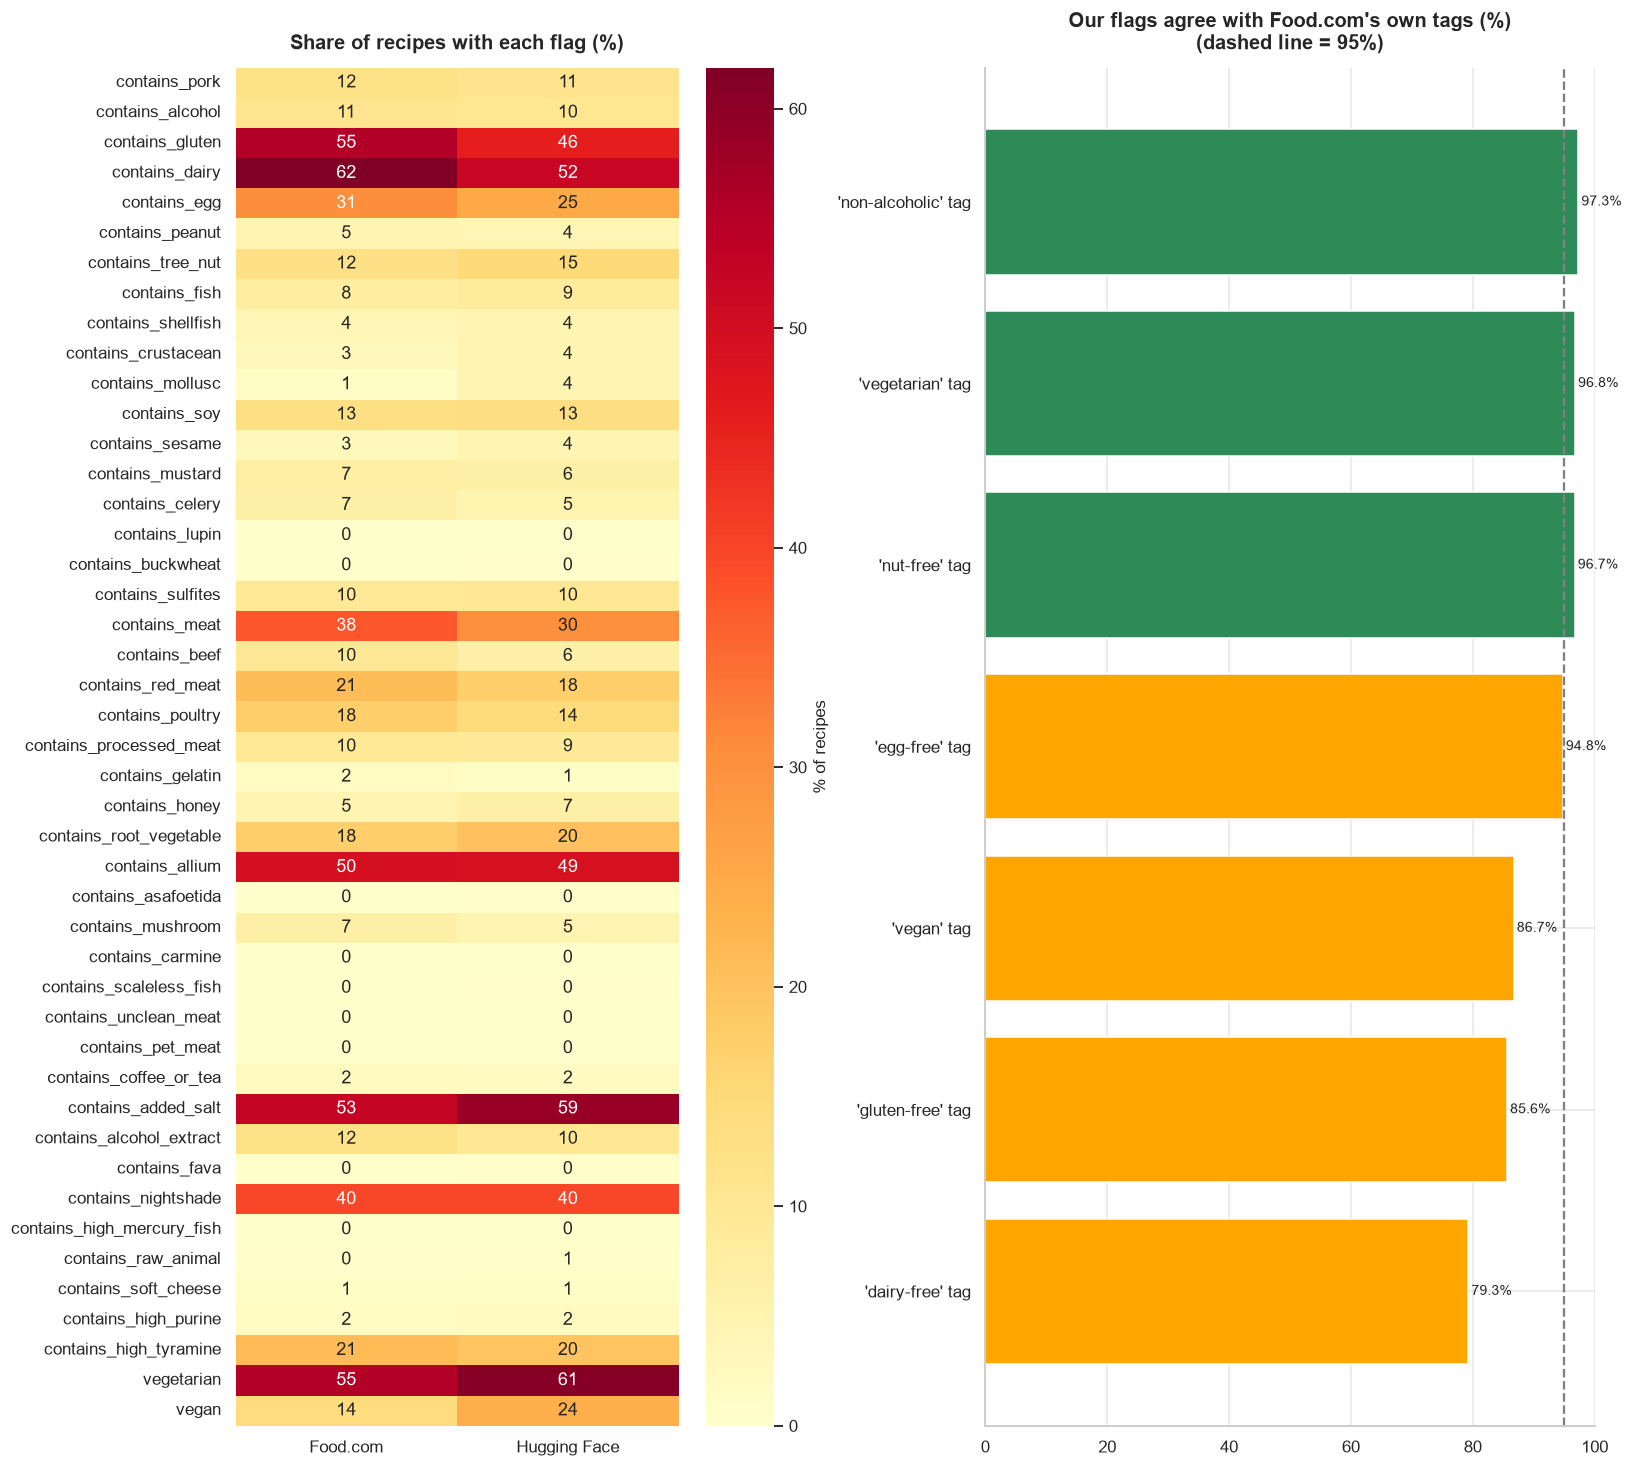

In [37]:
prevalence = pd.DataFrame({"Food.com": df_fc[FLAG_COLUMNS].mean() * 100,
                           "Hugging Face": df_hf[FLAG_COLUMNS].mean() * 100})
agreement = tag_agreement["agree (%)"]
agreement.index = [f"'{tag}' tag" for tag in agreement.index]
agreement = agreement.sort_values()

# one row per flag, so the figure grows with the number of flags
fig, axes = plt.subplots(1, 2, figsize=(15, max(5.5, 0.3 * len(FLAG_COLUMNS))),
                         gridspec_kw={"width_ratios": [1, 1.1]})
sns.heatmap(prevalence, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0],
            cbar_kws={"label": "% of recipes"})
axes[0].set_title("Share of recipes with each flag (%)")
colors = ["seagreen" if v >= 95 else "orange" for v in agreement.values]
axes[1].barh(agreement.index, agreement.values, color=colors)
axes[1].axvline(95, ls="--", color="gray")
axes[1].set_xlim(0, 100)
label_bars(axes[1], fmt="{:.1f}%")
axes[1].set_title("Our flags agree with Food.com's own tags (%)\n(dashed line = 95%)")
show_figure(fig, "05_restriction_flags")

---

### 5.4.3 Macronutrients Per Serving

Calories, protein, fat, carbs and sodium per serving for both datasets. The first cell defines the conversions; the second applies them and checks the Food.com conversion.

#### 5.4.3.1 Conversion functions

In [38]:
# -------------------------------------------------------
# 5.4.3 Macronutrients Per Serving (src/everflavor/nutrition.py)
#
# Food.com: the 'nutrition' column is a string that encodes
# [calories, total_fat_%dv, sugar_%dv, sodium_%dv,
#  protein_%dv, saturated_fat_%dv, carbs_%dv]
# Calories are per serving; the rest are percent daily
# values. We convert them to grams with the FDA reference
# values that were on US labels when the recipes were posted.
# The check in the next cell confirms the result.
#
# Hugging Face: 'total_nutrients' already has grams for the
# whole recipe, so we divide by servings.
# -------------------------------------------------------
from everflavor.nutrition import FOODCOM_DAILY_VALUES, add_foodcom_macros, add_hf_macros

print("Food.com percent daily value -> grams, using these daily values:")
for column, (pdv_column, daily_value) in FOODCOM_DAILY_VALUES.items():
    print(f"  {column:10s} = {pdv_column} x {daily_value} / 100")

Food.com percent daily value -> grams, using these daily values:
  fat_g      = fat_pdv x 65 / 100
  carbs_g    = carbs_pdv x 300 / 100
  protein_g  = protein_pdv x 50 / 100
  sodium_mg  = sodium_pdv x 2400 / 100


#### 5.4.3.2 Apply them and check the Food.com conversion

In [39]:
# Food.com
df_fc = add_foodcom_macros(df_fc)
before = len(df_fc)
df_fc = df_fc[df_fc["calories_per_serving"] <= MAX_KCAL_PER_SERVING]
print(f"Dropped {before - len(df_fc):,} Food.com recipes with missing calories or more than {MAX_KCAL_PER_SERVING:,} kcal per serving")

# Hugging Face
df_hf = add_hf_macros(df_hf)

macro_cols = ["calories_per_serving", "protein_g", "fat_g", "carbs_g", "sodium_mg"]
print("\nPer-serving nutrition (Food.com, macros converted from percent daily value):")
print(df_fc[macro_cols].describe().round(1).to_string())
print("\nPer-serving nutrition (Hugging Face):")
print(df_hf[macro_cols].describe().round(1).to_string())

# Check: do the converted grams add up to the listed calories?
# (fat 9 kcal/g, protein and carbs 4 kcal/g)
check = df_fc[df_fc["calories_per_serving"] > 50]
estimate = 9 * check["fat_g"] + 4 * (check["protein_g"] + check["carbs_g"])
ratio = estimate / check["calories_per_serving"]
print("\nFood.com check - calories from converted grams / listed calories:")
print(f"  median {ratio.median():.2f}, middle 50% between {ratio.quantile(0.25):.2f} and {ratio.quantile(0.75):.2f} (1.00 = exact)")

Dropped 3,049 Food.com recipes with missing calories or more than 3,000 kcal per serving



Per-serving nutrition (Food.com, macros converted from percent daily value):
       calories_per_serving  protein_g     fat_g   carbs_g  sodium_mg
count              225145.0   225145.0  225145.0  225145.0   225145.0
mean                  407.4       16.2      20.1      38.6      658.1
std                   382.6       18.9      24.8      51.6     2390.6
min                     0.0        0.0       0.0       0.0        0.0
25%                   172.6        3.0       5.2      12.0      120.0
50%                   308.8        9.0      13.0      27.0      336.0
75%                   506.9       24.5      26.0      48.0      768.0
max                  2999.8      417.0     324.4     756.0   351936.0

Per-serving nutrition (Hugging Face):
       calories_per_serving  protein_g    fat_g  carbs_g  sodium_mg
count               38043.0    38043.0  38042.0  38043.0    38043.0
mean                  362.6       14.7     18.6     34.4      460.7
std                   304.8       17.5     21.7  


Food.com check - calories from converted grams / listed calories:
  median 0.98, middle 50% between 0.95 and 1.00 (1.00 = exact)


#### 5.4.3.3 Chart: macronutrients per serving in each dataset

> **What it shows:** Protein, fat and carbs per serving in the two datasets that have nutrition data. Similar boxes mean the Food.com conversion to grams is in a believable range.

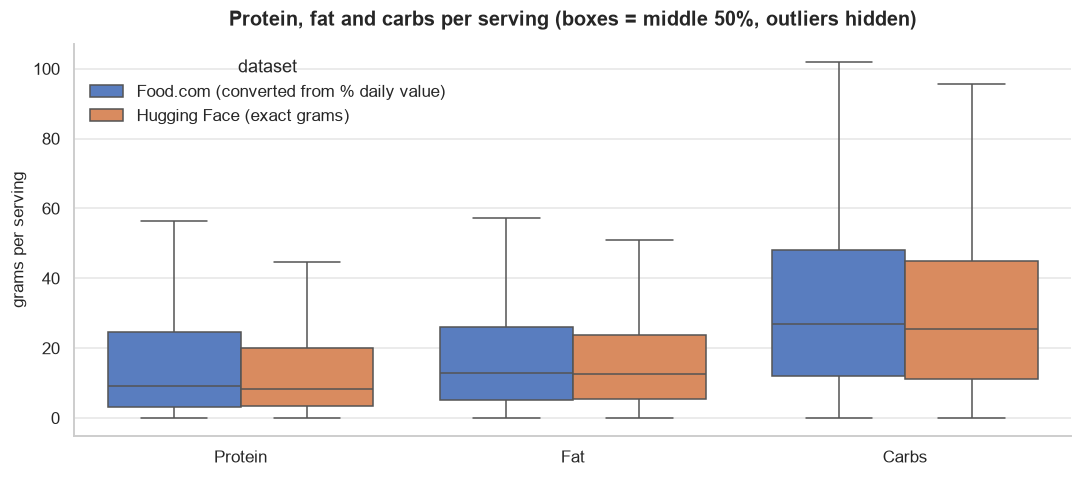

In [40]:
macro_long = pd.concat([
    df_fc[["protein_g", "fat_g", "carbs_g"]].assign(dataset="Food.com (converted from % daily value)"),
    df_hf[["protein_g", "fat_g", "carbs_g"]].assign(dataset="Hugging Face (exact grams)"),
]).melt(id_vars="dataset", var_name="nutrient", value_name="grams per serving")

macro_long["nutrient"] = macro_long["nutrient"].map({"protein_g": "Protein", "fat_g": "Fat", "carbs_g": "Carbs"})
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.boxplot(data=macro_long, x="nutrient", y="grams per serving", hue="dataset",
            showfliers=False, ax=ax)
ax.set_xlabel("")
ax.set_title("Protein, fat and carbs per serving (boxes = middle 50%, outliers hidden)")
show_figure(fig, "06_macros_by_dataset")

---

### 5.4.4 Cleaned and Normalized Ingredient Lists

Ingredient names are parsed into lists and normalized so that variants count as one ingredient. The first cell defines the rules; the second applies them.

#### 5.4.4.1 Normalizing rules

In [41]:
# -------------------------------------------------------
# 5.4.4 Cleaned and Normalized Ingredient Lists (src/everflavor/ingredients.py)
# Convert the raw ingredient strings into Python lists,
# then normalize each name so that variants of the same
# ingredient count as one ('eggs', 'large eggs' -> 'egg'):
# drop notes in brackets, quantities and units, text after a
# comma or ' or ', preparation words, then apply synonyms and
# a simple singular form.
# -------------------------------------------------------
from everflavor.ingredients import (  # noqa: F401
    clean_ingredients,
    hf_ingredient_foods,
    normalize_ingredient,
    normalize_ingredient_list,
    singular,
)

for example in ["2 Large Eggs", "1/2 cup grated parmesan cheese", "garlic cloves, minced",
                "canola oil or vegetable oil", "salt and pepper"]:
    print(f"  {example!r:36s} -> {normalize_ingredient(example)}")

  '2 Large Eggs'                       -> ['egg']
  '1/2 cup grated parmesan cheese'     -> ['parmesan cheese']
  'garlic cloves, minced'              -> ['garlic']
  'canola oil or vegetable oil'        -> ['canola oil']
  'salt and pepper'                    -> ['salt', 'pepper']


#### 5.4.4.2 Build normalized lists

In [42]:
# --- Build normalized ingredient lists for both datasets ---
df_fc["ingredient_list"] = df_fc["ingredients"].apply(clean_ingredients).apply(normalize_ingredient_list)
df_hf["ingredient_list"] = df_hf["ingredients"].apply(hf_ingredient_foods).apply(normalize_ingredient_list)

# Show a few examples before and after normalizing
print("Sample ingredient lists (Food.com), raw -> normalized:")
for _, row in df_fc[["name", "ingredients", "ingredient_list"]].head(3).iterrows():
    print(f"  {row['name']}")
    print(f"    raw       : {clean_ingredients(row['ingredients'])[:5]}")
    print(f"    normalized: {row['ingredient_list'][:5]}")

raw_names = {i for lst in df_fc["ingredients"].apply(clean_ingredients) for i in lst}
norm_names = {i for lst in df_fc["ingredient_list"] for i in lst}
print(f"\nUnique Food.com ingredient names: {len(raw_names):,} raw -> {len(norm_names):,} normalized")

Sample ingredient lists (Food.com), raw -> normalized:
  arriba   baked winter squash mexican style
    raw       : ['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter']
    normalized: ['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter']
  a bit different  breakfast pizza
    raw       : ['prepared pizza crust', 'sausage patty', 'eggs', 'milk', 'salt and pepper']
    normalized: ['prepared pizza crust', 'sausage patty', 'egg', 'milk', 'salt']
  all in the kitchen  chili
    raw       : ['ground beef', 'yellow onions', 'diced tomatoes', 'tomato paste', 'tomato soup']
    normalized: ['ground beef', 'yellow onion', 'tomato', 'tomato paste', 'tomato soup']



Unique Food.com ingredient names: 14,818 raw -> 13,362 normalized


#### 5.4.4.3 Chart: what ingredient normalization changed

> **What it shows:** Normalizing merges spelling variants, so there are far fewer unique ingredient names, and the most common ones are clean names.

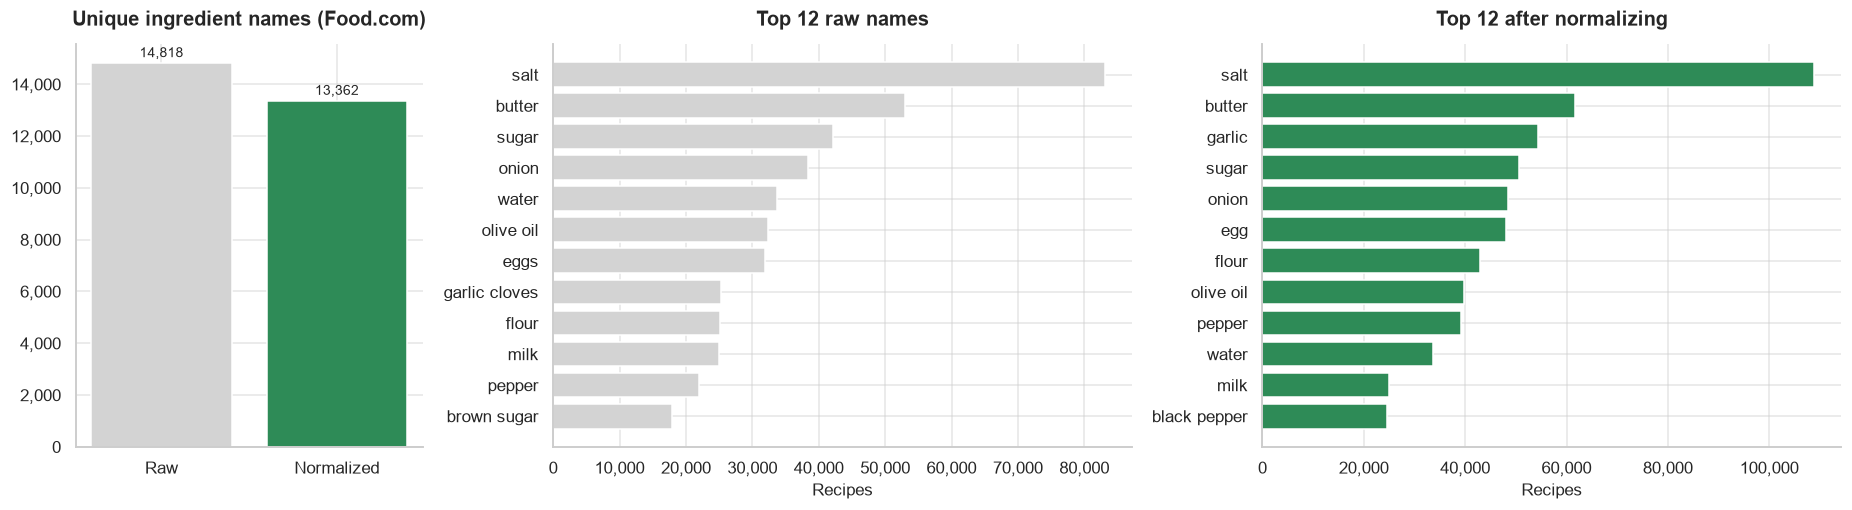

In [43]:
from collections import Counter

raw_top = Counter(i for lst in df_fc["ingredients"].apply(clean_ingredients) for i in lst).most_common(12)
norm_top = Counter(i for lst in df_fc["ingredient_list"] for i in lst).most_common(12)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [0.6, 1, 1]})
axes[0].bar(["Raw", "Normalized"], [len(raw_names), len(norm_names)], color=["lightgray", "seagreen"])
label_bars(axes[0])
thousands(axes[0])
axes[0].set_title("Unique ingredient names (Food.com)")
for ax, top, title, color in [(axes[1], raw_top, "Top 12 raw names", "lightgray"),
                              (axes[2], norm_top, "Top 12 after normalizing", "seagreen")]:
    names, counts = zip(*top[::-1])
    ax.barh(names, counts, color=color)
    ax.set_title(title)
    ax.set_xlabel("Recipes")
    thousands(ax, "x")
show_figure(fig, "07_ingredient_normalization")

---

### 5.4.5 Recipe Complexity

In [44]:
# -------------------------------------------------------
# 5.4.5 Recipe Complexity Proxy
# We define complexity as the number of unique ingredients
# in a recipe. More ingredients typically means more prep
# work and a harder recipe for the Chef Agent to explain.
# -------------------------------------------------------

for df in (df_fc, df_hf):
    df["complexity"] = df["ingredient_list"].apply(lambda lst: len(set(lst)))

print("Recipe complexity statistics (number of unique ingredients, Food.com):")
print(df_fc["complexity"].describe())
print()
print("Example simple recipe (fewest ingredients):")
print(df_fc.nsmallest(1, "complexity")[["name", "complexity", "ingredient_list"]].values)

Recipe complexity statistics (number of unique ingredients, Food.com):
count    225145.000000
mean          9.092078
std           3.722454
min           1.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          43.000000
Name: complexity, dtype: float64

Example simple recipe (fewest ingredients):
[['apple cider reduction' 1 list(['apple cider'])]]


---

### 5.4.6 Country and Region of Origin

Each source says where some recipes come from, in its own way: "italian", "Italy" and "european, italian" all mean Italy. We map every label that names **one country** to `origin_country`, and keep `origin_region` only when the source itself names a region (Sichuan, Louisiana for Cajun and Creole, Quebec, Oaxaca, Scotland...).

- Broad labels that cover several countries ("asian", "caribbean", "indian subcontinent", "scandinavia") give no country here. Section 5.9 predicts a country for those recipes when a model is confident enough.
- Recipes without a country get `Unknown`, never an empty value, so code that reads the table always finds the column.
- Religious and cultural diets (halal, kosher, Jain) are not origins: they are handled as diet rules in 5.4.7.

In [45]:
# -------------------------------------------------------
# 5.4.6 Country (and region) of origin from the sources' own labels.
# Only labels that name one country are used. Broad labels such as
# "asian", "caribbean" or "indian subcontinent" cover several
# countries, so they give no country here (5.9 may predict one).
# A region is kept only when the source names it ("szechuan").
# -------------------------------------------------------
from everflavor.cuisine import ORIGIN_LABELS, origin_from_labels

print(f"{len(ORIGIN_LABELS)} labels map to a country; "
      f"{sum(region is not None for _, region in ORIGIN_LABELS.values())} of them also to a region")

# Coverage of the labels in the raw sources (the pipeline in 5.5 applies the same function)
for name, labels in [("Food.com tags", df_fc["tags"]), ("Hugging Face cuisine_type", df_hf["cuisine_type"])]:
    origins = labels.apply(origin_from_labels)
    known = origins.str[0] != "Unknown"
    print(f"{name:26s}: {known.mean() * 100:4.0f}% name one country, "
          f"{origins.str[1].notna().mean() * 100:.1f}% also a region")
print("\nExamples:", {label: origin_from_labels(label) for label in
                      ["['mexican', 'tex-mex']", "['iranian-persian']", "['asian']", "['american', 'italian']"]})

149 labels map to a country; 25 of them also to a region


Food.com tags             :   30% name one country, 6.8% also a region
Hugging Face cuisine_type :   75% name one country, 0.0% also a region

Examples: {"['mexican', 'tex-mex']": ('United States', 'Texas'), "['iranian-persian']": ('Iran', None), "['asian']": ('Unknown', None), "['american', 'italian']": ('Unknown', None)}


### 5.4.7 Diet Profiles

Most diets are combinations of the ingredient flags from 5.4.2, so each diet is written **once**, as a rule, in `DIET_PROFILES`. The recipe table (5.6.3), the validation checks (5.10) and the safety filter (6.3) all read the same rules, so they can never disagree.

| Diet | A recipe fits when it has no... |
|---|---|
| `halal_friendly` | pork, alcohol or gelatin |
| `kosher_friendly` | pork, shellfish, gelatin, scaleless fish, other unclean meat or carmine, and does not combine meat with dairy |
| `pescatarian` | meat or poultry (fish is allowed) |
| `no_beef` | beef or gelatin (for example for many Hindu diets) |
| `jain_friendly` | meat, fish, egg, honey, alcohol, root vegetables, onion or garlic |
| `lower_sodium` | more than 600 mg sodium per serving |
| `low_carb` | more than 15 g carbohydrate per serving |
| `lacto_vegetarian` | meat, fish or egg |
| `vaishnava_friendly` | meat, fish, egg, onion, garlic, mushrooms or alcohol (Vaishnava, ISKCON, Swaminarayan) |
| `buddhist_vegetarian` | meat, fish, egg, alcohol or the five pungent plants: onion, garlic, leek, chives, asafoetida (Mahayana) |
| `orthodox_fasting` | meat, fish, dairy or egg; shellfish allowed (Orthodox Christian and Ethiopian / Eritrean Orthodox fasting days) |
| `adventist_friendly` | pork, shellfish, scaleless fish, other unclean meat, alcohol, coffee or tea |
| `lds_friendly` | alcohol, coffee or tea (Latter-day Saints) |
| `ital_friendly` | animal products, alcohol or added salt (Rastafari Ital) |
| `alpha_gal_friendly` | red meat or gelatin (alpha-gal syndrome) |
| `pregnancy_friendly` | alcohol, high-mercury fish, raw animal foods or soft cheese |
| `g6pd_friendly` | fava beans |
| `gout_friendly` | high-purine foods |
| `low_tyramine` | high-tyramine foods (MAOI medicines) |
| `nightshade_free` | tomato, potato, peppers and chilies, eggplant |

**What "-friendly" means:** the ingredients contain nothing the diet forbids. Ingredients cannot show whether meat was slaughtered the halal or kosher way, or whether a product is certified, so these columns never claim certification. Religious practice also varies; the rules above are the common core, and a user can always add more restrictions.

**Medical profiles** (alpha-gal to nightshade) only say that none of the listed ingredients appear: they are screens to discuss with a doctor or dietitian, never medical advice (policy P17).

**Allergens by country:** `ALLERGEN_SETS` lists the flags each country or region requires on labels (US 9, EU / UK 14, Canada, Australia / NZ, Japan, South Korea). The safety filter takes such a list directly, for example `passes_safety_filter(row, avoid=ALLERGEN_SETS["Japan"])`.

**Nutrition-based diets** use the nutrition columns, so only recipes with listed, believable nutrition can qualify. Estimated values (5.8) are too uncertain to promise "low sodium".

In [46]:
# -------------------------------------------------------
# 5.4.7 Diet profiles (src/everflavor/diets.py): each diet is a
# rule over the flags from 5.4.2.
#   without     : flags that must be False
#   require     : flags that must be True
#   not_together: pairs of flags that must not both be True
# Nutrition-based diets only count listed, plausible nutrition.
# -------------------------------------------------------
from everflavor.diets import (  # noqa: F401
    DIET_COLUMNS,
    DIET_PROFILES,
    NUTRITION_DIETS,
    add_diet_profiles,
    describe_diet_rules,
    diet_flags_needed,
    meets_diet,
)

print("Diet rules:")
for line in describe_diet_rules():
    print(f"  {line}")

Diet rules:
  halal_friendly     : no pork, alcohol, gelatin, pet_meat
  kosher_friendly    : no pork, shellfish, gelatin, scaleless_fish, unclean_meat, carmine, pet_meat; not meat with dairy
  pescatarian        : no meat
  no_beef            : no beef, gelatin
  jain_friendly      : no egg, honey, alcohol, root_vegetable, allium; must be vegetarian
  lacto_vegetarian   : no egg; must be vegetarian
  vaishnava_friendly : no egg, allium, mushroom, alcohol; must be vegetarian
  buddhist_vegetarian: no egg, allium, asafoetida, alcohol; must be vegetarian
  orthodox_fasting   : no meat, fish, dairy, egg
  adventist_friendly : no pork, shellfish, scaleless_fish, unclean_meat, pet_meat, alcohol, coffee_or_tea
  lds_friendly       : no alcohol, coffee_or_tea
  ital_friendly      : no alcohol, added_salt; must be vegan
  alpha_gal_friendly : no red_meat, gelatin
  pregnancy_friendly : no alcohol, high_mercury_fish, raw_animal, soft_cheese
  g6pd_friendly      : no fava
  gout_friendly      : 

---

## 5.5 Transformation Pipeline

We wrap all cleaning and feature engineering steps into a reusable function that handles every source (Food.com, Hugging Face, CulinaryDB, TheMealDB) and returns the same columns for each, so they can be combined in 5.6. This makes it easy to re-apply the pipeline to new data or to test variations.

#### 5.5.1 The run_pipeline() function

In [47]:
# run_pipeline() applies every step above to one raw source, using the same
# functions as the step-by-step cells (src/everflavor/pipeline.py), so both
# paths produce the same features. Every source ends with COMMON_COLUMNS.
from everflavor.pipeline import COMMON_COLUMNS, run_pipeline

print(f"run_pipeline() returns {len(COMMON_COLUMNS)} columns for every source:")
print(", ".join(COMMON_COLUMNS))

run_pipeline() returns 63 columns for every source:
recipe_id, source, recipe_name, cuisine_family, cuisine_raw, ingredient_list, complexity, calories_per_serving, protein_g, fat_g, carbs_g, sodium_mg, servings, minutes, instructions, url, origin_country, origin_region, contains_pork, contains_alcohol, contains_gluten, contains_dairy, contains_egg, contains_peanut, contains_tree_nut, contains_fish, contains_shellfish, contains_crustacean, contains_mollusc, contains_soy, contains_sesame, contains_mustard, contains_celery, contains_lupin, contains_buckwheat, contains_sulfites, contains_meat, contains_beef, contains_red_meat, contains_poultry, contains_processed_meat, contains_gelatin, contains_honey, contains_root_vegetable, contains_allium, contains_asafoetida, contains_mushroom, contains_carmine, contains_scaleless_fish, contains_unclean_meat, contains_pet_meat, contains_coffee_or_tea, contains_added_salt, contains_alcohol_extract, contains_fava, contains_nightshade, contains_high_merc

#### 5.5.2 Run the pipeline on every source

In [48]:
# Re-run the pipeline on every dataset (clean start)
df_fc_clean = run_pipeline(recipes_raw, source="foodcom")
df_hf_clean = run_pipeline(hf_df, source="huggingface")
extra_clean = {name: run_pipeline(df, source=name) for name, df in extra_raw.items()}

print(f"Food.com after pipeline     : {df_fc_clean.shape}")
print(f"Hugging Face after pipeline : {df_hf_clean.shape}")
for name, df in extra_clean.items():
    print(f"{name + ' after pipeline':28s}: {df.shape}")

Restriction flags:   0%|          | 0/43 [00:00<?, ?it/s]

Restriction flags:   0%|          | 0/43 [00:00<?, ?it/s]

Restriction flags:   0%|          | 0/43 [00:00<?, ?it/s]

Food.com after pipeline     : (225145, 63)
Hugging Face after pipeline : (38043, 63)
culinarydb after pipeline   : (44421, 63)
themealdb after pipeline    : (791, 63)


---

## 5.6 Combine All Sources

We stack every cleaned source into one recipe table. The same recipe can appear in more than one source (CulinaryDB, for example, was built from Allrecipes, Food Network and Epicurious, which overlap with the others). We treat recipes with the same title (ignoring case and punctuation) as duplicates and keep the copy with the most information: Hugging Face first (exact nutrition and health labels), then Food.com, TheMealDB and CulinaryDB.

After combining we also:
- drop recipes with fewer than 2 ingredients;
- mark which recipes have nutrition data (`has_nutrition`) and whether it is believable (`nutrition_plausible`): at least 10 kcal, at most 5,000 mg sodium and 150 g protein, and protein, fat and carbs that add up to within 30% of the listed calories;
- mark which recipes have a real cuisine label (`cuisine_labeled`), so cuisine models can treat "Other" as unlabeled instead of as a sixth cuisine;
- give recipes with exactly the same ingredients the same `ingredient_group`, so the split in 5.7 can keep near-duplicates together.

#### 5.6.1 Combine, remove duplicates and add quality columns

In [49]:
from everflavor.nutrition import (
    MACRO_TOLERANCE,
    NUTRITION_LIMITS,
    nutrition_checks,
)
from everflavor.pipeline import (
    SOURCE_PRIORITY,
    combine_sources,
    remove_excluded_recipes,
)

# Stack the sources; duplicate titles keep the copy from the source that comes
# first in SOURCE_PRIORITY; recipes with fewer than 2 ingredients are dropped;
# then the quality columns are added (combine_sources() in src/everflavor/pipeline.py)
df_all, counts_before, dropped_small = combine_sources([df_hf_clean, df_fc_clean, *extra_clean.values()])
print(f"Dropped {dropped_small:,} recipes with fewer than 2 ingredients")

# Recipes the project never serves (policies P24, P25): meat from household pets,
# and recipes made for animals instead of people (dog biscuits, food for dogs)
df_all, excluded = remove_excluded_recipes(df_all)
for reason, n in excluded.items():
    print(f"Removed {n:,} recipes: {reason}")

# --- Nutrition quality: which checks do the recipes with nutrition data fail? ---
checks = nutrition_checks(df_all)
print("\nNutrition checks (recipes with nutrition data that fail each one):")
for name, passed in checks[df_all["has_nutrition"]].items():
    print(f"  {name:28s}: {(~passed).sum():>6,}")
print(f"  {'plausible overall':28s}: {df_all['nutrition_plausible'].sum():>6,} of {df_all['has_nutrition'].sum():,}")

counts_after = df_all["source"].value_counts()
summary = pd.DataFrame({"before": counts_before, "kept": counts_after}).fillna(0).astype(int)
summary["removed"] = summary["before"] - summary["kept"]
print("Recipes per source:")
print(summary.loc[[s for s in SOURCE_PRIORITY if s in summary.index]].to_string())
print(f"\nCombined table: {len(df_all):,} recipes, {df_all.shape[1]} columns")

print("\nCuisine family by source:")
print(pd.crosstab(df_all["cuisine_family"], df_all["source"], margins=True, margins_name="total").to_string())

Dropped 243 recipes with fewer than 2 ingredients


Removed 0 recipes: meat from household pets
Removed 16 recipes: made for pets, not people

Nutrition checks (recipes with nutrition data that fail each one):
  at least 10 kcal            :  1,263
  sodium <= 5,000 mg          :  1,669
  protein <= 150 g            :    263
  macros match calories       :  8,393
  plausible overall           : 245,452 of 255,847
Recipes per source:
             before    kept  removed
source                              
huggingface   38043   37823      220
foodcom      225145  218024     7121
themealdb       791     583      208
culinarydb    44421   35325     9096

Combined table: 291,755 recipes, 67 columns

Cuisine family by source:
source          culinarydb  foodcom  huggingface  themealdb   total
cuisine_family                                                     
African                448     2694            0         37    3179
Asian                 5950    11553         3172        113   20788
European             11292    22839        13792 

#### 5.6.2 Chart: combining the sources

> **What it shows:** How many recipes each source keeps after removing duplicates, how the cuisine families are spread across sources, and which nutrition checks recipes fail.

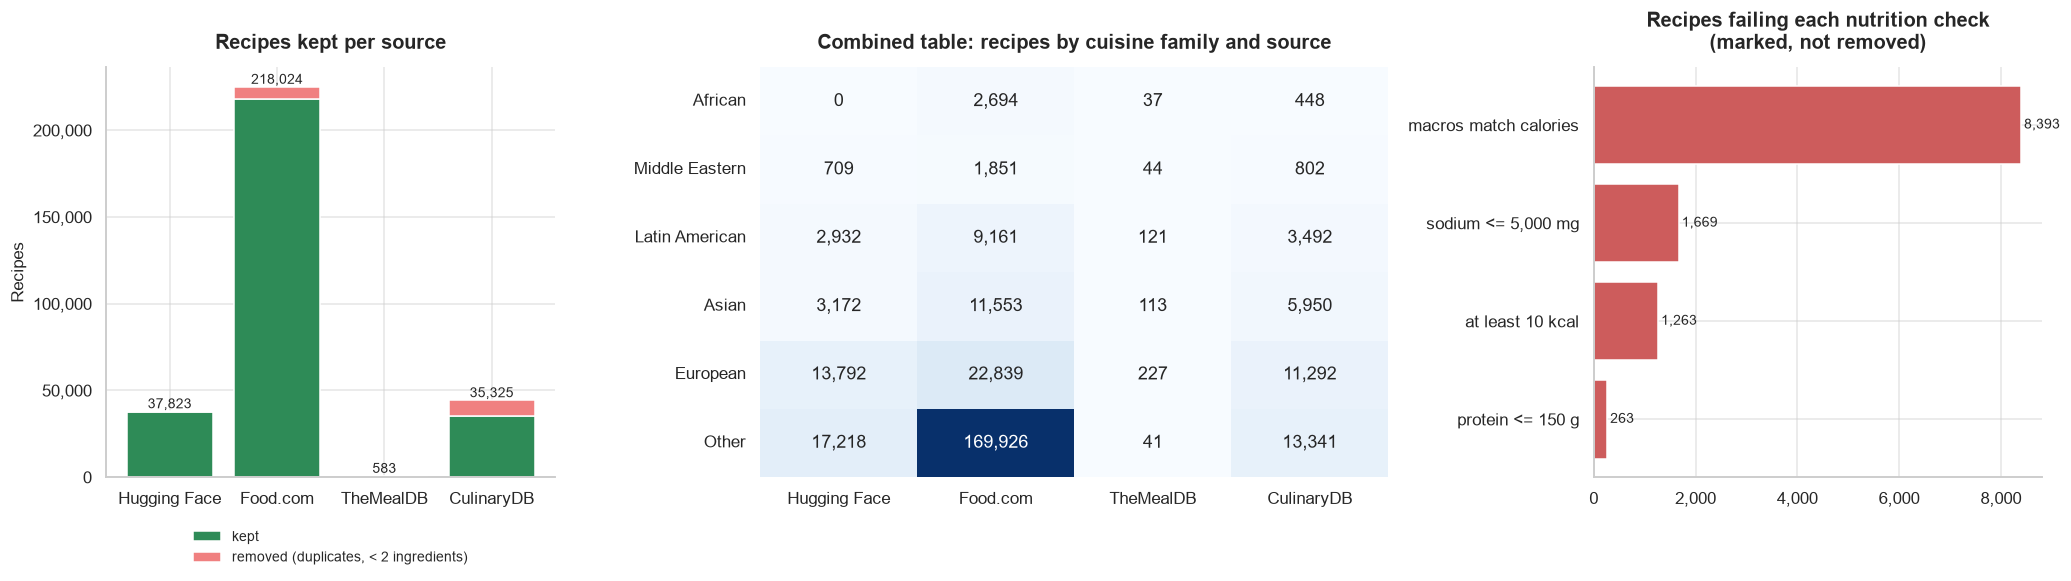

In [50]:
order = [s for s in SOURCE_PRIORITY if s in summary.index]
labels = [SOURCE_LABELS[s] for s in order]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), gridspec_kw={"width_ratios": [1, 1.4, 1]})
kept, removed = summary.loc[order, "kept"], summary.loc[order, "removed"]
axes[0].bar(labels, kept, color="seagreen", label="kept")
axes[0].bar(labels, removed, bottom=kept, color="lightcoral", label="removed (duplicates, < 2 ingredients)")
for x, (k, r) in enumerate(zip(kept, removed)):
    axes[0].text(x, k + r, f"{k:,}", ha="center", va="bottom", fontsize=9)
# Legend under the chart, so it never covers the bars
axes[0].legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=1)
axes[0].set_ylabel("Recipes")
thousands(axes[0])
axes[0].set_title("Recipes kept per source")

by_cuisine = (pd.crosstab(df_all["cuisine_family"], df_all["source"])
              .reindex(index=FAMILY_ORDER, columns=order).fillna(0))
by_cuisine.columns = labels
sns.heatmap(by_cuisine, annot=True, fmt=",.0f", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("Combined table: recipes by cuisine family and source")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fails = (~checks[df_all["has_nutrition"]]).sum().sort_values()
axes[2].barh(fails.index, fails.values, color="indianred")
label_bars(axes[2])
thousands(axes[2], "x")
axes[2].set_title("Recipes failing each nutrition check\n(marked, not removed)")
show_figure(fig, "08_combining_sources")

#### 5.6.3 Diet profiles for every recipe

The rules from 5.4.7, applied to the combined table.

In [51]:
df_all = add_diet_profiles(df_all)

diet_summary = pd.DataFrame({
    "recipes": df_all[DIET_COLUMNS].sum(),
    "share (%)": df_all[DIET_COLUMNS].mean().mul(100).round(1),
})
print("Recipes that fit each diet:")
print(diet_summary.to_string())
print(f"\nFor comparison: vegetarian {df_all['vegetarian'].mean() * 100:.1f}%, "
      f"vegan {df_all['vegan'].mean() * 100:.1f}%")

Recipes that fit each diet:
                     recipes  share (%)
halal_friendly        221871       76.0
kosher_friendly       202085       69.3
pescatarian           183522       62.9
no_beef               259369       88.9
jain_friendly          44712       15.3
lacto_vegetarian      104852       35.9
vaishnava_friendly     54579       18.7
buddhist_vegetarian    54619       18.7
orthodox_fasting       51297       17.6
adventist_friendly    212342       72.8
lds_friendly          253677       86.9
ital_friendly          17447        6.0
alpha_gal_friendly    224848       77.1
pregnancy_friendly    253833       87.0
g6pd_friendly         291396       99.9
gout_friendly         285266       97.8
low_tyramine          229878       78.8
nightshade_free       171820       58.9
lower_sodium          168091       57.6
low_carb               81632       28.0

For comparison: vegetarian 55.2%, vegan 15.5%


#### 5.6.4 Chart: diet profiles by cuisine family

> **What it shows:** The share of recipes in each cuisine family that fit each diet. Darker means more choice for someone on that diet. Low numbers show where the Chef Agent will need substitutions (for example Jain-friendly recipes are rare, because onion, garlic and potato are everywhere).

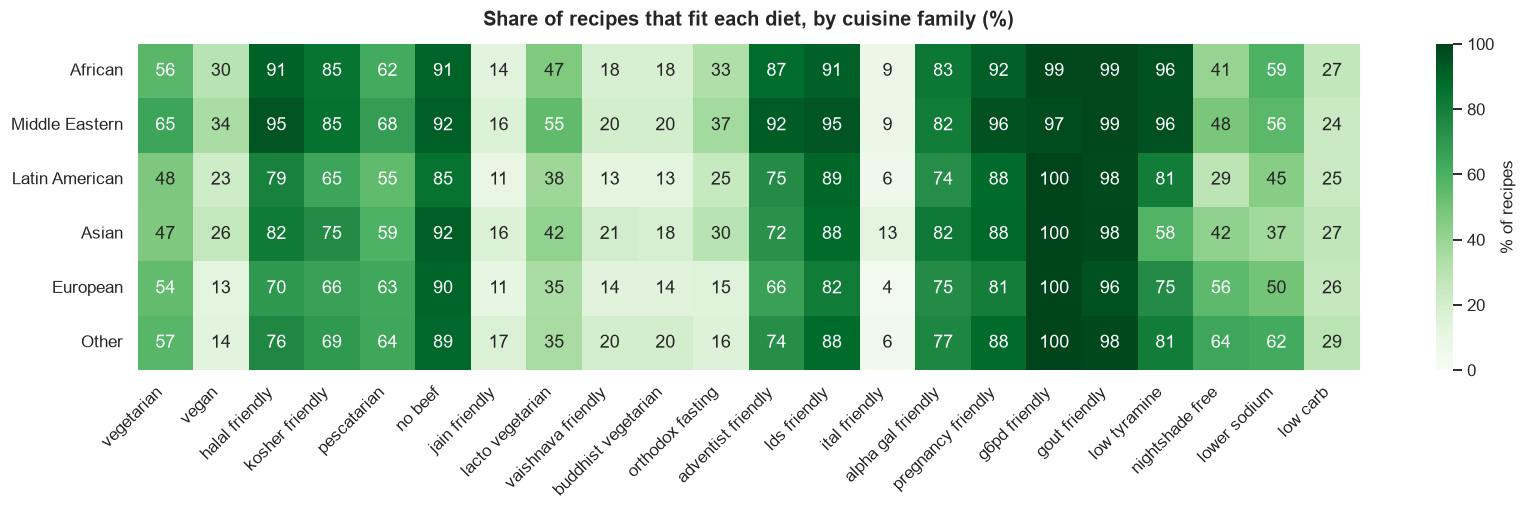

In [52]:
diet_columns_shown = ["vegetarian", "vegan", *DIET_COLUMNS]
families_shown = [f for f in FAMILY_ORDER if (df_all["cuisine_family"] == f).any()]
diet_share = (df_all.groupby("cuisine_family")[diet_columns_shown].mean().mul(100)
              .reindex(families_shown))
diet_share.columns = [c.replace("_", " ") for c in diet_share.columns]

# one column per diet, so the figure grows with the number of diets
fig, ax = plt.subplots(figsize=(max(14, 0.7 * len(diet_columns_shown)), 4.8))
sns.heatmap(diet_share, annot=True, fmt=".0f", cmap="Greens", vmin=0, vmax=100, cbar_kws={"label": "% of recipes"},
            ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.setp(ax.get_xticklabels(), ha="right")
ax.set_title("Share of recipes that fit each diet, by cuisine family (%)")
show_figure(fig, "18_diet_profiles")

---

## 5.7 Train / Validation / Test Split

We split the combined recipe table using a **stratified split by cuisine family** so that every family keeps the same share in each partition. The split ratio is approximately 70% train, 15% validation, 15% test.

Recipes with exactly the same ingredients but different titles are near-duplicates. If one landed in train and its twin in test, test scores would look better than they really are (data leakage). So we split **ingredient groups**, not single recipes: every recipe in a group goes to the same split. A check at the end confirms that no group appears in two splits.

The test split is not used anywhere in this notebook. It is kept for the final Week 7 evaluation.

#### 5.7.1 Split by ingredient group

In [53]:
from everflavor.pipeline import split_by_ingredient_group, split_tables

# Split ingredient groups (5.6), not single recipes, so near-duplicates
# never end up in different splits. Each group is stratified by the
# cuisine family of its first recipe; families with fewer than
# MIN_PER_FAMILY groups are grouped with 'Other' for the split only.
MIN_PER_FAMILY = 10
df_all = split_by_ingredient_group(df_all, seed=42, min_per_family=MIN_PER_FAMILY)
train_df, val_df, test_df = split_tables(df_all)
print("Dataset split summary:")
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name:5s}: {len(df):>7,} rows ({len(df) / len(df_all) * 100:.1f}%)")

# Leakage check: no ingredient group may appear in two splits
shared = (set(train_df["ingredient_group"]) & set(test_df["ingredient_group"])) | \
         (set(train_df["ingredient_group"]) & set(val_df["ingredient_group"])) | \
         (set(val_df["ingredient_group"]) & set(test_df["ingredient_group"]))
print(f"\nIngredient groups shared between splits: {len(shared)} (must be 0)")

print("\nCuisine family distribution in each split (%):")
print(pd.DataFrame({name: df["cuisine_family"].value_counts(normalize=True).mul(100).round(1)
                    for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]}).to_string())

Dataset split summary:
  Train: 204,114 rows (70.0%)
  Val  :  43,816 rows (15.0%)
  Test :  43,825 rows (15.0%)



Ingredient groups shared between splits: 0 (must be 0)

Cuisine family distribution in each split (%):
                Train   Val  Test
cuisine_family                   
Other            68.7  68.8  68.7
European         16.5  16.5  16.5
Asian             7.1   7.1   7.1
Latin American    5.4   5.4   5.4
Middle Eastern    1.2   1.2   1.2
African           1.1   1.1   1.1


#### 5.7.2 Chart: the three splits

> **What it shows:** Each cuisine family should have the same share in train, validation and test. Matching bars mean the split is balanced.

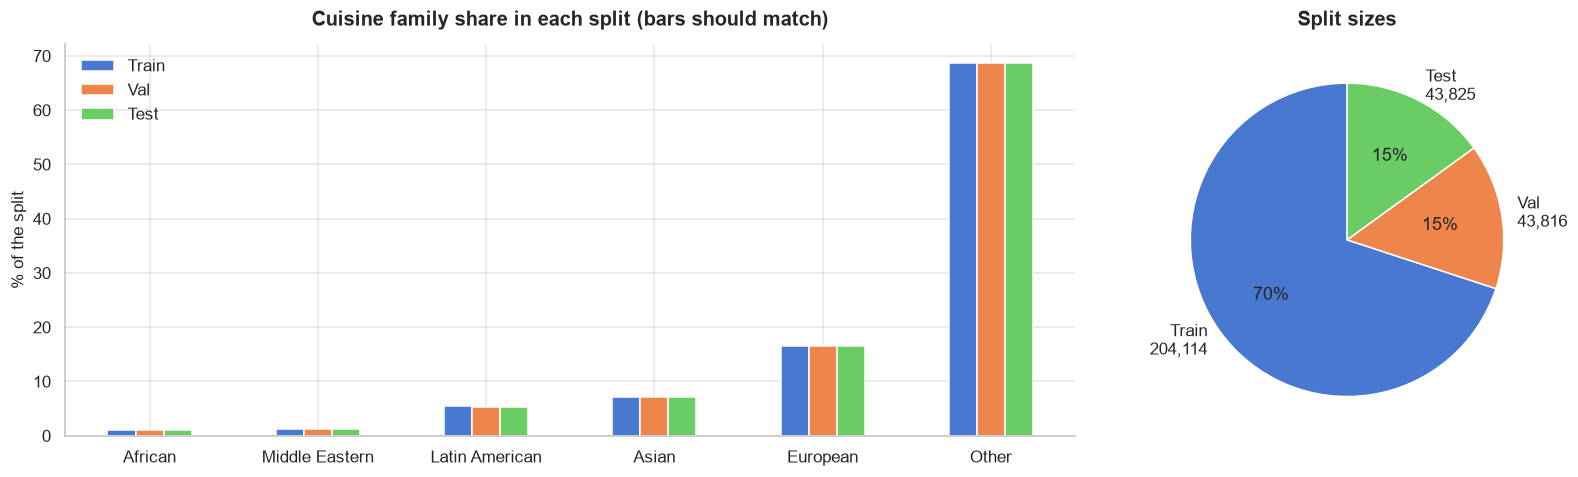

In [54]:
split_share = pd.DataFrame({name: df["cuisine_family"].value_counts(normalize=True).mul(100)
                            for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]}
                           ).reindex(FAMILY_ORDER).fillna(0)
sizes = pd.Series({"Train": len(train_df), "Val": len(val_df), "Test": len(test_df)})

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), gridspec_kw={"width_ratios": [2, 1]})
split_share.plot.bar(ax=axes[0], rot=0)
axes[0].set_ylabel("% of the split")
axes[0].set_xlabel("")
axes[0].set_title("Cuisine family share in each split (bars should match)")
axes[1].pie(sizes, labels=[f"{k}\n{v:,}" for k, v in sizes.items()], autopct="%1.0f%%",
            colors=sns.color_palette("muted", 3), startangle=90)
axes[1].set_title("Split sizes")
show_figure(fig, "09_splits")

---

## 5.8 Fill In Missing Nutrition

More than 46,000 recipes have no believable calorie data: all of CulinaryDB and TheMealDB (they publish no nutrition), plus the Food.com and Hugging Face recipes that failed the checks in 5.6. The Nutritionist Agent needs a calorie value for every recipe, so we estimate the missing ones from two kinds of evidence:

1. **Similar recipes with real nutrition.** A model learns calories per serving from the titles and ingredients of the training recipes whose listed nutrition passed every check.
2. **Official USDA data.** [USDA FoodData Central](https://fdc.nal.usda.gov/) publishes two free bulk downloads (no API key needed):
   - **FNDDS** (the survey food database): about 5,400 prepared dishes ("Rice, fried", "Vegetable curry") with calories per 100 g and a typical portion weight, which gives official calories per serving.
   - **SR Legacy**: about 7,800 single ingredients with nutrients per 100 g.

   Each recipe is matched to its closest USDA dishes by title, and each ingredient to a USDA ingredient. These matches become extra inputs for the model.

**What to expect:** CulinaryDB lists no ingredient amounts and no servings, so no method can compute exact calories for it. The estimates are labeled clearly instead:
- `nutrition_source` is `listed` (real data) or `estimated`;
- `calories_est_min` and `calories_est_max` give the likely range (8 in 10 real values fall inside it);
- `usda_dish` and `usda_dish_kcal` name the closest official USDA dish and its calories per serving, as a reference anyone can check.

The model is trained on the training split only, and its accuracy is measured on validation recipes whose real calories we know. The baseline recommender in 6.3 still ranks only recipes with listed nutrition.

#### 5.8.1 Download the USDA reference data

In [55]:
from everflavor.sources import USDA_DOWNLOADS, USDA_NUTRIENTS, usda_table

# -------------------------------------------------------
# USDA FoodData Central bulk downloads: official, free, no key.
# Saved once to data/raw/usda_fdc/ and reused unless
# REFRESH_DOWNLOADS is True (set in 2.3).
# -------------------------------------------------------
USDA_DIR = Path("data/raw/usda_fdc")

usda_dishes = usda_table("fndds", USDA_DIR, refresh=REFRESH_DOWNLOADS).dropna(subset=["serving_g"]).reset_index(drop=True)
usda_dishes["kcal_serving"] = usda_dishes["kcal_100g"] * usda_dishes["serving_g"] / 100
usda_ingredients = usda_table("sr_legacy", USDA_DIR, refresh=REFRESH_DOWNLOADS).drop(columns="serving_g")
print(f"USDA FNDDS dishes    : {len(usda_dishes):,} (each with a typical portion weight)")
print(f"USDA SR Legacy foods : {len(usda_ingredients):,}")
print("\nExample dishes:")
examples = usda_dishes[usda_dishes["description"].isin(
    ["Rice, fried, NFS", "Vegetable curry", "Bread, paratha", "Lasagna with meat", "Hummus, plain"])]
print(examples[["description", "serving_g", "kcal_100g", "kcal_serving"]]
      .rename(columns={"serving_g": "typical serving (g)", "kcal_100g": "kcal per 100 g",
                       "kcal_serving": "kcal per serving"})
      .round(0).to_string(index=False))

USDA FNDDS dishes    : 5,362 (each with a typical portion weight)
USDA SR Legacy foods : 7,793

Example dishes:
      description  typical serving (g)  kcal per 100 g  kcal per serving
    Hummus, plain                 60.0           243.0             146.0
   Bread, paratha                 70.0           326.0             228.0
Lasagna with meat                250.0           139.0             348.0
 Rice, fried, NFS                198.0           174.0             345.0
  Vegetable curry                240.0            86.0             206.0


#### 5.8.2 Match recipes to USDA dishes and ingredients

- **Dishes:** each recipe title is compared with every USDA dish description. The title's main word (usually its last word: "coconut cabbage **curry**") must appear in the dish description, which stops matches such as "spice vegetable fried rice" -> "spice cake". We keep the 5 best matches.
- **Ingredients:** each ingredient name is matched to a USDA ingredient, preferring raw, plain entries. Common ingredients that automatic matching gets wrong (for example "flour" -> potato flour, "milk" -> dried buttermilk) use a hand-checked USDA entry instead, like the sample in 2.4.1.2.

The matched ingredients are saved as `data/processed/usda_ingredient_nutrition.csv`, a per-100 g nutrition table the Nutritionist Agent can use directly.

In [56]:
# Matching functions and the hand-checked ingredient matches are in
# src/everflavor/nutrition.py (match_dishes, match_ingredients, INGREDIENT_USDA).
from everflavor.nutrition import (
    dish_features,
    ingredient_energy_features,
    ingredient_nutrition_table,
    match_dishes,
    missing_hand_checked,
)

# ---------------------------------------------------------------
# 1. Recipe title -> closest USDA dishes
# ---------------------------------------------------------------
dish_scores, dish_positions = match_dishes(df_all["recipe_name"].tolist(), usda_dishes)
dish_matched = dish_scores[:, 0] > 0
usda_features = dish_features(usda_dishes, dish_scores, dish_positions).set_index(df_all.index)

# The single closest dish, kept in the data as a reference anyone can check
best_dish = dish_positions[:, 0]
df_all["usda_dish"] = np.where(dish_matched, usda_dishes["description"].to_numpy()[best_dish], None)
df_all["usda_dish_kcal"] = np.where(dish_matched, usda_dishes["kcal_serving"].to_numpy()[best_dish].round(0), np.nan)
print(f"Recipes matched to a USDA dish: {dish_matched.mean() * 100:.0f}%")

# ---------------------------------------------------------------
# 2. Ingredient name -> USDA ingredient
# ---------------------------------------------------------------
missing_entries = missing_hand_checked(usda_ingredients)
if missing_entries:
    raise ValueError(f"These hand-checked USDA entries are not in the download: {missing_entries}")

ingredient_nutrition, ingredient_counts = ingredient_nutrition_table(
    df_all["ingredient_list"], usda_ingredients, list(USDA_NUTRIENTS.values()))

INGREDIENT_TABLE_FILE = Path("data/processed/usda_ingredient_nutrition.csv")
ingredient_nutrition.to_csv(INGREDIENT_TABLE_FILE, index=False)

uses_matched = ingredient_nutrition["recipes"].sum() / sum(ingredient_counts.values())
print(f"Ingredient names matched to USDA: {len(ingredient_nutrition):,} of {len(ingredient_counts):,} "
      f"({uses_matched * 100:.0f}% of all ingredient uses)")
print(f"Saved to {INGREDIENT_TABLE_FILE.as_posix()}\n")
print(ingredient_nutrition.head(12)[["ingredient", "usda_description", "kcal_100g", "match"]].to_string(index=False))

# ---------------------------------------------------------------
# 3. Recipe-level energy features from the matched ingredients.
#    Amounts are unknown, so these describe how energy-dense the
#    ingredients are (oil, butter, sugar, nuts), not the total.
# ---------------------------------------------------------------
kcal_per_100g = dict(zip(ingredient_nutrition["ingredient"], ingredient_nutrition["kcal_100g"]))
energy = ingredient_energy_features(df_all["ingredient_list"], kcal_per_100g)
usda_features = pd.concat([usda_features, energy], axis=1)

Matching USDA dishes:   0%|          | 0/291755 [00:00<?, ?it/s]

Recipes matched to a USDA dish: 89%


Matching USDA ingredients:   0%|          | 0/46345 [00:00<?, ?it/s]

Ingredient names matched to USDA: 39,969 of 46,345 (97% of all ingredient uses)
Saved to data/processed/usda_ingredient_nutrition.csv

  ingredient                                    usda_description  kcal_100g        match
        salt                                         Salt, table        0.0    automatic
      butter                                      Butter, salted      717.0 hand-checked
      garlic                                         Garlic, raw      149.0    automatic
       sugar                                  Sugars, granulated      387.0 hand-checked
       onion                                         Onions, raw       40.0    automatic
         egg                              Egg, whole, raw, fresh      143.0 hand-checked
   olive oil                        Oil, olive, salad or cooking      884.0 hand-checked
       flour Wheat flour, white, all-purpose, enriched, bleached      364.0 hand-checked
      pepper                               Spices, pepper, black

#### 5.8.3 Train the estimator and measure its accuracy

Two models, both trained on **training recipes with listed, believable nutrition**:

1. A **ridge regression** on the words in the title and the ingredient list ("cookies" and "butter" mean more calories, "salad" and "broth" fewer).
2. A **gradient-boosted model** that combines the ridge prediction with the USDA evidence from 5.8.2 (closest dishes' calories per serving, energy density of the ingredients) and the number of ingredients.

Protein, fat, carbs and sodium get their own ridge models; protein, fat and carbs are then scaled so they add up to the estimated calories (4, 9 and 4 kcal per gram).

**Accuracy check:** the models predict validation recipes whose real calories we know. Half of them set the likely range (the 10th to 90th percentile of the errors), and the other half measure how good the estimates are, so the reported numbers are honest.

In [57]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict

from everflavor.features import TextFeatures

# Training rows: training split with listed, believable nutrition (no validation or test data)
is_fit = (df_all["split"] == "train") & df_all["nutrition_plausible"]
is_check = (df_all["split"] == "val") & df_all["nutrition_plausible"]
fit_rows, check_rows = df_all[is_fit], df_all[is_check]


# --- Text features: ingredient names and title words (TextFeatures in src/everflavor/features.py) ---
nutrition_features = TextFeatures(title_min_df=3)


def combined_inputs(rows, text_prediction):
    """Ridge prediction + USDA evidence + number of ingredients (missing USDA values are allowed)."""
    return np.column_stack([text_prediction, usda_features.loc[rows.index].to_numpy(),
                            rows["complexity"].to_numpy()])


X_fit, X_check = nutrition_features.fit_transform(fit_rows), nutrition_features.transform(check_rows)
y_fit = np.log(fit_rows["calories_per_serving"].to_numpy())   # log: errors in proportion, not in kcal

# 1. Ridge on text. Its training predictions come from 5-fold cross-validation,
#    so the second model learns from honest (unseen) predictions.
text_model = Ridge(alpha=3.0)
text_fit_prediction = cross_val_predict(text_model, X_fit, y_fit, cv=5)
text_model.fit(X_fit, y_fit)

# 2. Gradient boosting on the ridge prediction + USDA evidence
# Early stopping: up to 500 rounds, but training stops when 10% of the training rows (held out
# inside the model) stop improving for 10 rounds, so the model does not overfit
calorie_model = HistGradientBoostingRegressor(loss="absolute_error", max_iter=500, learning_rate=0.05,
                                              early_stopping=True, validation_fraction=0.1,
                                              n_iter_no_change=10, random_state=42)
calorie_model.fit(combined_inputs(fit_rows, text_fit_prediction), y_fit)


def estimate_calories(rows, X):
    return np.exp(calorie_model.predict(combined_inputs(rows, text_model.predict(X))))


# --- Macros: one ridge model each, on the same text features ---
MACROS = ["protein_g", "fat_g", "carbs_g", "sodium_mg"]
macro_models = {}
for column in MACROS:
    known = fit_rows[column].notna().to_numpy()
    macro_models[column] = Ridge(alpha=3.0).fit(X_fit[known], np.log1p(fit_rows[column].to_numpy()[known]))


def estimate_macros(X, kcal):
    """Macro estimates; protein, fat and carbs are scaled to add up to the estimated calories."""
    values = {column: np.expm1(model.predict(X)).clip(min=0) for column, model in macro_models.items()}
    macro_kcal = 4 * values["protein_g"] + 9 * values["fat_g"] + 4 * values["carbs_g"]
    scale = np.divide(kcal, macro_kcal, out=np.ones_like(kcal), where=macro_kcal > 0)
    for column in ["protein_g", "fat_g", "carbs_g"]:
        values[column] = values[column] * scale
    return values


# ---------------------------------------------------------------
# Accuracy on validation recipes with real (listed) calories
# ---------------------------------------------------------------
real_kcal = check_rows["calories_per_serving"].to_numpy()
estimated_kcal = estimate_calories(check_rows, X_check)
calibrate = np.random.default_rng(42).random(len(check_rows)) < 0.5   # half sets the range, half measures
measure = ~calibrate

# Likely range: the 10th to 90th percentile of the errors (in proportion), from the calibration half
RANGE_QUANTILES = (0.10, 0.90)
log_errors = np.log(real_kcal) - np.log(estimated_kcal)
range_low, range_high = np.quantile(log_errors[calibrate], RANGE_QUANTILES)
in_range = ((real_kcal >= estimated_kcal * np.exp(range_low)) &
            (real_kcal <= estimated_kcal * np.exp(range_high)))

dish_only = usda_features.loc[check_rows.index, "dish_kcal"].fillna(np.median(np.exp(y_fit))).to_numpy()
METHODS = {
    "Guess the median"                : np.full(len(real_kcal), np.median(np.exp(y_fit))),
    "Closest USDA dishes only"        : dish_only,
    "Similar recipes (title + ingredients)": np.exp(text_model.predict(X_check)),
    "Similar recipes + USDA (used)"   : estimated_kcal,
}


def accuracy(estimate):
    real = real_kcal[measure]
    error = np.abs(estimate[measure] - real)
    return {"average error (kcal)": error.mean(), "typical error (kcal)": np.median(error),
            "within 20% (%)": (error <= 0.2 * real).mean() * 100,
            "within 30% (%)": (error <= 0.3 * real).mean() * 100}


estimate_accuracy = pd.DataFrame({name: accuracy(est) for name, est in METHODS.items()}).T.round(1)
print(f"Accuracy on {measure.sum():,} validation recipes with real calories (not used for training):\n")
print(estimate_accuracy.to_string())
print(f"\nLikely range: estimate x {np.exp(range_low):.2f} to estimate x {np.exp(range_high):.2f}")
print(f"Real value inside the range: {in_range[measure].mean() * 100:.0f}% (target 80%)")

macro_estimates = estimate_macros(X_check, estimated_kcal)
print("\nMacro estimates, typical error on the same recipes:")
for column in MACROS:
    real = check_rows[column].to_numpy()
    ok = measure & ~np.isnan(real)
    print(f"  {column:10s}: {np.median(np.abs(macro_estimates[column][ok] - real[ok])):6.1f} "
          f"(real median {np.median(real[ok]):.1f})")

Accuracy on 18,535 validation recipes with real calories (not used for training):

                                       average error (kcal)  typical error (kcal)  within 20% (%)  within 30% (%)
Guess the median                                      226.4                 147.7            21.8            32.6
Closest USDA dishes only                              253.6                 150.1            17.2            26.0
Similar recipes (title + ingredients)                 186.9                 105.0            29.0            42.8
Similar recipes + USDA (used)                         184.3                 102.8            29.4            43.3

Likely range: estimate x 0.47 to estimate x 2.14
Real value inside the range: 80% (target 80%)

Macro estimates, typical error on the same recipes:
  protein_g :    3.7 (real median 9.5)
  fat_g     :    5.6 (real median 13.7)
  carbs_g   :   10.2 (real median 27.0)
  sodium_mg :  159.2 (real median 360.0)


#### 5.8.4 Fill the gaps

Every recipe without listed, believable nutrition gets the estimates. Listed values are never changed. For the Food.com and Hugging Face recipes whose listed values failed the checks in 5.6, the estimate replaces the unbelievable value (the original stays in the raw files).

In [58]:
from everflavor.reporting import by_source

to_fill = df_all[~df_all["nutrition_plausible"]]
X_fill = nutrition_features.transform(to_fill)
kcal_limits = (NUTRITION_LIMITS["min_kcal"], MAX_KCAL_PER_SERVING)

fill_kcal = estimate_calories(to_fill, X_fill).clip(*kcal_limits)
fill_macros = estimate_macros(X_fill, fill_kcal)

df_all["nutrition_source"] = "listed"
df_all.loc[to_fill.index, "nutrition_source"] = "estimated"
df_all.loc[to_fill.index, "calories_per_serving"] = fill_kcal.round(1)
for column, values in fill_macros.items():
    df_all.loc[to_fill.index, column] = values.round(1)
df_all["calories_est_min"] = np.nan
df_all["calories_est_max"] = np.nan
df_all.loc[to_fill.index, "calories_est_min"] = (fill_kcal * np.exp(range_low)).clip(*kcal_limits).round(0)
df_all.loc[to_fill.index, "calories_est_max"] = (fill_kcal * np.exp(range_high)).clip(*kcal_limits).round(0)

# The splits are separate tables: rebuild them so they include the filled values
train_df, val_df, test_df = split_tables(df_all)

print("Nutrition source by recipe source:")
print(by_source(df_all, "nutrition_source").to_string())
print(f"\nEvery recipe now has calories: {df_all['calories_per_serving'].notna().all()}")

print("\nExamples of filled recipes (kcal per serving):")
examples = df_all[df_all["nutrition_source"] == "estimated"].groupby("source").sample(n=2, random_state=42)
print(examples[["recipe_name", "source", "calories_per_serving", "calories_est_min", "calories_est_max",
                "usda_dish", "usda_dish_kcal"]]
      .rename(columns={"calories_per_serving": "estimate", "calories_est_min": "min",
                       "calories_est_max": "max", "usda_dish_kcal": "USDA kcal"})
      .to_string(index=False, max_colwidth=34))

Nutrition source by recipe source:
nutrition_source  estimated  listed   total
source                                     
CulinaryDB            35325       0   35325
Food.com               8913  209111  218024
Hugging Face           1482   36341   37823
TheMealDB               583       0     583
total                 46303  245452  291755

Every recipe now has calories: True

Examples of filled recipes (kcal per serving):
                       recipe_name      source  estimate   min   max         usda_dish  USDA kcal
   Grapefruit Cups with Wine Syrup  culinarydb     240.0 113.0 513.0   Chocolate syrup      108.0
                  Shrimp Phad Thai  culinarydb     374.8 177.0 802.0    Hot Thai sauce        4.0
           limoncello cosmopolitan     foodcom     129.8  61.0 278.0               NaN        NaN
          chicken in red wine oamc     foodcom     304.6 144.0 652.0         Wine, red      153.0
                Vodka Punch Recipe huggingface     155.7  73.0 333.0   Champagne p

#### 5.8.5 Chart: how good are the estimates?

> **What it shows:** Left: estimated against real calories for validation recipes (points on the dashed line are exact). Middle: the average error of each method; USDA evidence and similar recipes together do best. Right: how often the real value falls inside the likely range, for each cuisine family (the target is 80%).

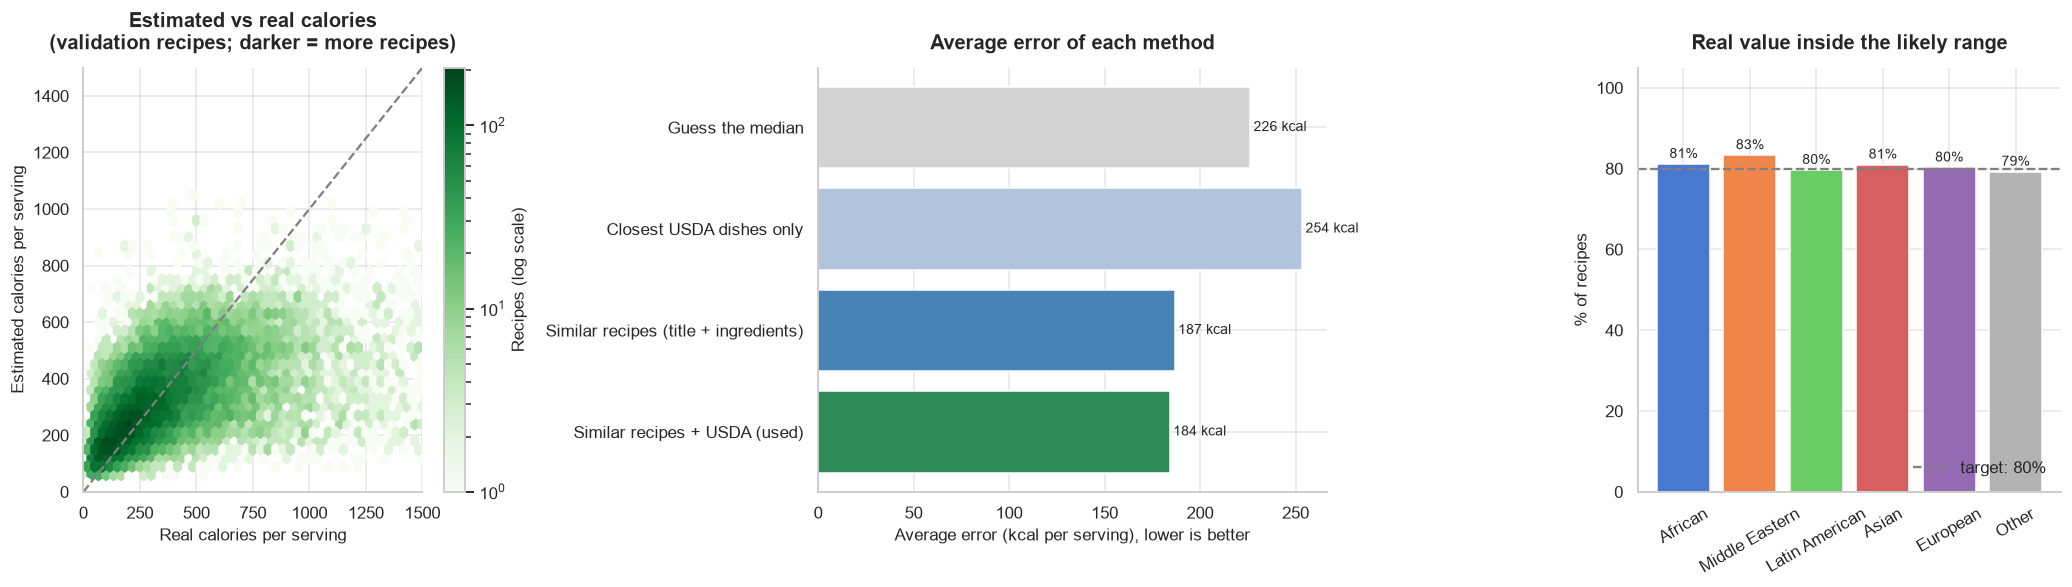

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), gridspec_kw={"width_ratios": [1, 1.2, 1]})

# Left: estimated vs real calories (the half of the validation recipes used for measuring)
limit = 1500
hexes = axes[0].hexbin(real_kcal[measure], estimated_kcal[measure], gridsize=45, cmap="Greens",
                       bins="log", mincnt=1, extent=(0, limit, 0, limit))
axes[0].plot([0, limit], [0, limit], ls="--", color="gray")
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel("Real calories per serving")
axes[0].set_ylabel("Estimated calories per serving")
axes[0].set_title("Estimated vs real calories\n(validation recipes; darker = more recipes)")
fig.colorbar(hexes, ax=axes[0], label="Recipes (log scale)")

# Middle: average error of each method
errors = estimate_accuracy["average error (kcal)"]
colors = ["lightgray", "lightsteelblue", "steelblue", "seagreen"]
axes[1].barh(errors.index, errors.values, color=colors)
label_bars(axes[1], "{:,.0f} kcal")
axes[1].invert_yaxis()
axes[1].set_xlabel("Average error (kcal per serving), lower is better")
axes[1].set_title("Average error of each method")

# Right: real value inside the likely range, by cuisine family
check_family = check_rows["cuisine_family"].to_numpy()
coverage = pd.Series({f: in_range[measure & (check_family == f)].mean() * 100
                      for f in FAMILY_ORDER if (measure & (check_family == f)).any()})
axes[2].bar(coverage.index, coverage.values, color=[FAMILY_COLORS[f] for f in coverage.index])
axes[2].axhline(80, ls="--", color="gray", label="target: 80%")
label_bars(axes[2], "{:.0f}%")
axes[2].set_ylim(0, 105)
axes[2].legend(loc="lower right")
axes[2].set_ylabel("% of recipes")
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_title("Real value inside the likely range")

show_figure(fig, "15_nutrition_estimates")

#### 5.8.6 Chart and table: average and min-to-max calories

> **What it shows:** Left: how many recipes in each source have listed or estimated nutrition, so the gap that was filled is visible. Right: calories per serving for each cuisine family, listed and estimated side by side: the thin line runs from the minimum to the maximum, the thick bar covers the middle 50% of recipes, and the dot is the average. Estimates cluster nearer the middle than real values, because an estimate cannot know when a recipe is unusually light or heavy. Their averages are also lower: the model aims at the typical (median) recipe, and calorie data is skewed by a few very rich recipes, which pull the listed averages up.

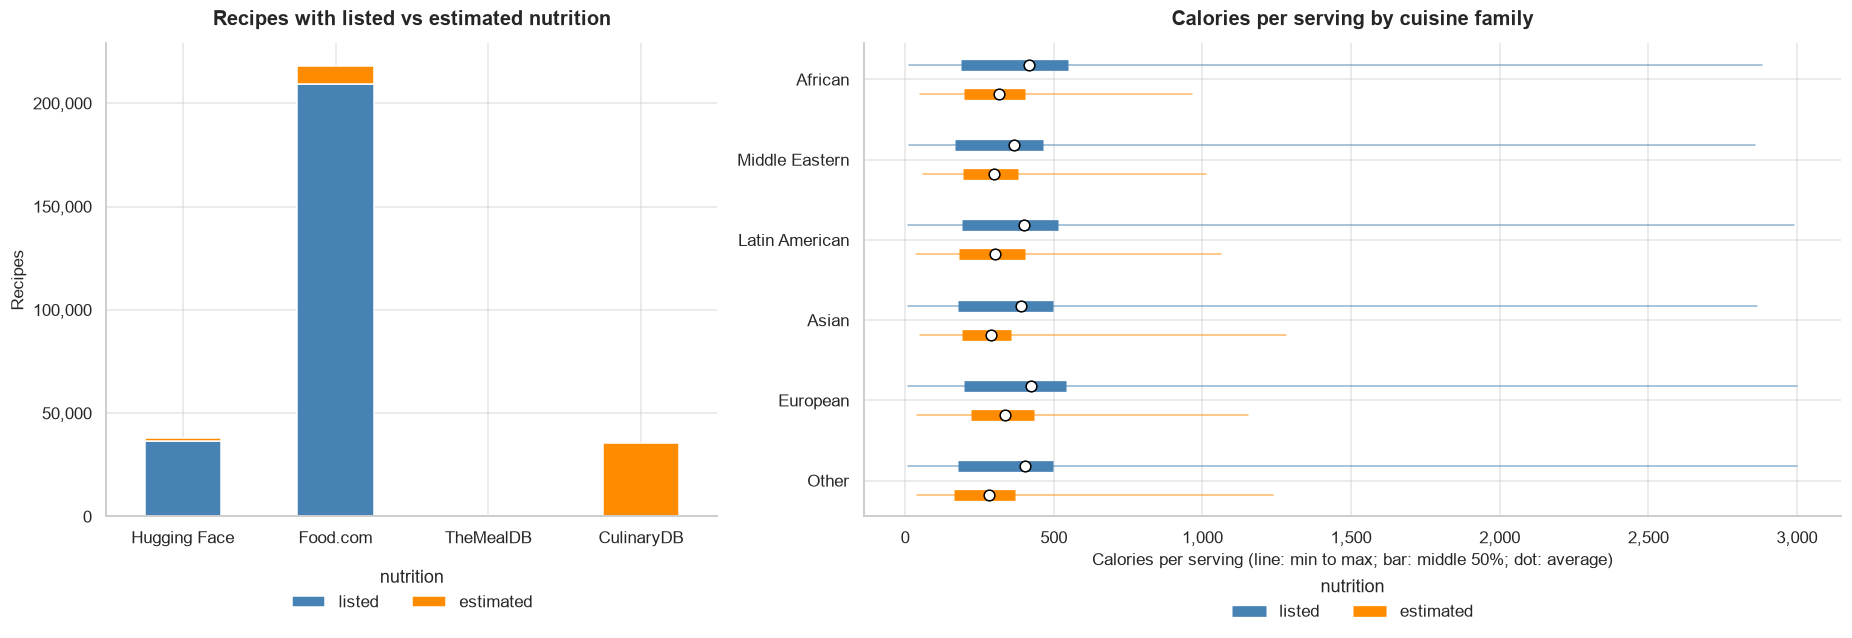

Calories per serving by cuisine family:
                                 recipes  average  minimum  maximum
cuisine_family nutrition_source                                    
African        estimated             625    317.0     51.0    965.0
               listed               2554    415.0     13.0   2884.0
Middle Eastern estimated             913    298.0     60.0   1012.0
               listed               2493    365.0     13.0   2860.0
Latin American estimated            4125    303.0     37.0   1063.0
               listed              11581    400.0     10.0   2991.0
Asian          estimated            6624    289.0     50.0   1281.0
               listed              14164    388.0     10.0   2866.0
European       estimated           12456    337.0     40.0   1155.0
               listed              35694    422.0     11.0   3000.0
Other          estimated           21560    282.0     39.0   1239.0
               listed             178966    404.0     10.0   2999.0

Calorie

In [60]:
NUTRITION_SOURCES = {"listed": "steelblue", "estimated": "darkorange"}

fig, axes = plt.subplots(1, 2, figsize=(17, 6), gridspec_kw={"width_ratios": [1, 1.6]})

# Left: listed vs estimated recipes per source
nutrition_by_source = (pd.crosstab(df_all["source"], df_all["nutrition_source"])
             .reindex(index=[s for s in SOURCE_PRIORITY if s in set(df_all["source"])],
                      columns=list(NUTRITION_SOURCES), fill_value=0))
nutrition_by_source.index = nutrition_by_source.index.map(SOURCE_LABELS)
nutrition_by_source.plot.bar(stacked=True, ax=axes[0], rot=0, color=list(NUTRITION_SOURCES.values()))
axes[0].set_xlabel("")
axes[0].set_ylabel("Recipes")
thousands(axes[0])
axes[0].legend(title="nutrition", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
axes[0].set_title("Recipes with listed vs estimated nutrition")

# Right: min to max, middle 50% and average calories by cuisine family
families = [f for f in FAMILY_ORDER if (df_all["cuisine_family"] == f).any()]
for row, family in enumerate(families):
    for offset, (source, color) in zip((-0.18, 0.18), NUTRITION_SOURCES.items()):
        kcal = df_all.loc[(df_all["cuisine_family"] == family) & (df_all["nutrition_source"] == source),
                          "calories_per_serving"]
        if kcal.empty:
            continue
        y = row + offset
        axes[1].plot([kcal.min(), kcal.max()], [y, y], color=color, lw=1, alpha=0.6)
        axes[1].plot([kcal.quantile(0.25), kcal.quantile(0.75)], [y, y], color=color, lw=7, solid_capstyle="butt",
                     label=source if row == 0 else None)
        axes[1].plot(kcal.mean(), y, "o", color="white", markeredgecolor="black", markersize=7)
axes[1].set_yticks(range(len(families)))
axes[1].set_yticklabels(families)
axes[1].invert_yaxis()
axes[1].set_xlabel("Calories per serving (line: min to max; bar: middle 50%; dot: average)")
axes[1].legend(title="nutrition", loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
thousands(axes[1], "x")
axes[1].set_title("Calories per serving by cuisine family")

show_figure(fig, "16_calories_by_cuisine")

# The same numbers as a table
summary_kcal = (df_all.groupby(["cuisine_family", "nutrition_source"])["calories_per_serving"]
                .agg(recipes="count", average="mean", minimum="min", maximum="max")
                .reindex(families, level=0).round(0))
print("Calories per serving by cuisine family:")
print(summary_kcal.to_string())
print("\nCalories per serving by source:")
print(df_all.groupby(["source", "nutrition_source"])["calories_per_serving"]
      .agg(recipes="count", average="mean", minimum="min", maximum="max").round(0).to_string())

---

## 5.9 Predict Missing Countries of Origin

Section 5.4.6 found a country for the recipes whose source names one. For the others (broad labels such as "asian" or "indian subcontinent", or no label at all) a model predicts the country from the title and the ingredients, the same way the cuisine classifier in 6.6 predicts cuisine families:

- It learns only from **training recipes with a labeled country**, and only countries with at least 100 of them.
- A country that does not belong to the recipe's known cuisine family is ruled out (an "Asian" recipe is never predicted as Italian).
- A prediction is kept only when the model is at least **70% confident**. Otherwise the country stays `Unknown`.

Every recipe gets `origin_source`: `labeled` (from the source), `predicted` (with `origin_confidence`), or `unknown`. Regions are never predicted: `origin_region` comes only from the sources.

Agents should treat predicted countries as a good guess, not a fact: show them as "probably Moroccan", and prefer labeled recipes when origin matters (for example to find authentic dishes from a user's home country).

#### 5.9.1 Train the country model and measure its accuracy

In [61]:
from sklearn.linear_model import LogisticRegression

ORIGIN_MIN_EXAMPLES = 100     # countries with fewer labeled training recipes are not predicted
ORIGIN_MIN_CONFIDENCE = 0.7   # below this, the country stays Unknown

origin_labeled = df_all["origin_country"] != "Unknown"
origin_fit = df_all[origin_labeled & (df_all["split"] == "train")]
country_counts = origin_fit["origin_country"].value_counts()
origin_fit = origin_fit[origin_fit["origin_country"].isin(country_counts[country_counts >= ORIGIN_MIN_EXAMPLES].index)]
origin_check = df_all[origin_labeled & (df_all["split"] == "val")]

# Same kind of text features as 5.8.3 (rarer title words kept, damped counts)
origin_features = TextFeatures(title_min_df=2, title_sublinear_tf=True)


origin_model = LogisticRegression(max_iter=300, C=4.0)
# scikit-learn shows no progress while it trains, so say how long to expect
print("Training the country model (about 2 minutes on a laptop; longer on a busy Colab machine)...")
origin_model.fit(origin_features.fit_transform(origin_fit), origin_fit["origin_country"])
print(f"Country model trained on {len(origin_fit):,} recipes, {len(origin_model.classes_)} countries")

# The cuisine family each country usually belongs to (from its labeled recipes)
COUNTRY_FAMILY = origin_fit.groupby("origin_country")["cuisine_family"].agg(lambda s: s.mode()[0])


def predict_origin(rows):
    """Most likely country for each recipe and the model's confidence (0 to 1).

    Countries from a different cuisine family than the recipe's are ruled out;
    recipes in 'Other' can get any country.
    """
    proba = origin_model.predict_proba(origin_features.transform(rows))
    country_family = COUNTRY_FAMILY.reindex(origin_model.classes_).to_numpy()
    recipe_family = rows["cuisine_family"].to_numpy()
    allowed = (recipe_family[:, None] == country_family[None, :]) | (recipe_family[:, None] == "Other")
    proba = proba * allowed
    proba = proba / np.clip(proba.sum(axis=1, keepdims=True), 1e-12, None)
    return origin_model.classes_[proba.argmax(axis=1)], proba.max(axis=1)


# ---------------------------------------------------------------
# Accuracy on validation recipes whose country we know (hidden from the model)
# ---------------------------------------------------------------
check_country, check_confidence = predict_origin(origin_check)
check_true = origin_check["origin_country"].to_numpy()
check_correct = check_country == check_true
print(f"\nValidation recipes with a labeled country: {len(origin_check):,}")
print(f"Correct country (top guess, no threshold): {check_correct.mean() * 100:.1f}%")

THRESHOLDS = np.round(np.arange(0.3, 0.96, 0.05), 2)
origin_threshold_table = pd.DataFrame({
    "kept (%)"   : [(check_confidence >= t).mean() * 100 for t in THRESHOLDS],
    "correct (%)": [check_correct[check_confidence >= t].mean() * 100 for t in THRESHOLDS],
}, index=pd.Index(THRESHOLDS, name="confidence at least")).round(1)
print("\nHow the confidence threshold trades coverage for accuracy:")
print(origin_threshold_table.loc[[0.5, 0.6, 0.7, 0.8, 0.9]].to_string())

kept = check_confidence >= ORIGIN_MIN_CONFIDENCE
per_country = (pd.DataFrame({"country": check_country[kept], "correct": check_correct[kept]})
               .groupby("country")["correct"].agg(predicted="size", correct_pct="mean"))
per_country["correct_pct"] = (per_country["correct_pct"] * 100).round(0)
print(f"\nAt {ORIGIN_MIN_CONFIDENCE:.0%} confidence, by predicted country (15 most common):")
print(per_country.sort_values("predicted", ascending=False).head(15).to_string())

Training the country model (about 2 minutes on a laptop; longer on a busy Colab machine)...


Country model trained on 83,774 recipes, 37 countries



Validation recipes with a labeled country: 18,136
Correct country (top guess, no threshold): 81.0%

How the confidence threshold trades coverage for accuracy:
                     kept (%)  correct (%)
confidence at least                       
0.5                      89.7         85.4
0.6                      83.2         87.6
0.7                      75.7         89.4
0.8                      66.1         91.3
0.9                      51.2         93.3

At 70% confidence, by predicted country (15 most common):
                predicted  correct_pct
country                               
United States        5992         95.0
Italy                2353         87.0
Mexico               1664         79.0
France                743         81.0
India                 482         91.0
China                 454         84.0
Greece                362         90.0
United Kingdom        290         82.0
Thailand              211         89.0
Japan                 190         87.0
Spain       

#### 5.9.2 Fill in the countries

In [62]:
df_all["origin_source"] = np.where(df_all["origin_country"] != "Unknown", "labeled", "unknown")
df_all["origin_confidence"] = np.nan

to_predict = df_all[df_all["origin_source"] == "unknown"]
predicted_country, predicted_confidence = predict_origin(to_predict)
confident = predicted_confidence >= ORIGIN_MIN_CONFIDENCE
filled = to_predict.index[confident]
df_all.loc[filled, "origin_country"] = predicted_country[confident]
df_all.loc[filled, "origin_source"] = "predicted"
df_all.loc[filled, "origin_confidence"] = predicted_confidence[confident].round(3)

# The splits are separate tables: rebuild them so they include the countries
train_df, val_df, test_df = split_tables(df_all)

print("Country of origin by recipe source:")
print(by_source(df_all, "origin_source").to_string())
print(f"\nRecipes with a region named by their source: {df_all['origin_region'].notna().sum():,}")
print(df_all["origin_region"].value_counts().head(10).to_string())

Country of origin by recipe source:
origin_source  labeled  predicted  unknown   total
source                                            
CulinaryDB       26759       5751     2815   35325
Food.com         65622      98950    53452  218024
Hugging Face     28486       4558     4779   37823
TheMealDB          583          0        0     583
total           121450     109259    61046  291755

Recipes with a region named by their source: 14,770
origin_region
Southern US          4322
Midwestern US        2440
Northeastern US      1621
Southwestern US      1611
England              1274
Ontario               631
British Columbia      542
Pacific Northwest     506
California            443
Scotland              386


#### 5.9.3 Chart: countries of origin

> **What it shows:** Left: the 20 most common countries, split into labeled (from the source) and predicted. Right: on validation recipes, how the confidence threshold trades the share of recipes that get a country (coverage) against how often that country is right; the dashed line is the threshold used.

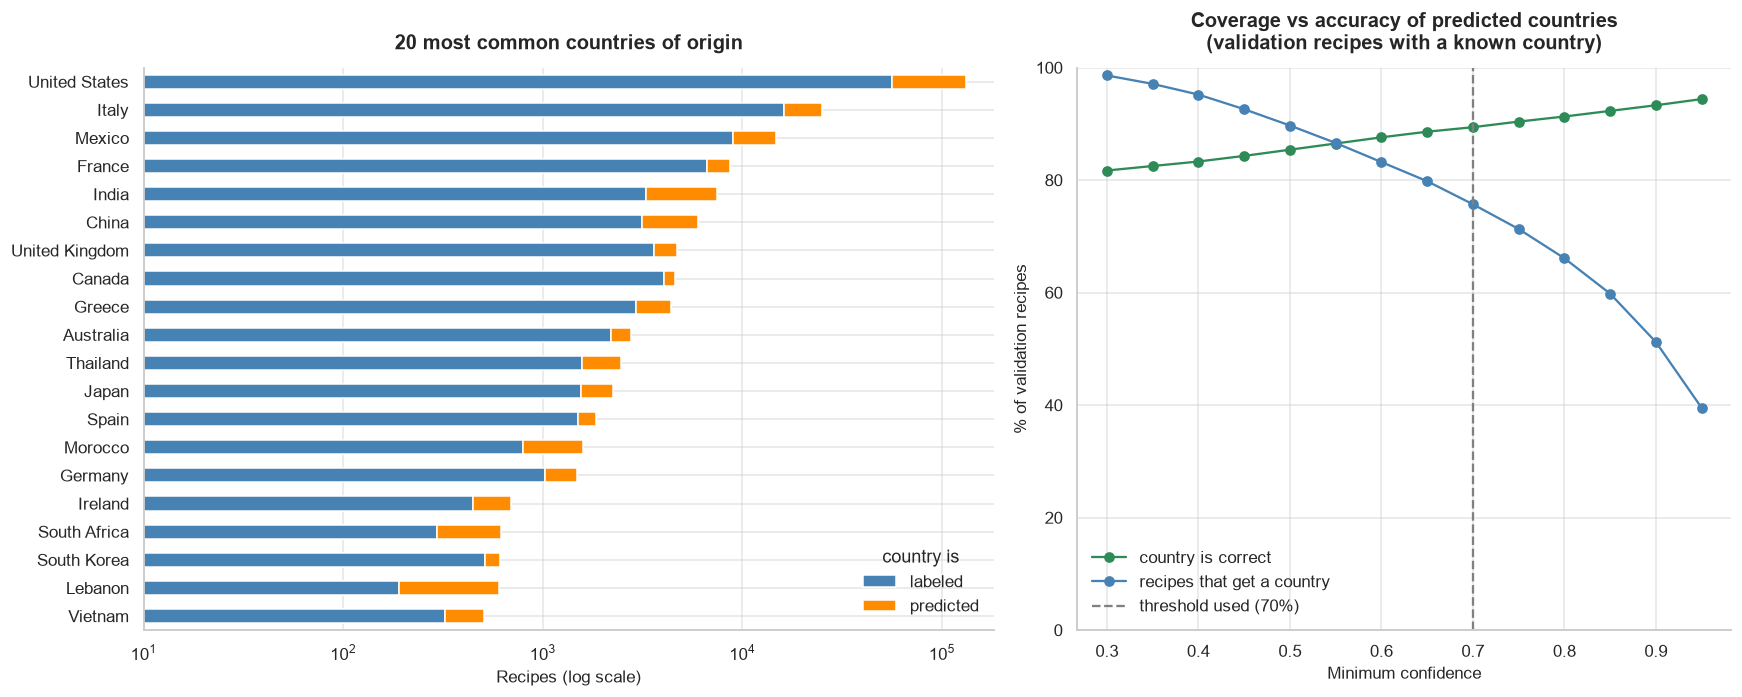

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), gridspec_kw={"width_ratios": [1.3, 1]})

known_origin = df_all[df_all["origin_source"] != "unknown"]
top_countries = known_origin["origin_country"].value_counts().head(20).index
by_country = (pd.crosstab(known_origin["origin_country"], known_origin["origin_source"])
              .reindex(index=top_countries, columns=["labeled", "predicted"], fill_value=0))
by_country.plot.barh(stacked=True, ax=axes[0], color=["steelblue", "darkorange"])
axes[0].invert_yaxis()
axes[0].set_xscale("log")   # the United States is far larger than the rest
axes[0].set_xlim(left=10)   # so small labeled bars stay visible
axes[0].set_xlabel("Recipes (log scale)")
axes[0].set_ylabel("")
axes[0].legend(title="country is", loc="lower right")
axes[0].set_title("20 most common countries of origin")

axes[1].plot(origin_threshold_table.index, origin_threshold_table["correct (%)"], marker="o",
             color="seagreen", label="country is correct")
axes[1].plot(origin_threshold_table.index, origin_threshold_table["kept (%)"], marker="o",
             color="steelblue", label="recipes that get a country")
axes[1].axvline(ORIGIN_MIN_CONFIDENCE, ls="--", color="gray", label=f"threshold used ({ORIGIN_MIN_CONFIDENCE:.0%})")
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("Minimum confidence")
axes[1].set_ylabel("% of validation recipes")
axes[1].legend(loc="lower left")
axes[1].set_title("Coverage vs accuracy of predicted countries\n(validation recipes with a known country)")

show_figure(fig, "19_origin_countries")

---

## 5.10 Data Validation

Before saving, automatic checks confirm that the data follows the rules the agents and models rely on: the right columns and types, only allowed values, believable ranges, consistent flags, and no recipe or ingredient group in two splits. If any check fails, the cell stops with a list of the problems, so bad data is never saved.

In [64]:
# The rules are in src/everflavor/pipeline.py (validate_recipes); each returns pass or FAIL
from everflavor.pipeline import validate_recipes

results = validate_recipes(df_all, origin_min_confidence=ORIGIN_MIN_CONFIDENCE)
for rule, passed in results.items():
    print(f"  [{'pass' if passed else 'FAIL'}] {rule}")
failed = [rule for rule, passed in results.items() if not passed]
if failed:
    raise ValueError(f"Data validation failed: {failed}")
print(f"\nAll {len(results)} checks passed.")

  [pass] recipe_id is unique
  [pass] every recipe has a name
  [pass] cuisine_family has only allowed values
  [pass] source has only allowed values
  [pass] every recipe has at least 2 ingredients
  [pass] flags are true/false only
  [pass] calories between 0 and 3,000 kcal
  [pass] servings between 1 and 50
  [pass] plausible nutrition only where data exists
  [pass] every recipe has calories (listed or estimated)
  [pass] estimates only where listed data was missing or unbelievable
  [pass] every estimate lies inside its likely range
  [pass] vegan recipes are also vegetarian
  [pass] recipes with meat are not vegetarian
  [pass] red meat and poultry also count as meat
  [pass] crustaceans and molluscs also count as shellfish
  [pass] scaleless fish also count as fish
  [pass] unclean meat also counts as meat
  [pass] no pet meat and no recipes made for pets
  [pass] every diet column follows its rule (5.4.7)
  [pass] nutrition diets only with listed nutrition
  [pass] origin_sourc

---

## 5.11 Save the Processed Data

The combined table and the three splits are saved as Parquet files, which keep list columns and true/false flags intact. A text editor cannot open them; load them with `pd.read_parquet()` or the Data Wrangler extension in VS Code.

We also save a **dataset record** (`data/processed/dataset_info.json`): the source versions, library versions, random seed, filter settings and row counts used for this run, so results can be reproduced and described in the report.

In [65]:
# Save as Parquet: smaller and faster than CSV, and it keeps
# list columns (ingredient_list) and true/false flags intact.
SPLIT_FILES = {
    "train": "data/processed/recipes_train.parquet",
    "val"  : "data/processed/recipes_val.parquet",
    "test" : "data/processed/recipes_test.parquet",
}
ALL_RECIPES_FILE = "data/interim/recipes_all.parquet"

train_df.to_parquet(SPLIT_FILES["train"], index=False)
val_df.to_parquet(SPLIT_FILES["val"], index=False)
test_df.to_parquet(SPLIT_FILES["test"], index=False)
df_all.to_parquet(ALL_RECIPES_FILE, index=False)

print("Files saved:")
for file_path in [*SPLIT_FILES.values(), ALL_RECIPES_FILE]:
    print(f"  {file_path:42s} {os.path.getsize(file_path) / 1e6:6.1f} MB")

# ------------------------------------------------------------------
# Dataset record: what went into this run
# ------------------------------------------------------------------
import datetime
import platform

from everflavor.reporting import hf_revision, package_version, to_json

dataset_info = {
    "created": datetime.datetime.now().astimezone().date().isoformat(),
    "random_seed": 42,
    "python": platform.python_version(),
    "libraries": {p: package_version(p) for p in ["pandas", "numpy", "scikit-learn", "pyarrow", "datasets", "kagglehub"]},
    "sources": {
        "foodcom": {"kaggle_dataset": "shuyangli94/food-com-recipes-and-user-interactions",
                    "version": Path(path).name if "path" in globals() else None},
        "huggingface": {"dataset": "datahiveai/recipes-with-nutrition",
                        "revision": hf_revision("datahiveai/recipes-with-nutrition")},
        "culinarydb": {"url": "https://cosylab.iiitd.edu.in/culinarydb/static/data/CulinaryDB.zip"},
        "themealdb": {"url": "https://www.themealdb.com/api/json/v1/1/search.php"},
    },
    "settings": {"MAX_KCAL_PER_SERVING": MAX_KCAL_PER_SERVING, "MAX_SERVINGS": MAX_SERVINGS,
                 "NUTRITION_LIMITS": NUTRITION_LIMITS, "MACRO_TOLERANCE": MACRO_TOLERANCE,
                 "split": "70/15/15 by ingredient group, stratified by cuisine family"},
    "rows": {"all": len(df_all), "train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "rows_by_source": df_all["source"].value_counts().to_dict(),
    "rows_by_cuisine": df_all["cuisine_family"].value_counts().to_dict(),
    "recipes_with_plausible_nutrition": int(df_all["nutrition_plausible"].sum()),
    "nutrition_source": df_all["nutrition_source"].value_counts().to_dict(),
    "origin_source": df_all["origin_source"].value_counts().to_dict(),
    "origin_model": {"min_examples": ORIGIN_MIN_EXAMPLES, "min_confidence": ORIGIN_MIN_CONFIDENCE,
                     "countries": len(origin_model.classes_),
                     "validation_correct_pct_at_threshold": float(origin_threshold_table.loc[ORIGIN_MIN_CONFIDENCE, "correct (%)"]),
                     "validation_kept_pct_at_threshold": float(origin_threshold_table.loc[ORIGIN_MIN_CONFIDENCE, "kept (%)"])},
    "diet_profiles": {d: int(df_all[d].sum()) for d in DIET_COLUMNS},
    "nutrition_estimates": {
        "usda_downloads": {name: url for name, (url, _) in USDA_DOWNLOADS.items()},
        "likely_range_factors": [round(float(np.exp(range_low)), 3), round(float(np.exp(range_high)), 3)],
        "validation_accuracy": estimate_accuracy.to_dict(orient="index"),
    },
}
DATASET_INFO_FILE = "data/processed/dataset_info.json"

with open(DATASET_INFO_FILE, "w", encoding="utf-8") as f:
    json.dump(dataset_info, f, indent=2, default=to_json)
print(f"\nDataset record saved to {DATASET_INFO_FILE}")
print(json.dumps({k: dataset_info[k] for k in ["created", "sources", "rows"]}, indent=2, default=to_json))

Files saved:
  data/processed/recipes_train.parquet         64.3 MB
  data/processed/recipes_val.parquet           14.4 MB
  data/processed/recipes_test.parquet          14.3 MB
  data/interim/recipes_all.parquet             91.4 MB



Dataset record saved to data/processed/dataset_info.json
{
  "created": "2026-10-04",
  "sources": {
    "foodcom": {
      "kaggle_dataset": "shuyangli94/food-com-recipes-and-user-interactions",
      "version": "2"
    },
    "huggingface": {
      "dataset": "datahiveai/recipes-with-nutrition",
      "revision": "33ff70ba3dc1a1a77395fc477934b4ffb18a347d"
    },
    "culinarydb": {
      "url": "https://cosylab.iiitd.edu.in/culinarydb/static/data/CulinaryDB.zip"
    },
    "themealdb": {
      "url": "https://www.themealdb.com/api/json/v1/1/search.php"
    }
  },
  "rows": {
    "all": 291755,
    "train": 204114,
    "val": 43816,
    "test": 43825
  }
}


---

## 5.12 Hand-Check Sample for Restriction Flags

Our restriction flags mostly agree with Food.com's own dietary tags (5.4.2), but those tags can be wrong too. The safety filter must catch **every** recipe that breaks a restriction, so we check blind samples by hand:

1. The cell below saves 200 random recipes per round (50 per source) to `docs/flag_review/flag_review_sample_round<N>.csv`. Our flag values are **not** in the file, so reviewers are not influenced by them, and no recipe appears in two rounds.
2. A reviewer saves a copy as `flag_review_labeled_round<N>.csv`, reads each recipe's ingredients and name, and fills each flag column with `1` (contains it / is vegetarian / is vegan), `0`, or leaves it blank when the answer depends on the brand.
3. Run the cell again. It compares our flags with the answers and saves every disagreement to `flag_review_disagreements_round<N>.csv`, so a teammate can spot-check just those rows (see `docs/flag_review/HOW_TO_SPOT_CHECK.md`). **Recall** is the share of recipes that really contain something that we also flagged. It matters most, because a missed allergen is worse than an extra exclusion.

**Rounds so far:** round 1 found that gluten was caught only 81% of the time, mostly because wheat is hidden in product names (crackers, pastry, spaghetti, buns). The keyword lists in 5.4.2 were extended using those examples, so round 1 now gives optimistic numbers. Round 2 is a fresh sample that measured the improved flags. Round 3's disagreements were traced one by one in 5.13 and fixed (for example jamón, "frozen seafood mix", "portobello steak"), so round 3 is now optimistic too, and **round 4** is the fresh sample for the next measurement. How the labels were made is described in `docs/flag_review/labeling_notes.md`.

Samples are only written once, so reviewers' work is never overwritten. The `docs/` folder is committed, so the team can share labeled files through GitHub.

In [66]:
from everflavor.review import (
    labeled_file,
    make_review_samples,
    save_disagreements,
    score_flags,
)

REVIEW_DIR = Path("docs/flag_review")
# Each round is a separate blind sample (no recipe appears twice). Rounds 1 and 2
# were used to improve the keyword lists in 5.4.2, so only the latest round
# measures the current lists fairly.
REVIEW_ROUNDS = {1: 42, 2: 7, 3: 11, 4: 23}   # round -> random seed

# 1. Blind samples for reviewers (each written once, never overwritten)
make_review_samples(df_all, REVIEW_ROUNDS, FLAG_COLUMNS, folder=REVIEW_DIR)

# 2. Score our flags against every round that has been labeled
flag_scores = {}
for round_no in REVIEW_ROUNDS:
    if labeled_file(round_no, REVIEW_DIR).exists():
        flag_scores[round_no], disagreements = score_flags(labeled_file(round_no, REVIEW_DIR), df_all, FLAG_COLUMNS)
        # Disagreements to spot-check: kept if a reviewer has started filling in team_check
        disagree_file = save_disagreements(disagreements, round_no, REVIEW_DIR)
        note = " (used to improve the keywords, so optimistic)" if round_no < max(REVIEW_ROUNDS) else ""
        print(f"\nRound {round_no}: flag accuracy against the labeled sample{note}:")
        print(flag_scores[round_no].to_string())
        print(f"{len(disagreements)} disagreements to spot-check: {disagree_file}")
    else:
        print(f"\nRound {round_no}: no labeled file yet. Fill in a copy named {labeled_file(round_no, REVIEW_DIR).name}.")

if flag_scores:
    latest = max(flag_scores)
    low = flag_scores[latest][flag_scores[latest]["recall"] < 0.95].index.tolist()
    print(f"\nFlags with recall below 0.95 in round {latest} (extend their keyword lists in 5.4.2): {low or 'none'}")

Round 1 sample already exists: docs\flag_review\flag_review_sample_round1.csv
Round 2 sample already exists: docs\flag_review\flag_review_sample_round2.csv
Round 3 sample already exists: docs\flag_review\flag_review_sample_round3.csv
Round 4 sample already exists: docs\flag_review\flag_review_sample_round4.csv

Round 1: flag accuracy against the labeled sample (used to improve the keywords, so optimistic):
                    reviewed  positives  recall  precision
flag                                                      
contains_pork            197         32   1.000      1.000
contains_alcohol         199         30   1.000      0.968
contains_gluten          193         94   0.989      0.949
contains_dairy           197        100   1.000      0.990
contains_egg             199         63   0.984      1.000
contains_peanut          200          4   1.000      1.000
contains_tree_nut        200         20   1.000      1.000
contains_fish            200         19   1.000      0.905



Round 2: flag accuracy against the labeled sample (used to improve the keywords, so optimistic):
                    reviewed  positives  recall  precision
flag                                                      
contains_pork            197         18   1.000      0.947
contains_alcohol         200         21   1.000      0.913
contains_gluten          197         96   1.000      0.970
contains_dairy           199        112   0.991      0.982
contains_egg             199         52   0.981      1.000
contains_peanut          200          5   1.000      1.000
contains_tree_nut        200         21   1.000      1.000
contains_fish            200         23   1.000      0.885
contains_shellfish       199          6   1.000      0.750
contains_soy             197         11   0.909      0.625
contains_sesame          200          6   1.000      0.857
not vegetarian           199         93   1.000      0.979
not vegan                199        170   0.994      0.988
28 disagreements 


Round 4: flag accuracy against the labeled sample:
                            reviewed  positives  recall  precision
flag                                                              
contains_pork                    200         20   1.000      1.000
contains_alcohol                 200         22   1.000      0.917
contains_gluten                  200        104   0.942      0.933
contains_dairy                   200        112   0.946      0.972
contains_egg                     200         52   1.000      1.000
contains_peanut                  200          6   1.000      0.750
contains_tree_nut                200         19   1.000      0.864
contains_fish                    200         14   1.000      0.875
contains_shellfish               200          9   1.000      1.000
contains_crustacean              200          8   1.000      1.000
contains_mollusc                 200          3   1.000      0.750
contains_soy                     200         14   1.000      0.583
contains_s

---

## 5.13 Human Verification of the Flags

The flags come from keyword rules, and the answers in the 5.12 review files were labeled by an AI (`docs/flag_review/labeling_notes.md`). An AI checking an AI is not independent, so **a person has the final say**. This section gathers the evidence automatically, so reviewers only make decisions, and it records those decisions in files that are committed with the project:

| Step | What the pipeline does | What a person does | File |
|---|---|---|---|
| 5.13.1 Policies | Lists the rules that are a matter of definition (do oats count as gluten?) | Approves or changes each one, once | `docs/flag_review/flag_policies.csv` |
| 5.13.2 Ready-made ingredients | Looks up products such as "ranch dressing" on Open Food Facts and finds allergens our keywords miss | Approves or rejects each suggestion | `docs/flag_review/compound_ingredients_review.csv` |
| 5.13.3 Disagreements and sign-off | Shows each disagreement with the keyword that set the flag | Writes who is right in `team_check`, then signs off the round | `flag_review_disagreements_round<N>.csv`, `human_signoff.csv` |

Nothing here can silently change a flag: the code only adds a flag when the evidence or a decision supports it, and the checks below report any mismatch between the decisions and the code. The completion checklist ticks "signed off by a person" only when `human_signoff.csv` has a row for the latest labeled round. Step-by-step instructions are in `docs/flag_review/HOW_TO_SPOT_CHECK.md`.

#### 5.13.1 Policy decisions

Some flags depend on a definition rather than a fact. Each such question has one row with the decision, the reason and its source. Rows marked `proposed` still need a person to confirm them: write `approved` (or change the decision), your name and the date.

In [67]:
POLICY_FILE = REVIEW_DIR / "flag_policies.csv"
policies = pd.read_csv(POLICY_FILE).fillna("")
with pd.option_context("display.max_colwidth", 70, "display.width", 200):
    print(policies[["policy_id", "question", "decision", "status", "decided_by"]].to_string(index=False))
open_policies = policies.loc[policies["status"] != "approved", "policy_id"].tolist()
print(f"\n{len(policies) - len(open_policies)} of {len(policies)} policies approved by a person; "
      f"waiting for a decision: {', '.join(open_policies) or 'none'}")

policy_id                                                                                     question                                                                                                                                                                                                            decision   status  decided_by
       P1                                                                     Do oats count as gluten?                                                                                                                                                                                     Yes, unless labeled gluten-free approved med27-coder
       P2                                     Does gelatin (Jell-O, marshmallows) rule out vegetarian?                                                                                                                                                                                         Yes: gelatin counts as meat approved med2

#### 5.13.2 Ready-made ingredients: allergens hidden inside products

A recipe that lists "ranch dressing" or "chocolate chips" does not list the milk or egg inside them, so the keyword rules cannot see it. For every ready-made ingredient (last word such as dressing, sauce, mix, chips, pudding) used in at least 100 recipes, this cell looks up products with that name on **Open Food Facts** and counts how many **declare** each allergen on their label. An allergen is suggested when at least 60% of at least 5 matching products declare it, and our rules do not flag it yet.

Suggestions go into `COMPOUND_INGREDIENTS` in `src/everflavor/flags.py`, which only ever **adds** flags (the safe direction), and stay marked as waiting for review until a person writes `approve` or `reject` in `team_decision`. The searches are slow (about 6.5 seconds each, to respect Open Food Facts' rate limit), so the results are saved in the evidence file and only new or failed ingredients are searched on later runs.

In [68]:
from everflavor.flags import COMPOUND_INGREDIENTS
from everflavor.review import EVIDENCE_PAGE_SIZE, compound_candidates, compound_evidence
from everflavor.sources import cached_off_search

EVIDENCE_FILE = REVIEW_DIR / "compound_ingredients_review.csv"
OFF_ALLERGEN_CACHE = Path("data/raw/off_allergen_cache")

# Candidates: frequent ready-made ingredients, plus any entry added to COMPOUND_INGREDIENTS by hand
candidates = compound_candidates(df_all)
ingredient_counts = df_all["ingredient_list"].explode().value_counts()
by_hand = [name for name in COMPOUND_INGREDIENTS if name not in set(candidates["ingredient"])]
candidates = pd.concat([candidates, pd.DataFrame({"ingredient": by_hand,
                                                  "recipes": [int(ingredient_counts.get(n, 0)) for n in by_hand]})],
                       ignore_index=True)

# Keep the team's decisions always; REFRESH_DOWNLOADS (set in 2.3) searches everything again
previous = pd.read_csv(EVIDENCE_FILE).fillna("") if EVIDENCE_FILE.exists() else None
if previous is not None and REFRESH_DOWNLOADS:
    previous["products"] = -1
to_search = len(candidates) if previous is None else int((~candidates["ingredient"].isin(
    previous.loc[previous["products"].astype(int) >= 0, "ingredient"])).sum())
if to_search:
    print(f"Searching Open Food Facts for {to_search} ingredients (about {to_search * 6.5 / 60:.0f} min) ...")


def off_products(query):
    # Products for one search, saved under data/raw/off_allergen_cache/
    return cached_off_search(query, OFF_ALLERGEN_CACHE, refresh=REFRESH_DOWNLOADS, page_size=EVIDENCE_PAGE_SIZE)[0]


evidence = compound_evidence(candidates, off_products, previous)
evidence.to_csv(EVIDENCE_FILE, index=False)

decision = evidence["team_decision"].astype(str).str.strip().str.lower()
suggested = evidence[evidence["suggested_flags"] != ""]
print(f"{len(evidence)} ready-made ingredients checked ({(evidence['products'] < 0).sum()} searches failed; "
      f"run the cell again to retry them)")
print(f"{len(suggested)} have allergens that Open Food Facts products declare but our rules miss:\n")
with pd.option_context("display.max_colwidth", 60, "display.width", 200):
    print(suggested[["ingredient", "recipes", "products", "rule_flags", "suggested_flags", "team_decision"]]
          .to_string(index=False))

# The code must match the evidence and the decisions
in_code = {name: set(flags) for name, flags in COMPOUND_INGREDIENTS.items()}
missing = [r.ingredient for r in suggested.itertuples()
           if decision[r.Index] != "reject" and not set(r.suggested_flags.split()) <= in_code.get(r.ingredient, set())]
rejected = [name for name in in_code if name in set(evidence.loc[decision == "reject", "ingredient"])]
waiting = [name for name in in_code if name not in set(evidence.loc[decision == "approve", "ingredient"])]
COMPOUND_RULES_MATCH = not missing and not rejected
print(f"\nIn COMPOUND_INGREDIENTS: {len(in_code)}  |  waiting for a person to approve: {len(waiting)}")
print(f"Suggested but not in the code yet: {missing or 'none'}")
print(f"Rejected by the team but still in the code: {rejected or 'none'}")

Checking ready-made ingredients:   0%|          | 0/291 [00:00<?, ?it/s]

291 ready-made ingredients checked (0 searches failed; run the cell again to retry them)
52 have allergens that Open Food Facts products declare but our rules miss:

                      ingredient  recipes  products                     rule_flags                             suggested_flags team_decision
            worcestershire sauce     8922        10                                              contains_fish contains_gluten       approve
       semi-sweet chocolate chip     2439        19                                                contains_dairy contains_soy       approve
                  chocolate chip     2293         8                                               contains_gluten contains_soy        reject
                 spaghetti sauce     1123        10                                                            contains_gluten        reject
             semisweet chocolate     1050        19                                                               contains_soy   

#### 5.13.3 Disagreements and sign-off

For each labeled round, the table shows how many disagreements a person has checked. `why_flagged` in each disagreements file names the keyword that set the flag, or says the flag came from the raw ingredient text or a Hugging Face label. To check a round: write `pipeline` or `answer` in `team_check` for each row, fix the rules or the policy file if needed, then add one row to `human_signoff.csv` (round, your name, the date, how many rows you checked, notes).

In [69]:
from everflavor.review import disagreement_file

SIGNOFF_FILE = REVIEW_DIR / "human_signoff.csv"
signoff = pd.read_csv(SIGNOFF_FILE)
review_status = []
for round_no in REVIEW_ROUNDS:
    path = disagreement_file(round_no, REVIEW_DIR)
    if not path.exists():
        continue
    rows = pd.read_csv(path)
    check = rows["team_check"].fillna("").astype(str).str.strip().str.lower()
    review_status.append({
        "round": round_no, "disagreements": len(rows), "checked by a person": int((check != "").sum()),
        "pipeline right": int((check == "pipeline").sum()), "answer right": int((check == "answer").sum()),
        "signed off by": ", ".join(signoff.loc[signoff["round"] == round_no, "reviewer"].astype(str)) or "-",
    })
review_status = pd.DataFrame(review_status)
print(review_status.to_string(index=False))

latest_round = int(review_status["round"].max())
HUMAN_SIGNED_OFF = bool((signoff["round"] == latest_round).any())
print(f"\nLatest labeled round: {latest_round}. Signed off by a person: {'yes' if HUMAN_SIGNED_OFF else 'NOT YET'}")

latest = pd.read_csv(disagreement_file(latest_round, REVIEW_DIR))
print(f"\nRound {latest_round} disagreements left after the fixes, with what set each flag:")
with pd.option_context("display.max_colwidth", 55, "display.width", 220):
    print(latest[["recipe_name", "flag", "answer", "pipeline_flag", "why_flagged", "team_check"]]
          .fillna("").to_string(index=False))

 round  disagreements  checked by a person  pipeline right  answer right signed off by
     1             17                    0               0             0             -
     2             28                    0               0             0             -
     3             27                    0               0             0     Evaabou20
     4            143                    0               0             0             -

Latest labeled round: 4. Signed off by a person: NOT YET

Round 4 disagreements left after the fixes, with what set each flag:
                                                                              recipe_name                     flag  answer  pipeline_flag                                                                          why_flagged team_check
                                                Whole Seabass with Fennel and Orange Zest         contains_alcohol       0              1                                                                  

---

# WEEK 6 - EXPLORATORY DATA ANALYSIS

In this section we analyze the preprocessed datasets to uncover patterns, identify gaps, and derive insights that will shape how we build the three EverFlavor agents. We also build a simple baseline model that the agents can rely on before more sophisticated approaches are developed.

---

## 6.0 Setup

The training split from 5.11 (the chart style comes from 2.3.3) (reloaded from file after a kernel restart).

In [70]:
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

# The chart style and show_figure() come from section 2.3.3
# The setup cell in 2.3 moves to the project folder; without it,
# the data/ paths below point to the wrong place after a restart.
if "PROJECT_ROOT" not in globals():
    raise RuntimeError("Run the setup cell in section 2.3 first (it is needed after every kernel restart).")

# Load the processed training split if not already in memory
try:
    _ = train_df
    print("Training dataframe already in memory.")
except NameError:
    train_df = pd.read_parquet("data/processed/recipes_train.parquet")
    print("Loaded training data from file.")

print(f"Training set shape: {train_df.shape}")

Training dataframe already in memory.
Training set shape: (204114, 95)


---

## 6.1 Statistical Analysis

### 6.1.1 Calorie Distribution

#### 6.1.1.1 Charts: calories per serving

> **What it shows:** The spread of listed (real) calories across the training recipes, and how it differs by cuisine family.

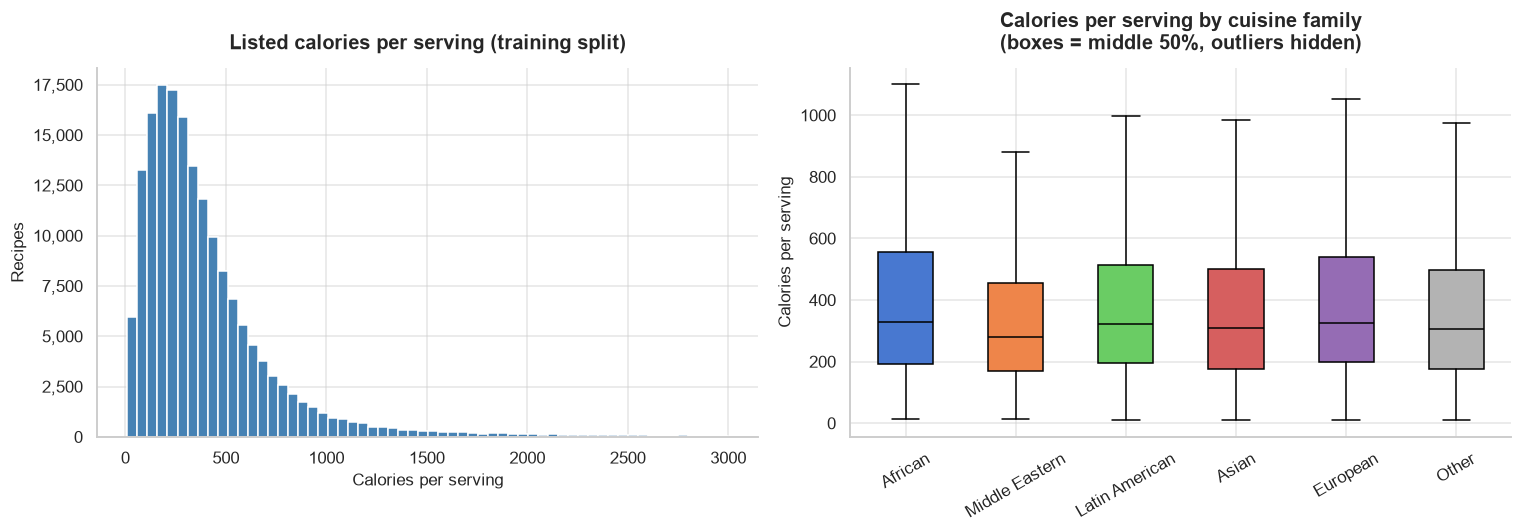

In [71]:
# Real (listed) calories only: the estimates from 5.8 are summarized there
listed = train_df[train_df["nutrition_plausible"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram of calories per serving (full training set)
axes[0].hist(listed["calories_per_serving"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Calories per serving")
axes[0].set_ylabel("Recipes")
thousands(axes[0])
axes[0].set_title("Listed calories per serving (training split)")

# Right: Box plot of calories by cuisine family
# (families with no recipes, such as African here, are left out)
families = [f for f in FAMILY_ORDER if (listed["cuisine_family"] == f).any()]
data_by_family = [
    listed[listed["cuisine_family"] == f]["calories_per_serving"].values
    for f in families
]
boxes = axes[1].boxplot(data_by_family, patch_artist=True, showfliers=False,
                        medianprops={"color": "black"})
for box, family in zip(boxes["boxes"], families):
    box.set_facecolor(FAMILY_COLORS[family])
axes[1].set_xticks(range(1, len(families) + 1))
axes[1].set_xticklabels(families, rotation=30)
axes[1].set_ylabel("Calories per serving")
axes[1].set_title("Calories per serving by cuisine family\n(boxes = middle 50%, outliers hidden)")

show_figure(fig, "11_calories_per_serving")

#### 6.1.1.2 Calorie statistics by cuisine family

In [72]:
# Numeric summary of calories by cuisine family
print("Listed calorie statistics by cuisine family (training set):")
print(
    train_df[train_df["nutrition_plausible"]].groupby("cuisine_family")["calories_per_serving"]
    .agg(["count", "mean", "median", "std"])
    .round(1)
    .to_string()
)

Listed calorie statistics by cuisine family (training set):
                 count   mean  median    std
cuisine_family                              
African           1786  417.7   329.0  334.5
Asian             9886  385.6   308.1  314.6
European         24980  421.4   324.0  346.9
Latin American    8151  403.9   321.5  327.6
Middle Eastern    1762  364.2   279.2  306.2
Other           125139  402.8   305.0  371.0


---

### 6.1.2 Cuisine Coverage

> **What it shows:** How many training recipes each cuisine family has. African and Middle Eastern are much smaller than the others.

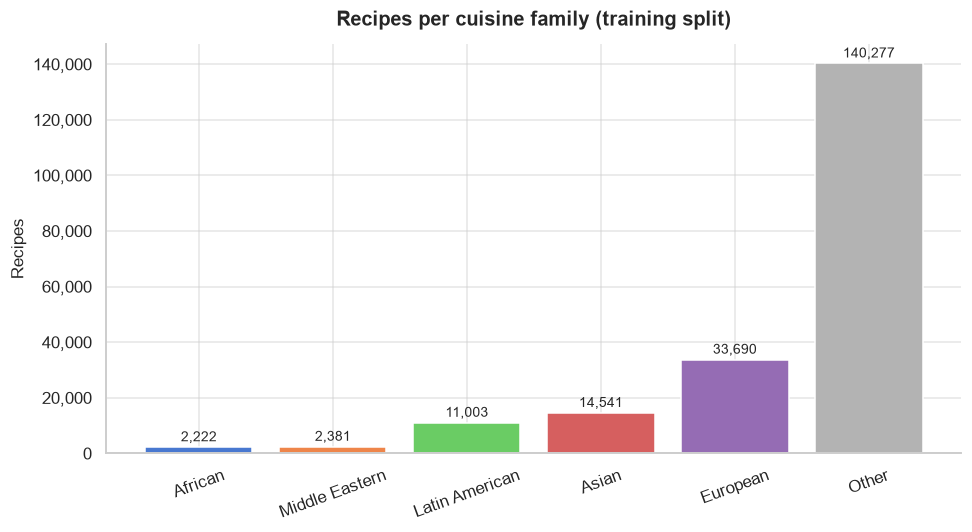


Cuisine counts:
cuisine_family
African             2222
Middle Eastern      2381
Latin American     11003
Asian              14541
European           33690
Other             140277


In [73]:
cuisine_counts = train_df["cuisine_family"].value_counts().reindex(FAMILY_ORDER).dropna()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cuisine_counts.index, cuisine_counts.values,
       color=[FAMILY_COLORS[f] for f in cuisine_counts.index])
label_bars(ax)
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title("Recipes per cuisine family (training split)")
ax.tick_params(axis="x", rotation=20)
show_figure(fig, "12_cuisine_coverage")

print("\nCuisine counts:")
print(cuisine_counts.to_string())

---

### 6.1.3 Most Frequent Ingredients (All Sources)

> **What it shows:** The 20 most used ingredients across all sources, after normalizing.

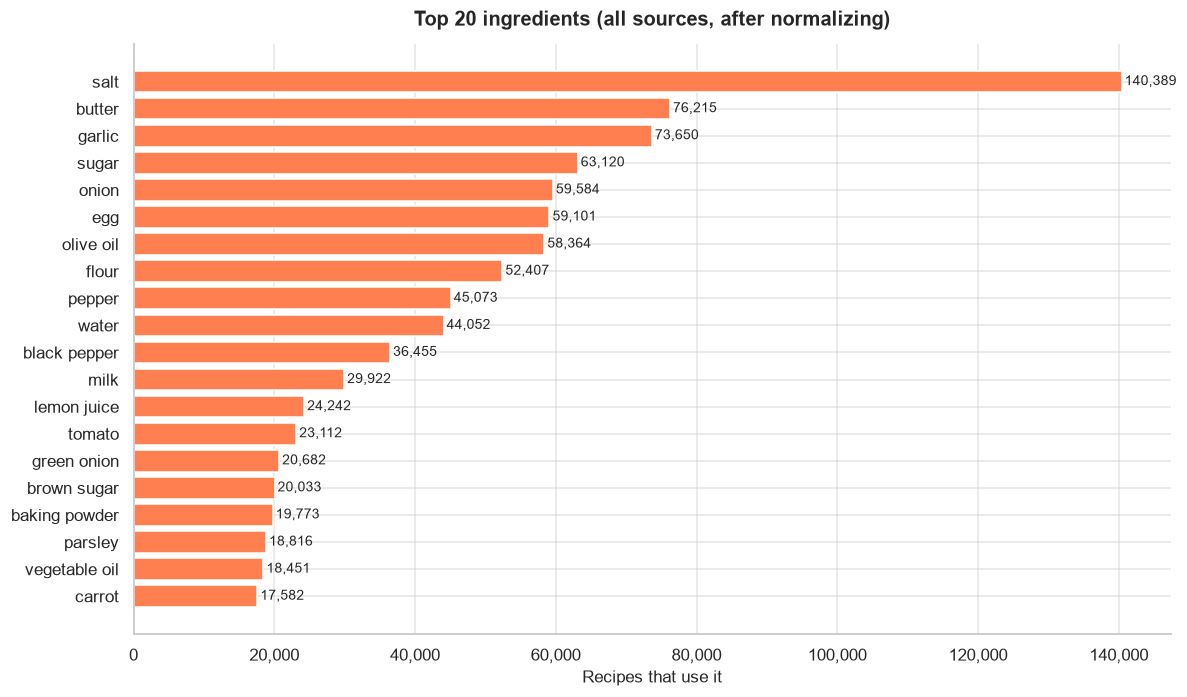


Top 20 ingredients:
  salt                           140,389
  butter                         76,215
  garlic                         73,650
  sugar                          63,120
  onion                          59,584
  egg                            59,101
  olive oil                      58,364
  flour                          52,407
  pepper                         45,073
  water                          44,052
  black pepper                   36,455
  milk                           29,922
  lemon juice                    24,242
  tomato                         23,112
  green onion                    20,682
  brown sugar                    20,033
  baking powder                  19,773
  parsley                        18,816
  vegetable oil                  18,451
  carrot                         17,582


In [74]:
# Use the combined table from 5.6 (or reload it after a restart)
try:
    _ = df_all
except NameError:
    df_all = pd.read_parquet("data/interim/recipes_all.parquet")

# Flatten all ingredient lists into a single list of names
# (Parquet returns lists as arrays, so convert each one)
all_ingredients = []
for lst in df_all["ingredient_list"]:
    if lst is not None:
        all_ingredients.extend(list(lst))

top_ingredients = Counter(all_ingredients).most_common(20)
names, counts = zip(*top_ingredients)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.barh(names[::-1], counts[::-1], color="coral")
label_bars(ax)
ax.set_xlabel("Recipes that use it")
thousands(ax, "x")
ax.set_title("Top 20 ingredients (all sources, after normalizing)")
show_figure(fig, "13_top_ingredients")

print("\nTop 20 ingredients:")
for name, count in top_ingredients:
    print(f"  {name:30s} {count:,}")

---

### 6.1.4 Recipe Complexity Distribution (All Sources)

> **What it shows:** How many different ingredients a recipe uses.

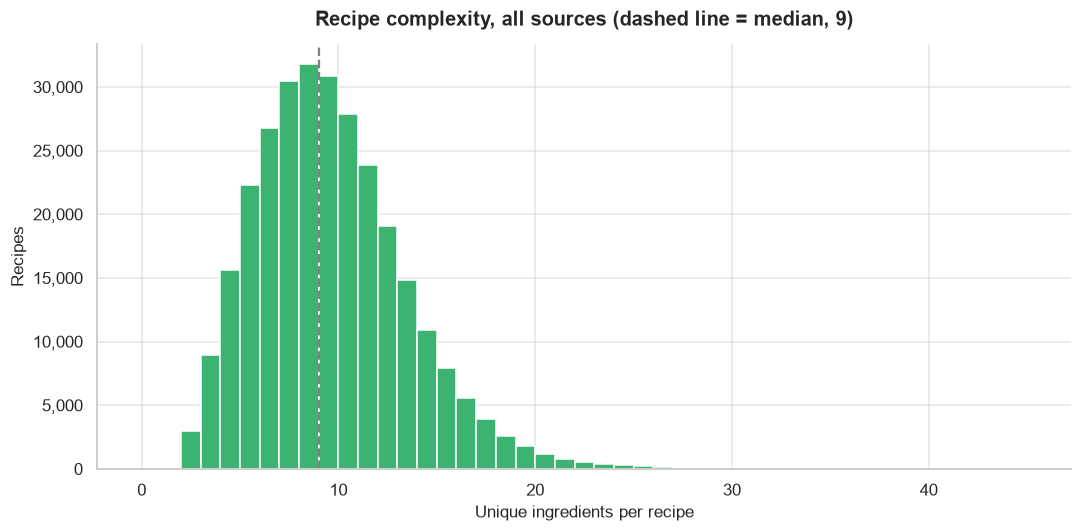

Complexity statistics:
count    291755.000000
mean          9.138753
std           3.841385
min           2.000000
25%           6.000000
50%           9.000000
75%          11.000000
max          44.000000
Name: complexity, dtype: float64


In [75]:
fig, ax = plt.subplots(figsize=(10, 5))
complexity = df_all["complexity"].dropna()
ax.hist(complexity, bins=range(int(complexity.max()) + 2), color="mediumseagreen", edgecolor="white")
ax.axvline(complexity.median(), ls="--", color="gray")
ax.set_xlabel("Unique ingredients per recipe")
ax.set_ylabel("Recipes")
thousands(ax)
ax.set_title(f"Recipe complexity, all sources (dashed line = median, {complexity.median():.0f})")
show_figure(fig, "14_recipe_complexity")

print("Complexity statistics:")
print(df_all["complexity"].describe())

### 6.1.5 Recipe Complexity vs Calories

Do recipes with more ingredients have more calories? We compare the number of ingredients with two measures, using recipes with **listed** calories only:

- **calories per serving**, as listed by the source;
- **calorie density of the ingredients**: the average USDA energy per 100 g of the recipe's ingredients (from the USDA ingredient table in 5.8.2). It shows whether a recipe is built from energy-dense ingredients (oil, butter, sugar, nuts) or light ones (vegetables, broth), independent of portion size.

> **What it shows:** Left: the typical calories per serving for each number of ingredients (line = median, band = middle 50% of recipes). Right: the typical calorie density of the ingredients. A flat line means the number of ingredients says little about calories.

**What we found:** recipes with more ingredients have more calories per serving, but their ingredients are, on average, slightly *less* energy-dense. Longer recipes are bigger, fuller dishes (mains with several components), not richer ones. For the Chef Agent, the number of ingredients is a useful hint for both effort and portion size.

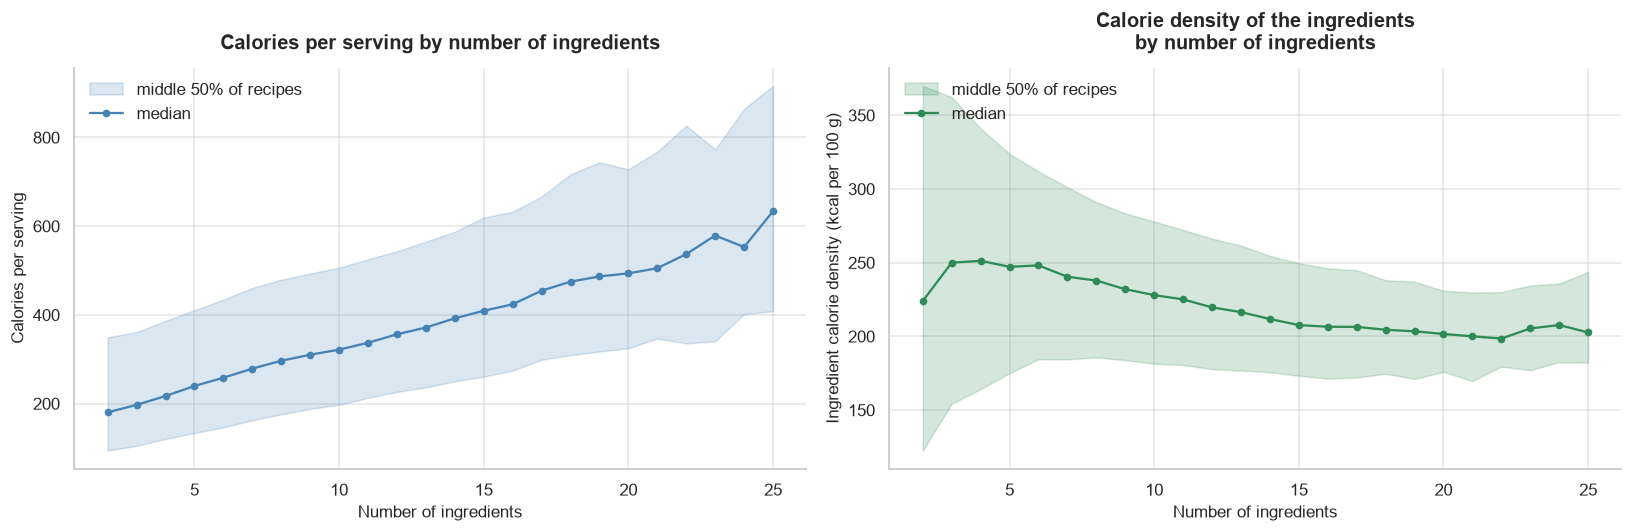

Recipes with listed calories (training split): 171,704
Rank correlation, ingredients vs calories per serving : +0.24
Rank correlation, ingredients vs ingredient density   : -0.14
Rank correlation, ingredient density vs calories      : +0.08

Median calories per serving by number of ingredients:
            recipes  kcal_median  density_median
complexity                                      
3              4657        197.0           250.0
5             12795        240.0           247.0
8             19213        297.0           238.0
10            16974        322.0           228.0
15             4606        409.0           208.0
20              625        494.0           202.0
25               72        634.0           203.0


In [76]:
# The USDA ingredient table is read from its file (5.8.2), so this works after a restart
ingredient_kcal_100g = (pd.read_csv("data/processed/usda_ingredient_nutrition.csv")
                        .set_index("ingredient")["kcal_100g"])

listed = train_df[train_df["nutrition_plausible"]].copy()
# One row per (recipe, ingredient), then the average energy per 100 g for each recipe
per_ingredient = pd.to_numeric(listed["ingredient_list"].explode().map(ingredient_kcal_100g), errors="coerce")
listed["ingredient_kcal_100g"] = per_ingredient.groupby(level=0).mean()

MAX_SHOWN = 25   # few recipes have more ingredients than this
by_count = (listed[listed["complexity"] <= MAX_SHOWN].groupby("complexity")
            .agg(recipes=("recipe_id", "size"),
                 kcal_median=("calories_per_serving", "median"),
                 kcal_q25=("calories_per_serving", lambda s: s.quantile(0.25)),
                 kcal_q75=("calories_per_serving", lambda s: s.quantile(0.75)),
                 density_median=("ingredient_kcal_100g", "median"),
                 density_q25=("ingredient_kcal_100g", lambda s: s.quantile(0.25)),
                 density_q75=("ingredient_kcal_100g", lambda s: s.quantile(0.75))))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, column, color, label in [
    (axes[0], "kcal", "steelblue", "Calories per serving"),
    (axes[1], "density", "seagreen", "Ingredient calorie density (kcal per 100 g)"),
]:
    ax.fill_between(by_count.index, by_count[f"{column}_q25"], by_count[f"{column}_q75"], color=color, alpha=0.2,
                    label="middle 50% of recipes")
    ax.plot(by_count.index, by_count[f"{column}_median"], color=color, marker="o", markersize=4, label="median")
    ax.set_xlabel("Number of ingredients")
    ax.set_ylabel(label)
    ax.legend(loc="upper left")
axes[0].set_title("Calories per serving by number of ingredients")
axes[1].set_title("Calorie density of the ingredients\nby number of ingredients")
show_figure(fig, "17_complexity_vs_calories")

# Rank correlation (Spearman): -1 to 1, where 0 means no relationship
correlation = listed[["complexity", "calories_per_serving", "ingredient_kcal_100g"]].corr(method="spearman")
print(f"Recipes with listed calories (training split): {len(listed):,}")
print(f"Rank correlation, ingredients vs calories per serving : {correlation.loc['complexity', 'calories_per_serving']:+.2f}")
print(f"Rank correlation, ingredients vs ingredient density   : {correlation.loc['complexity', 'ingredient_kcal_100g']:+.2f}")
print(f"Rank correlation, ingredient density vs calories      : {correlation.loc['ingredient_kcal_100g', 'calories_per_serving']:+.2f}")
print("\nMedian calories per serving by number of ingredients:")
print(by_count.loc[[n for n in (3, 5, 8, 10, 15, 20, 25) if n in by_count.index],
                   ["recipes", "kcal_median", "density_median"]].round(0).to_string())

---

## 6.2 Pattern Identification

Based on the analysis above, we identify the following key patterns and data challenges.

In [77]:
print("=" * 60)
print("KEY PATTERNS AND DATA CHALLENGES")
print("=" * 60)

FAMILIES = ["Asian", "European", "Latin American", "African", "Middle Eastern"]
total = cuisine_counts.sum()

# Pattern 1: Uneven cuisine coverage
dominant = cuisine_counts.idxmax()
print("\n1. UNEVEN CUISINE COVERAGE")
print(f"   '{dominant}' is the largest group at {cuisine_counts.max() / total * 100:.1f}% of training recipes.")
for family in FAMILIES:
    n = cuisine_counts.get(family, 0)
    print(f"   {family:15s}: {n:>7,} ({n / total * 100:.1f}%)")
print("   Action: Weight or oversample the smaller families when training models.")

# Pattern 2: Many recipes have no cuisine label
other_by_source = train_df.groupby("source")["cuisine_family"].apply(lambda s: (s == "Other").mean() * 100)
print("\n2. MANY RECIPES HAVE NO CUISINE FAMILY ('Other')")
for src, pct in other_by_source.items():
    print(f"   {src:12s}: {pct:.1f}% 'Other'")
print("   Food.com cuisine comes from tags, and many recipes have no cuisine tag.")
print("   Action: Predict cuisine for unlabeled recipes from their ingredients (Week 7).")

# Pattern 3: Calorie outliers
q99 = train_df.loc[train_df["nutrition_plausible"], "calories_per_serving"].quantile(0.99)
print("\n3. CALORIE OUTLIERS")
print("   Hugging Face calories were whole-recipe totals; they are now divided by servings.")
print(f"   Recipes above {MAX_KCAL_PER_SERVING:,} kcal per serving or {MAX_SERVINGS} servings were removed.")
print(f"   99th percentile is now {q99:,.0f} kcal per serving.")
print("   Action: Review the remaining high values; some 'servings' fields may be wrong.")

# Pattern 4: Ingredient name variation
n_unique = len(set(all_ingredients))
print("\n4. INGREDIENT NAME VARIATION")
print(f"   After normalization there are still {n_unique:,} unique ingredient names.")
print("   Brand names, descriptions ('low-fat', 'boneless') and synonyms remain.")
print("   Action: Extend the synonym dictionary in 5.4.4, or map names to USDA foods.")

# Pattern 5: Nutrition data completeness
has_kcal = train_df.groupby("source")["nutrition_plausible"].mean() * 100
print("\n5. NUTRITION DATA COMPLETENESS")
for src, pct in has_kcal.items():
    print(f"   {src:12s}: {pct:.0f}% of recipes have listed calories; the rest are estimated (5.8)")
print("   Food.com macros are converted from percent daily values (approximate).")
print("   Action: Estimates (with a likely range) fill the gap; prefer listed values when ranking.")

print("\n" + "=" * 60)

KEY PATTERNS AND DATA CHALLENGES

1. UNEVEN CUISINE COVERAGE
   'Other' is the largest group at 68.7% of training recipes.
   Asian          :  14,541 (7.1%)
   European       :  33,690 (16.5%)
   Latin American :  11,003 (5.4%)
   African        :   2,222 (1.1%)
   Middle Eastern :   2,381 (1.2%)
   Action: Weight or oversample the smaller families when training models.

2. MANY RECIPES HAVE NO CUISINE FAMILY ('Other')
   culinarydb  : 38.0% 'Other'
   foodcom     : 77.9% 'Other'
   huggingface : 45.4% 'Other'
   themealdb   : 7.0% 'Other'
   Food.com cuisine comes from tags, and many recipes have no cuisine tag.
   Action: Predict cuisine for unlabeled recipes from their ingredients (Week 7).

3. CALORIE OUTLIERS
   Hugging Face calories were whole-recipe totals; they are now divided by servings.
   Recipes above 3,000 kcal per serving or 50 servings were removed.
   99th percentile is now 2,006 kcal per serving.
   Action: Review the remaining high values; some 'servings' fields may

---

## 6.3 Simple Baseline Model

Before building a sophisticated recommendation engine, we establish a rule-based baseline. The baseline logic is:

1. Filter recipes by cuisine family.
2. Apply dietary restriction filters (e.g., vegetarian only, a list of flags to avoid such as pork and alcohol, or a diet profile from 5.4.7 such as halal-friendly).
3. Keep only recipes with plausible nutrition data (5.6).
4. Rank the remaining recipes by how close their calorie count is to the user's target.
5. **Safety filter:** re-check each candidate's ingredients and name with the keyword rules from 5.4.2, independently of the stored flags, and drop any that fail. This mirrors the hard-coded filter the final system runs after the agents generate a recipe.
6. Return the top N results.

This baseline directly mirrors the core task of the Nutritionist Agent and gives us a measurable starting point to improve on.

In [78]:
# The recommender and its safety filter are in src/everflavor/recommend.py. The
# safety filter re-checks ingredients and names with the same keyword and diet
# rules that built the data (flags.py, diets.py), so this cell also works after
# a kernel restart without re-running Week 5.
from everflavor.recommend import baseline_recommend, passes_safety_filter  # noqa: F401

# Columns shown for every test below
display_cols = ["recipe_name", "source", "cuisine_family", "calories_per_serving",
                "vegetarian", "calorie_distance"]

BASELINE_TESTS = [
    ("Test 1: Asian vegetarian recipes near 400 kcal per serving",
     {"cuisine_family": "Asian", "calorie_target": 400, "vegetarian_only": True}),
    ("Test 2: Middle Eastern gluten-free recipes near 600 kcal per serving",
     {"cuisine_family": "Middle Eastern", "calorie_target": 600, "gluten_free": True}),
    ("Test 3: Middle Eastern, no pork or alcohol, near 550 kcal (the README example)",
     {"cuisine_family": "Middle Eastern", "calorie_target": 550,
          "avoid": ("contains_pork", "contains_alcohol")}),
    ("Test 4: African vegetarian recipes near 500 kcal per serving",
     {"cuisine_family": "African", "calorie_target": 500, "vegetarian_only": True}),
    ("Test 5: Middle Eastern halal-friendly recipes near 550 kcal per serving (diet profile)",
     {"cuisine_family": "Middle Eastern", "calorie_target": 550, "diets": ("halal_friendly",)}),
]

# -------------------------------------------------------
# Test the baseline on the training split
# -------------------------------------------------------
for title, kwargs in BASELINE_TESTS:
    print(f"Baseline {title}")
    print("-" * 60)
    recs = baseline_recommend(train_df, top_n=5, **kwargs)
    if not recs.empty:
        print(recs[display_cols].to_string(index=False))
    print()

Baseline Test 1: Asian vegetarian recipes near 400 kcal per serving
------------------------------------------------------------


                    recipe_name      source cuisine_family  calories_per_serving  vegetarian  calorie_distance
               Besanwali Bhindi huggingface          Asian            399.812699        True          0.187301
                    muslim naan     foodcom          Asian            399.600000        True          0.400000
tamarind rice with sesame seeds     foodcom          Asian            399.400000        True          0.600000
       lip smackin almond halwa     foodcom          Asian            400.600000        True          0.600000
   Indian Spinach and Chickpeas huggingface          Asian            399.308023        True          0.691977

Baseline Test 2: Middle Eastern gluten-free recipes near 600 kcal per serving
------------------------------------------------------------
                                            recipe_name      source cuisine_family  calories_per_serving  vegetarian  calorie_distance
                                  Smoky Fried Chickpeas hug

                                  recipe_name  source cuisine_family  calories_per_serving  vegetarian  calorie_distance
                                 kubbeh bamya foodcom Middle Eastern                 548.7       False               1.3
israeli couscous with pistachios and apricots foodcom Middle Eastern                 548.5       False               1.5
 twisted beef koftas middle eastern meatballs foodcom Middle Eastern                 551.6       False               1.6
   saffron steamed basmati rice persian polow foodcom Middle Eastern                 548.3        True               1.7
           khoresht e hulu persian peach stew foodcom Middle Eastern                 551.7       False               1.7

Baseline Test 4: African vegetarian recipes near 500 kcal per serving
------------------------------------------------------------


                                                recipe_name  source cuisine_family  calories_per_serving  vegetarian  calorie_distance
                                             impossible pie foodcom        African                 499.2        True               0.8
                  sweetened condensed milk biscuits cookies foodcom        African                 502.3        True               2.3
cumin spiced honey carrots with lemon coriander vinaigrette foodcom        African                 497.1        True               2.9
                vegetables couscous with caramelised onions foodcom        African                 496.4        True               3.6
                               diphaphata stove top muffins foodcom        African                 504.5        True               4.5

Baseline Test 5: Middle Eastern halal-friendly recipes near 550 kcal per serving (diet profile)
------------------------------------------------------------


                                  recipe_name  source cuisine_family  calories_per_serving  vegetarian  calorie_distance
                                 kubbeh bamya foodcom Middle Eastern                 548.7       False               1.3
israeli couscous with pistachios and apricots foodcom Middle Eastern                 548.5       False               1.5
 twisted beef koftas middle eastern meatballs foodcom Middle Eastern                 551.6       False               1.6
           khoresht e hulu persian peach stew foodcom Middle Eastern                 551.7       False               1.7
   saffron steamed basmati rice persian polow foodcom Middle Eastern                 548.3        True               1.7



---

## 6.4 Key Insights for the Three EverFlavor Agents

Based on the Week 6 analysis, we draw actionable conclusions for each agent.

In [79]:
# Numbers quoted below are computed from the data, not typed in
kcal = train_df.loc[train_df["nutrition_plausible"], "calories_per_serving"]
kcal_q25, kcal_median, kcal_q75 = kcal.quantile([0.25, 0.5, 0.75])
cx = df_all["complexity"]
top_4 = ", ".join(name for name, _ in top_ingredients[:4])
african_n = (train_df["cuisine_family"] == "African").sum()
mideast_n = (train_df["cuisine_family"] == "Middle Eastern").sum()
with_steps = df_all["instructions"].notna().mean() * 100

print("=" * 65)
print("INSIGHTS FOR THE THREE EVERFLAVOR AGENTS")
print("=" * 65)

print(f"""
NUTRITIONIST AGENT
------------------
- Calories per serving are right-skewed. Half of the training recipes
  with calorie data fall between {kcal_q25:,.0f} and {kcal_q75:,.0f} kcal (median {kcal_median:,.0f} kcal).
- Protein, fat, carbs and sodium are now in grams per serving: exact
  for Hugging Face, converted from percent daily values for Food.com,
  and estimated in 5.8 for CulinaryDB, TheMealDB and recipes with
  unbelievable values (labeled 'estimated', with a likely range).
- Restriction flags cover pork, alcohol, gluten, dairy, egg, peanut,
  tree nut, fish, shellfish, soy and sesame, plus vegetarian and vegan.
  Diet profiles (5.4.7) combine them: halal-, kosher- and Jain-friendly,
  pescatarian, no beef, lower sodium and low carb.
  They are keyword-based (with Hugging Face labels where they exist),
  so they are a first filter, not a guarantee.
- USDA data is the ground truth for ingredient-level nutrition:
  data/processed/usda_ingredient_nutrition.csv has per-100 g values
  for the matched ingredients, and each recipe names its closest USDA dish.

CHEF AGENT
----------
- The most common ingredients ({top_4}) are generic
  staples. Culturally specific ingredients appear less often,
  which will require extra attention when generating authentic recipes.
- Recipe complexity ranges from {cx.min():.0f} to {cx.max():.0f} unique ingredients
  (median {cx.median():.0f}). The Chef Agent should present simpler recipes
  (fewer than 10 ingredients) to beginner users and more complex ones
  to experienced cooks.
- The training set has {african_n:,} African and {mideast_n:,} Middle Eastern recipes,
  mostly from Food.com cuisine tags, CulinaryDB and TheMealDB.
- {with_steps:.0f}% of recipes include cooking instructions (Food.com and TheMealDB).

SOURCING AGENT
--------------
- Specialty ingredients (miso paste, tahini, plantain, harissa, etc.)
  are not commonly stocked at general supermarkets.
- The Google Places API integration should use cuisine family as the
  primary search tag (e.g., 'Asian grocery store near me').
- A fallback should suggest online retailers for ingredients that
  are not available locally.
- origin_country (labeled or predicted, 5.9) lets the agent look for
  stores that sell a specific country's ingredients, for example for
  a user who wants dishes from home.
""")
print("=" * 65)

INSIGHTS FOR THE THREE EVERFLAVOR AGENTS

NUTRITIONIST AGENT
------------------
- Calories per serving are right-skewed. Half of the training recipes
  with calorie data fall between 181 and 504 kcal (median 309 kcal).
- Protein, fat, carbs and sodium are now in grams per serving: exact
  for Hugging Face, converted from percent daily values for Food.com,
  and estimated in 5.8 for CulinaryDB, TheMealDB and recipes with
  unbelievable values (labeled 'estimated', with a likely range).
- Restriction flags cover pork, alcohol, gluten, dairy, egg, peanut,
  tree nut, fish, shellfish, soy and sesame, plus vegetarian and vegan.
  Diet profiles (5.4.7) combine them: halal-, kosher- and Jain-friendly,
  pescatarian, no beef, lower sodium and low carb.
  They are keyword-based (with Hugging Face labels where they exist),
  so they are a first filter, not a guarantee.
- USDA data is the ground truth for ingredient-level nutrition:
  data/processed/usda_ingredient_nutrition.csv has per-100 g val

---

## 6.5 Final Dataset Summary

In [80]:
# Counts are read from memory, or from the saved files after a restart
from everflavor.reporting import saved_rows


def split_rows(var_name, parquet_path):
    """Number of rows in a split, from memory if loaded, else from its file."""
    if var_name in globals():
        return len(globals()[var_name])
    if os.path.exists(parquet_path):
        return len(pd.read_parquet(parquet_path, columns=["recipe_id"]))
    return 0

usda_saved = saved_rows("data/raw/usda_sample.csv")
off_saved  = saved_rows("data/raw/open_food_facts_sample.csv")
off_queries_with_results = off_saved["search_query"].nunique() if not off_saved.empty else 0

print("=" * 65)
print("FINAL PREPROCESSED DATASET SUMMARY")
print("=" * 65)

print("\nCOMBINED RECIPE TABLE")
print(f"  Total recipes (cleaned, duplicates removed): {len(df_all):,}")
print(f"  Columns                                    : {df_all.shape[1]}")
print("  Saved to                                   : data/interim/recipes_all.parquet")
print("\n  Recipes by source:")
for src, n in df_all["source"].value_counts().items():
    print(f"    {src:14s} {n:>8,}")
print("\n  Recipes by cuisine family:")
for family, n in df_all["cuisine_family"].value_counts().items():
    print(f"    {family:14s} {n:>8,}")

print("\n  Nutrition (calories per serving):")
for source, n in df_all["nutrition_source"].value_counts().items():
    print(f"    {source:14s} {n:>8,}")

print(f"""
SPLITS (stratified by cuisine family, near-duplicates kept together)
  Train set                     : {split_rows('train_df', 'data/processed/recipes_train.parquet'):,} rows
  Validation set                : {split_rows('val_df', 'data/processed/recipes_val.parquet'):,} rows
  Test set                      : {split_rows('test_df', 'data/processed/recipes_test.parquet'):,} rows
  Saved to                      : data/processed/recipes_train/val/test.parquet

USDA SAMPLE
  Ingredients saved             : {len(usda_saved)}
  Saved to                      : data/raw/usda_sample.csv

OPEN FOOD FACTS SAMPLE
  Queries with results          : {off_queries_with_results}
  Product records saved         : {len(off_saved)}
  Saved to                      : data/raw/open_food_facts_sample.csv
""")
print("=" * 65)

FINAL PREPROCESSED DATASET SUMMARY

COMBINED RECIPE TABLE
  Total recipes (cleaned, duplicates removed): 291,755
  Columns                                    : 95
  Saved to                                   : data/interim/recipes_all.parquet

  Recipes by source:
    foodcom         218,024
    huggingface      37,823
    culinarydb       35,325
    themealdb           583

  Recipes by cuisine family:
    Other           200,526
    European         48,150
    Asian            20,788
    Latin American   15,706
    Middle Eastern    3,406
    African           3,179

  Nutrition (calories per serving):
    listed          245,452
    estimated        46,303

SPLITS (stratified by cuisine family, near-duplicates kept together)
  Train set                     : 204,114 rows
  Validation set                : 43,816 rows
  Test set                      : 43,825 rows
  Saved to                      : data/processed/recipes_train/val/test.parquet

USDA SAMPLE
  Ingredients saved           

---

## 6.6 Preparing for Week 7: Leak-Free Features and Evaluation

Week 7 trains real models. This section sets up the parts every model needs and tests them with a simple **baseline cuisine classifier** (predict the cuisine family from the ingredients):

1. **Features learned from training data only.** The ingredient vocabulary is built inside a scikit-learn `Pipeline` that is fitted on the training split only. Validation and test recipes are only transformed, never used for fitting.
2. **Rare ingredients dropped.** Ingredients that appear in fewer than 5 training recipes are left out of the vocabulary.
3. **Labeled recipes only, with class weights.** The classifier learns from recipes with a real cuisine label. Class weights make the small African and Middle Eastern families count as much as the large ones.
4. **Evaluation on the validation split.** We report macro-F1, which gives each cuisine equal weight, plus per-cuisine scores and per-source results. The test split stays untouched for the final Week 7 evaluation.
5. **Saving and reuse.** The fitted pipeline is saved, so user input at prediction time gets exactly the same processing. We also check which of a user's ingredients the model has never seen.

#### 6.6.1 Feature pipeline and class weights

In [81]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

MIN_INGREDIENT_COUNT = 5   # ingredients in fewer training recipes are dropped


# ingredient_tokens() (each normalized ingredient is one token) is in
# src/everflavor/ingredients.py, so the saved model can be loaded anywhere
# the everflavor package can be imported.
from everflavor.ingredients import ingredient_tokens

# Cuisine models learn only from recipes with a real cuisine label
train_labeled = train_df[train_df["cuisine_labeled"]]
val_labeled   = val_df[val_df["cuisine_labeled"]]

cuisine_model = Pipeline([
    ("ingredients", CountVectorizer(analyzer=ingredient_tokens, min_df=MIN_INGREDIENT_COUNT, binary=True)),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000)),
])
# Fitted on TRAIN only: the vocabulary and weights never see val/test data
cuisine_model.fit(train_labeled["ingredient_list"], train_labeled["cuisine_family"])

vocab = cuisine_model.named_steps["ingredients"].vocabulary_
n_train_ingredients = len({i for l in train_labeled["ingredient_list"] for i in l})
print(f"Training recipes with a cuisine label: {len(train_labeled):,}")
print(f"Ingredient vocabulary: {len(vocab):,} kept of {n_train_ingredients:,} "
      f"(those in fewer than {MIN_INGREDIENT_COUNT} recipes were dropped)")

classes = np.array(sorted(train_labeled["cuisine_family"].unique()))
weights = compute_class_weight("balanced", classes=classes, y=train_labeled["cuisine_family"])
print("\nClass weights (higher = smaller family, counted more):")
for family, w in zip(classes, weights):
    print(f"  {family:15s} {w:5.2f}")

Training recipes with a cuisine label: 63,837
Ingredient vocabulary: 4,623 kept of 24,112 (those in fewer than 5 recipes were dropped)

Class weights (higher = smaller family, counted more):
  African          5.75
  Asian            0.88
  European         0.38
  Latin American   1.16
  Middle Eastern   5.36


#### 6.6.2 Evaluate on the validation split

In [82]:
from sklearn.metrics import accuracy_score, classification_report, f1_score


def evaluate_cuisine_model(model, df):
    """Print overall, per-cuisine and per-source results; return predictions."""
    pred = pd.Series(model.predict(df["ingredient_list"]), index=df.index)
    true = df["cuisine_family"]
    print(f"Macro-F1 : {f1_score(true, pred, average='macro'):.3f}  (each cuisine counts equally)")
    print(f"Accuracy : {accuracy_score(true, pred):.3f}")
    print("\nPer cuisine:")
    print(classification_report(true, pred, digits=3))
    print("Per source (error analysis by slice):")
    for src_name, g in df.groupby("source"):
        print(f"  {src_name:12s} n={len(g):>6,}  macro-F1={f1_score(g['cuisine_family'], pred[g.index], average='macro'):.3f}"
              f"  accuracy={accuracy_score(g['cuisine_family'], pred[g.index]):.3f}")
    return pred

print("VALIDATION RESULTS (the test split stays untouched until Week 7)")
print("=" * 60)
val_pred = evaluate_cuisine_model(cuisine_model, val_labeled)

print("\nMost common confusions (true -> predicted):")
pairs = pd.DataFrame({"true": val_labeled["cuisine_family"], "predicted": val_pred})
confusions = pairs[pairs["true"] != pairs["predicted"]].value_counts().head(5)
print(confusions.to_string())

print("\nExamples of African recipes predicted as something else:")
wrong = val_labeled[(val_labeled["cuisine_family"] == "African") & (val_pred != "African")]
for _, r in wrong.head(5).iterrows():
    print(f"  - {r['recipe_name']}  -> {val_pred[r.name]}")

VALIDATION RESULTS (the test split stays untouched until Week 7)
Macro-F1 : 0.622  (each cuisine counts equally)


Accuracy : 0.769

Per cuisine:


                precision    recall  f1-score   support

       African      0.255     0.526     0.343       475
         Asian      0.869     0.800     0.833      3122
      European      0.905     0.791     0.844      7227
Latin American      0.733     0.758     0.745      2351
Middle Eastern      0.253     0.535     0.343       512

      accuracy                          0.769     13687
     macro avg      0.603     0.682     0.622     13687
  weighted avg      0.820     0.769     0.788     13687

Per source (error analysis by slice):


  culinarydb   n= 3,321  macro-F1=0.648  accuracy=0.812
  foodcom      n= 7,196  macro-F1=0.650  accuracy=0.779
  huggingface  n= 3,087  macro-F1=0.460  accuracy=0.699
  themealdb    n=    83  macro-F1=0.614  accuracy=0.723

Most common confusions (true -> predicted):
true            predicted     
European        Middle Eastern    501
                Latin American    446
                African           355
Latin American  European          274
European        Asian             209

Examples of African recipes predicted as something else:
  - 24k carrots  -> Asian
  - african chopped salad with yogurt and brown butter  -> Middle Eastern
  - african fruit salad  -> Latin American
  - african vegetable stew  -> Middle Eastern
  - algerian chicken stew  -> Middle Eastern


#### 6.6.3 Chart: where the baseline cuisine classifier gets it right and wrong

> **What it shows:** Left: which cuisines the baseline confuses (the diagonal is correct). Right: the F1 score for each cuisine; higher is better.

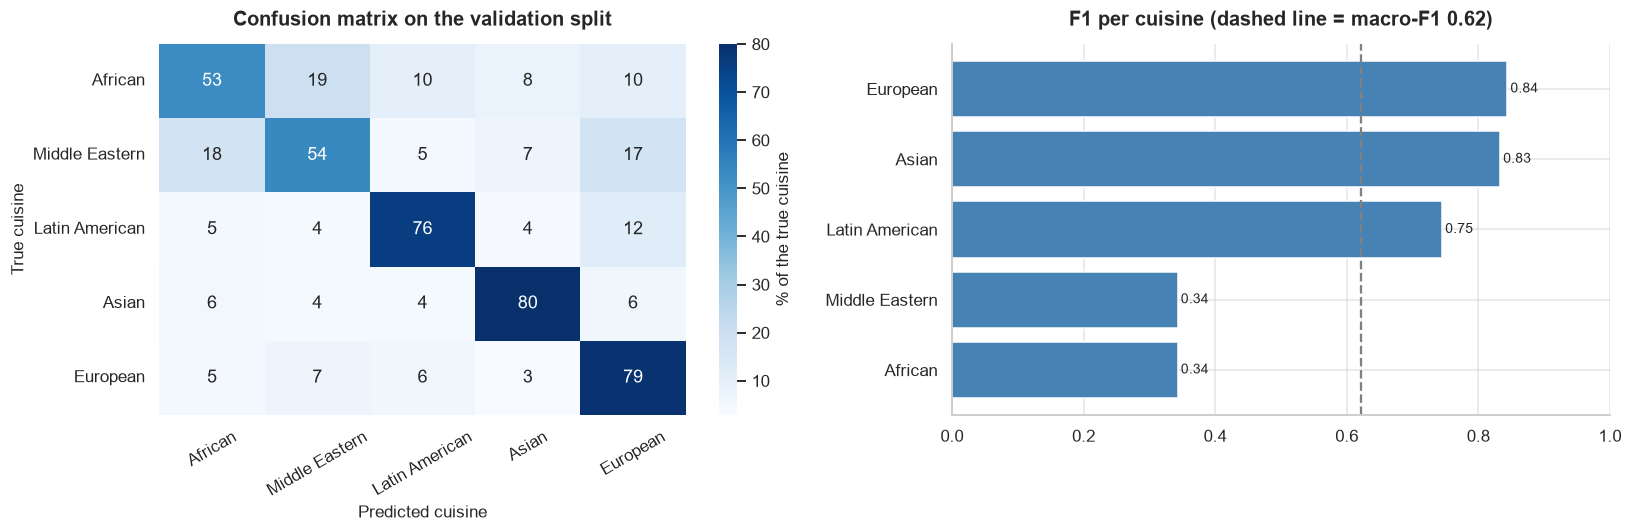

In [83]:
from sklearn.metrics import confusion_matrix

families = [f for f in FAMILY_ORDER if f != "Other"]
matrix = confusion_matrix(val_labeled["cuisine_family"], val_pred, labels=families, normalize="true") * 100
per_family_f1 = pd.Series(f1_score(val_labeled["cuisine_family"], val_pred, labels=families, average=None),
                          index=families)
macro = f1_score(val_labeled["cuisine_family"], val_pred, average="macro")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues", xticklabels=families, yticklabels=families,
            cbar_kws={"label": "% of the true cuisine"}, ax=axes[0])
axes[0].set_xlabel("Predicted cuisine")
axes[0].set_ylabel("True cuisine")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_title("Confusion matrix on the validation split")
axes[1].barh(per_family_f1.index, per_family_f1.values, color="steelblue")
axes[1].axvline(macro, ls="--", color="gray")
axes[1].set_xlim(0, 1)
label_bars(axes[1], fmt="{:.2f}")
axes[1].set_title(f"F1 per cuisine (dashed line = macro-F1 {macro:.2f})")
show_figure(fig, "10_cuisine_baseline_results")

#### 6.6.4 Save the pipeline and check new ingredients

In [84]:
import joblib

from everflavor.ingredients import normalize_ingredient_list

# Save the fitted pipeline (models/ is git-ignored; it is recreated by this cell)
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
MODEL_FILE = MODEL_DIR / "cuisine_baseline.joblib"
joblib.dump(cuisine_model, MODEL_FILE)
print(f"Saved fitted pipeline to {MODEL_FILE} ({MODEL_FILE.stat().st_size / 1e6:.1f} MB)")


def check_user_ingredients(user_ingredients, model=cuisine_model):
    """Normalize a user's ingredients the same way as the training data and
    report which ones the model has never seen (useful for monitoring)."""
    normalized = normalize_ingredient_list(user_ingredients)
    vocab = model.named_steps["ingredients"].vocabulary_
    unseen = [i for i in normalized if i not in vocab]
    return normalized, unseen

example = ["2 cups basmati rice", "1 lb lamb shoulder, cubed", "berbere spice", "injera", "Chopped Onions"]
normalized, unseen = check_user_ingredients(example)
print("\nExample user input :", example)
print("Normalized         :", normalized)
print("Unseen by the model:", unseen or "none")
print("Predicted cuisine  :", cuisine_model.predict([normalized])[0])

Saved fitted pipeline to models\cuisine_baseline.joblib (0.3 MB)

Example user input : ['2 cups basmati rice', '1 lb lamb shoulder, cubed', 'berbere spice', 'injera', 'Chopped Onions']
Normalized         : ['basmati rice', 'lamb shoulder', 'berbere spice', 'injera', 'onion']
Unseen by the model: ['berbere spice', 'injera']
Predicted cuisine  : Middle Eastern


---

## Weeks 4-6 Completion Checklist

In [85]:
# Each item can name a file or folder that proves it was done.
# Items with a path are only ticked if that path exists;
# items without one (documentation steps) are ticked by hand.
# The two human-decision items read their files here, so this cell also works after a restart.
_policies = pd.read_csv("docs/flag_review/flag_policies.csv")
_open_policies = _policies.loc[_policies["status"] != "approved", "policy_id"].tolist()
_labeled_rounds = [int(p.stem.rsplit("round", 1)[1]) for p in Path("docs/flag_review").glob("flag_review_labeled_round*.csv")]
_signed_off = bool(_labeled_rounds) and (pd.read_csv("docs/flag_review/human_signoff.csv")["round"] == max(_labeled_rounds)).any()

checklist = [
    # Week 4
    ("WEEK 4", "Identified and documented all data sources", None),
    ("WEEK 4", "Created data/raw, data/interim, data/processed folders", "data/processed"),
    ("WEEK 4", "USDA FoodData Central API connected (key from Colab Secrets or .env)", "data/raw/usda_sample.csv"),
    ("WEEK 4", "USDA ingredient sample saved to data/raw/usda_sample.csv", "data/raw/usda_sample.csv"),
    ("WEEK 4", "Food.com dataset downloaded via kagglehub", None),
    ("WEEK 4", "Food.com 1,000-row sample saved to data/raw/food_com_sample.csv", "data/raw/food_com_sample.csv"),
    ("WEEK 4", "Hugging Face recipes-with-nutrition loaded via datasets library", None),
    ("WEEK 4", "Hugging Face 1,000-row sample saved to data/raw/hf_recipes_sample.csv", "data/raw/hf_recipes_sample.csv"),
    ("WEEK 4", "Open Food Facts fully integrated: search, barcode lookup, quality check, save", "data/raw/open_food_facts_sample.csv"),
    ("WEEK 4", "Open Food Facts sample saved to data/raw/open_food_facts_sample.csv", "data/raw/open_food_facts_sample.csv"),
    ("WEEK 4", "CulinaryDB recipes downloaded and saved", "data/raw/culinarydb_recipes.parquet"),
    ("WEEK 4", "TheMealDB recipes collected through its API and saved", "data/raw/themealdb_recipes.parquet"),
    ("WEEK 4", "Optional and later sources (RecipeDB, Google Places) documented", None),
    ("WEEK 4", "Privacy and ethics note written", None),
    # Week 5
    ("WEEK 5", "Missing value and duplicate analysis completed for both datasets", None),
    ("WEEK 5", "Outlier analysis completed (calories per serving, servings, cook time)", None),
    ("WEEK 5", "Data cleaning applied (drop missing, dedup, servings and calorie caps)", None),
    ("WEEK 5", "cuisine_family mapped for every source (labels, Food.com tags, regions)", None),
    ("WEEK 5", "Restriction flags engineered (pork, alcohol, gluten, dairy, 7 allergens, veg, vegan)", None),
    ("WEEK 5", "Meat type flags: red meat (mammals), poultry, processed meat (USDA, WHO / IARC)", None),
    ("WEEK 5", "Worldwide restriction flags: other countries' allergens, religious rules, medical screens", None),
    ("WEEK 5", "Flags checked against Food.com's own dietary tags", None),
    ("WEEK 5", "Macronutrients in grams per serving (Hugging Face exact, Food.com converted)", None),
    ("WEEK 5", "Ingredient lists cleaned, tokenized and normalized (quantities and units removed)", None),
    ("WEEK 5", "Nutrition plausibility checks (calories, sodium, protein, macros vs calories)", None),
    ("WEEK 5", "Recipe complexity feature created", None),
    ("WEEK 5", "Country and region of origin mapped from the sources' labels", None),
    ("WEEK 5", "Diet profiles (halal-, kosher-, Jain-friendly, pescatarian, no beef, lower sodium, low carb)", None),
    ("WEEK 5", "More diet profiles (Vaishnava, Buddhist, Orthodox fasting, Adventist, LDS, Ital, medical screens)", None),
    ("WEEK 5", "Allergen lists by country (US, EU / UK, Canada, Australia / NZ, Japan, South Korea)", None),
    ("WEEK 5", "Reusable run_pipeline() function built for every source", None),
    ("WEEK 5", "Shared code moved to src/everflavor (one copy for the notebook and the agents)", "src/everflavor/pipeline.py"),
    ("WEEK 5", "All sources combined into one table, duplicates removed", "data/interim/recipes_all.parquet"),
    ("WEEK 5", "Train/val/test split (70/15/15) stratified, near-duplicates kept together", "data/processed/recipes_test.parquet"),
    ("WEEK 5", "USDA FNDDS and SR Legacy reference data downloaded (official, no key)", "data/raw/usda_fdc"),
    ("WEEK 5", "Missing nutrition estimated (similar recipes + USDA), labeled, with a likely range", None),
    ("WEEK 5", "USDA ingredient nutrition table saved", "data/processed/usda_ingredient_nutrition.csv"),
    ("WEEK 5", "Missing countries predicted where confident (labeled / predicted / unknown)", "data/processed/figures/19_origin_countries.png"),
    ("WEEK 5", "Automatic data validation checks passed", None),
    ("WEEK 5", "Dataset record saved (versions, settings, counts)", "data/processed/dataset_info.json"),
    ("WEEK 5", "Blind hand-check samples exported for flag review", "docs/flag_review/flag_review_sample_round4.csv"),
    ("WEEK 5", "Flags scored against a fresh labeled sample", "docs/flag_review/flag_review_labeled_round3.csv"),
    ("WEEK 5", "Round 3 disagreements traced and fixed, with the evidence for each flag (5.13)",
     "docs/flag_review/flag_review_disagreements_round3.csv"),
    ("WEEK 5", "Hidden allergens in ready-made ingredients checked against Open Food Facts (5.13)",
     "docs/flag_review/compound_ingredients_review.csv"),
    # Human decisions (5.13): ticked only when a person has recorded them
    ("WEEK 5", "Every flag policy approved by a person (5.13)",
     "docs/flag_review/flag_policies.csv" if not _open_policies else "(policies waiting: " + ", ".join(_open_policies) + ")"),
    ("WEEK 5", "Latest flag review round signed off by a person (5.13)",
     "docs/flag_review/human_signoff.csv" if _signed_off else "(no human sign-off for the latest round yet)"),
    ("WEEK 5", "Processed files saved as Parquet", "data/processed/recipes_train.parquet"),
    # Week 6
    ("WEEK 6", "Calorie distribution visualized and analyzed", "data/processed/figures/11_calories_per_serving.png"),
    ("WEEK 6", "Cuisine coverage bar chart created", "data/processed/figures/12_cuisine_coverage.png"),
    ("WEEK 6", "Top 20 ingredient frequency chart created", "data/processed/figures/13_top_ingredients.png"),
    ("WEEK 6", "Recipe complexity distribution analyzed", "data/processed/figures/14_recipe_complexity.png"),
    ("WEEK 6", "Recipe complexity vs calories and calorie density analyzed", "data/processed/figures/17_complexity_vs_calories.png"),
    ("WEEK 6", "Five key data patterns identified", None),
    ("WEEK 6", "Baseline model (filters, avoid list, calorie ranking, safety filter) implemented", None),
    ("WEEK 6", "Key insights derived for Nutritionist, Chef, and Sourcing agents", None),
    ("WEEK 6", "Final dataset summary printed", None),
    ("WEEK 6", "Charts for raw data, cleaning, labels, flags, nutrition, normalization, combining, splits and results", "data/processed/figures/10_cuisine_baseline_results.png"),
    ("WEEK 6", "Charts for the nutrition estimates and calories by cuisine", "data/processed/figures/16_calories_by_cuisine.png"),
    ("WEEK 6", "Chart of diet profiles by cuisine family", "data/processed/figures/18_diet_profiles.png"),
    ("WEEK 6", "Leak-free feature pipeline fitted on training data only", None),
    ("WEEK 6", "Cuisine baseline evaluated (macro-F1, per cuisine, per source)", None),
    ("WEEK 6", "Fitted pipeline saved for reuse at prediction time", "models/cuisine_baseline.joblib"),
]

from everflavor.reporting import print_checklist

completed, total = print_checklist(checklist)
if completed == total:
    print("\nNotebook complete. Ready for Week 7 - Model Development.")
else:
    print("\nSome items are not done yet. Re-run the cells for the missing files above.")


  WEEK 4
  [x] Identified and documented all data sources
  [x] Created data/raw, data/interim, data/processed folders
  [x] USDA FoodData Central API connected (key from Colab Secrets or .env)
  [x] USDA ingredient sample saved to data/raw/usda_sample.csv
  [x] Food.com dataset downloaded via kagglehub
  [x] Food.com 1,000-row sample saved to data/raw/food_com_sample.csv
  [x] Hugging Face recipes-with-nutrition loaded via datasets library
  [x] Hugging Face 1,000-row sample saved to data/raw/hf_recipes_sample.csv
  [x] Open Food Facts fully integrated: search, barcode lookup, quality check, save
  [x] Open Food Facts sample saved to data/raw/open_food_facts_sample.csv
  [x] CulinaryDB recipes downloaded and saved
  [x] TheMealDB recipes collected through its API and saved
  [x] Optional and later sources (RecipeDB, Google Places) documented
  [x] Privacy and ethics note written

  WEEK 5
  [x] Missing value and duplicate analysis completed for both datasets
  [x] Outlier analysis co